# Predicting Stellar Class from Data

This notebook trains models to predict stellar class for the Predicting Stellar Class challenge, a kaggle competition using synthetic data based on observational data. The synthetic data are published on kaggle:

Yao Yan, Walter Reade, Elizabeth Park. Predicting Stellar Class. https://kaggle.com/competitions/playground-series-s6e6, 2026. Kaggle.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e6')

print("Path to competition files:", path)

Path to competition files: /Users/jaquesgillis/.cache/kagglehub/competitions/playground-series-s6e6


In [3]:
from setup import * 
import os

os.listdir(path)

['test.csv', 'train.csv', 'sample_submission.csv']

In [4]:
df = pd.read_csv(path + '/train.csv')

In [5]:
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [6]:
# Preprocess the data

X = df.copy()
X = X.drop(columns=['id'])

# class lists are the columns we will transform
# value lists will give us the names for the transformed columns
ordinal_class = ['class']
ordinal_values = X['class'].unique()
spectral_class = ['spectral_type']
galaxy_class = ['galaxy_population']
hot_spectral_values = X['spectral_type'].unique()
hot_galaxy_values = X['galaxy_population'].unique()

# ordinal encode the target, one hot encode the other two
one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ordinal = OrdinalEncoder(categories=[ordinal_values])

# one-hot encode
hot_spectral_columns = one_hot.fit_transform(X[spectral_class])
hot_galaxy_columns = one_hot.fit_transform(X[galaxy_class])
new_spectral_columns = pd.DataFrame(hot_spectral_columns)
new_spectral_columns.columns = hot_spectral_values
new_galaxy_columns = pd.DataFrame(hot_galaxy_columns)
new_galaxy_columns.columns = hot_galaxy_values

ordinal_column = ordinal.fit_transform(X[ordinal_class])
new_ordinal_column = pd.DataFrame(ordinal_column)
new_ordinal_column.columns = ['class']

X = pd.concat([X.drop(columns=ordinal_class+spectral_class+galaxy_class, axis=1), new_spectral_columns, new_galaxy_columns], axis=1)
y = ordinal_column

### Baseline model

Let's just train a random forest model on the features we have here as a baseline.

In [7]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (577347, 14)
y shape: (577347, 1)


In [8]:
# Using random forest with n=100, max depth = 9

rf_model = RandomForestClassifier(n_estimators=100, max_depth=9)
train_X, val_X, train_y, val_y = train_test_split(X, y)
rf_model.fit(train_X, train_y)
val_predictions = rf_model.predict(val_X)
print(f"Baseline balanced accuracy score: {balanced_accuracy_score(val_y, val_predictions)}")

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline balanced accuracy score: 0.9150409960468533


### Comment

Our baseline is high, which is good and bad news. It's good news, because without doing any work, we can already predict stellar class with good accuracy. It's bad news because we have a small window in which to make improvements, and even making small improvements is likely to be hard.

In [9]:
X.head()

,alpha,delta,u,g,r,i,z,redshift,M,O/B,G/K,A/F,Red_Sequence,Blue_Cloud
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0.0,0.0,1.0,0.0,0.0,1.0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0.0,0.0,1.0,0.0,0.0,1.0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,0.0,0.0,0.0,1.0,1.0,0.0
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0.0,0.0,1.0,0.0,0.0,1.0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0.0,0.0,1.0,0.0,0.0,1.0


In [10]:
# Let's try normalizing features

X_normalized = X.copy()

filter_types = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z']

for filter_type in filter_types:
    denominator = X_normalized[filter_type].mean()
    X_normalized[filter_type] = X_normalized[filter_type] / denominator
    
red_denominator = X_normalized['redshift'].mean()
X_normalized['redshift'] = X_normalized['redshift'] / red_denominator

In [11]:
X_normalized.head()

,alpha,delta,u,g,r,i,z,redshift,M,O/B,G/K,A/F,Red_Sequence,Blue_Cloud
0,0.813440,0.776714,1.135024,1.042285,1.019793,0.993715,0.977938,0.565568,0.0,0.0,1.0,0.0,0.0,1.0
1,0.704719,1.481439,0.925879,0.908593,0.880999,0.888908,0.881588,0.218460,0.0,0.0,1.0,0.0,0.0,1.0
2,0.989957,1.618750,0.937317,1.003420,1.060564,1.062115,1.079629,3.904898,0.0,0.0,0.0,1.0,1.0,0.0
3,1.243379,2.224419,1.038461,1.002069,0.952659,0.947714,0.940855,0.741353,0.0,0.0,1.0,0.0,0.0,1.0
4,0.780964,0.885879,0.967081,0.926902,0.913421,0.923656,0.925165,0.768544,0.0,0.0,1.0,0.0,0.0,1.0


In [12]:
# Try the same simple random forest model on normalized feature set
# Using random forest with n=100, max depth = 9

rf_model = RandomForestClassifier(n_estimators=100, max_depth=9)
train_X, val_X, train_y, val_y = train_test_split(X_normalized, y)
rf_model.fit(train_X, train_y)
val_predictions = rf_model.predict(val_X)
print(f"Balanced accuracy score on normalized data: {balanced_accuracy_score(val_y, val_predictions)}")

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Balanced accuracy score on normalized data: 0.9153475819338364


In exploratory data analysis, we found definite interactions between the 'G/K' spectral type and filter type. So we'll combine those here.

In [13]:
# Combining G/K with filter type

X_combinations = X_normalized.copy()

filter_types = ['u', 'g', 'r', 'i', 'z']

features = []

for filter_type in filter_types:
    X_combinations['G/K' + filter_type] = X_combinations['G/K'] * X_combinations[filter_type]
    features.append('G/K' + filter_type)


In [14]:
X_combinations.head()

,alpha,delta,u,g,r,i,z,redshift,M,O/B,G/K,A/F,Red_Sequence,Blue_Cloud,G/Ku,G/Kg,G/Kr,G/Ki,G/Kz
0,0.813440,0.776714,1.135024,1.042285,1.019793,0.993715,0.977938,0.565568,0.0,0.0,1.0,0.0,0.0,1.0,1.135024,1.042285,1.019793,0.993715,0.977938
1,0.704719,1.481439,0.925879,0.908593,0.880999,0.888908,0.881588,0.218460,0.0,0.0,1.0,0.0,0.0,1.0,0.925879,0.908593,0.880999,0.888908,0.881588
2,0.989957,1.618750,0.937317,1.003420,1.060564,1.062115,1.079629,3.904898,0.0,0.0,0.0,1.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
3,1.243379,2.224419,1.038461,1.002069,0.952659,0.947714,0.940855,0.741353,0.0,0.0,1.0,0.0,0.0,1.0,1.038461,1.002069,0.952659,0.947714,0.940855
4,0.780964,0.885879,0.967081,0.926902,0.913421,0.923656,0.925165,0.768544,0.0,0.0,1.0,0.0,0.0,1.0,0.967081,0.926902,0.913421,0.923656,0.925165


In [15]:
# Try the same simple random forest model on new feature set
# Using random forest with n=100, max depth = 9

rf_model = RandomForestClassifier(n_estimators=100, max_depth=9)
train_X, val_X, train_y, val_y = train_test_split(X_combinations, y)
rf_model.fit(train_X, train_y)
val_predictions = rf_model.predict(val_X)
print(f"Balanced accuracy score on combined features: {balanced_accuracy_score(val_y, val_predictions)}")

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Balanced accuracy score on combined features: 0.918692621109724


### Comment

Adding a combined 'G/K' and filter type feature slightly raised the balanced accuracy score. However, based on the data we have now, we cannot say whether 'G' and 'K' (which are not present as distinct spectral types in the training data) would have the same interaction--or whether 'A', 'F', 'O', or 'B' as distinct spectral types would interact with filter type. So depending on what the complete data set looks like, this gain may vanish or may even turn into a loss because of increased sparsity in the processed data.

Exploratory analysis also revealed some interaction between some filter types and redshift. Let's try combining those.

In [16]:
# Combine redshift with green, ultraviolet, near-infrared, and infrared filter types

X_combinations2 = X_combinations.copy()

filters = ['g', 'i', 'z', 'u']

for filter_type in filters:
    X_combinations2[filter_type + '_redshift'] = X_combinations2['redshift'] * X_combinations2[filter_type]


In [17]:
X_combinations2.head()

,alpha,delta,u,g,r,i,z,redshift,M,O/B,...,Blue_Cloud,G/Ku,G/Kg,G/Kr,G/Ki,G/Kz,g_redshift,i_redshift,z_redshift,u_redshift
0,0.813440,0.776714,1.135024,1.042285,1.019793,0.993715,0.977938,0.565568,0.0,0.0,...,1.0,1.135024,1.042285,1.019793,0.993715,0.977938,0.589483,0.562013,0.553091,0.641933
1,0.704719,1.481439,0.925879,0.908593,0.880999,0.888908,0.881588,0.218460,0.0,0.0,...,1.0,0.925879,0.908593,0.880999,0.888908,0.881588,0.198491,0.194190,0.192591,0.202267
2,0.989957,1.618750,0.937317,1.003420,1.060564,1.062115,1.079629,3.904898,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,3.918254,4.147450,4.215842,3.660128
3,1.243379,2.224419,1.038461,1.002069,0.952659,0.947714,0.940855,0.741353,0.0,0.0,...,1.0,1.038461,1.002069,0.952659,0.947714,0.940855,0.742887,0.702590,0.697506,0.769866
4,0.780964,0.885879,0.967081,0.926902,0.913421,0.923656,0.925165,0.768544,0.0,0.0,...,1.0,0.967081,0.926902,0.913421,0.923656,0.925165,0.712365,0.709870,0.711030,0.743244


In [18]:
# Try the same simple random forest model on new feature set
# Using random forest with n=100, max depth = 9

rf_model = RandomForestClassifier(n_estimators=100, max_depth=9)
train_X, val_X, train_y, val_y = train_test_split(X_combinations2, y)
rf_model.fit(train_X, train_y)
val_predictions = rf_model.predict(val_X)
print(f"Balanced accuracy score on combined features: {balanced_accuracy_score(val_y, val_predictions)}")

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Balanced accuracy score on combined features: 0.9207024154488027


In [19]:
# A brighter object should have more intense light in multiple wavelengths,
# so most of our wavelengths will vary together. Isolating the differences 
# might help to extract information.

X_adjusted_filters = X_combinations2.copy()

filters = ['u', 'g', 'r', 'i', 'z']

for filter_type in filters:
    X_adjusted_filters['adj_' + filter_type] = X_adjusted_filters[filter_type] - X_adjusted_filters[filters].mean(axis=1)


In [20]:
X_adjusted_filters.head()

,alpha,delta,u,g,r,i,z,redshift,M,O/B,...,G/Kz,g_redshift,i_redshift,z_redshift,u_redshift,adj_u,adj_g,adj_r,adj_i,adj_z
0,0.813440,0.776714,1.135024,1.042285,1.019793,0.993715,0.977938,0.565568,0.0,0.0,...,0.977938,0.589483,0.562013,0.553091,0.641933,0.101273,0.008534,-0.013958,-0.040036,-0.055813
1,0.704719,1.481439,0.925879,0.908593,0.880999,0.888908,0.881588,0.218460,0.0,0.0,...,0.881588,0.198491,0.194190,0.192591,0.202267,0.028686,0.011400,-0.016195,-0.008285,-0.015605
2,0.989957,1.618750,0.937317,1.003420,1.060564,1.062115,1.079629,3.904898,0.0,0.0,...,0.000000,3.918254,4.147450,4.215842,3.660128,-0.091292,-0.025189,0.031955,0.033506,0.051020
3,1.243379,2.224419,1.038461,1.002069,0.952659,0.947714,0.940855,0.741353,0.0,0.0,...,0.940855,0.742887,0.702590,0.697506,0.769866,0.062109,0.025717,-0.023692,-0.028638,-0.035496
4,0.780964,0.885879,0.967081,0.926902,0.913421,0.923656,0.925165,0.768544,0.0,0.0,...,0.925165,0.712365,0.709870,0.711030,0.743244,0.035836,-0.004343,-0.017824,-0.007589,-0.006080


In [21]:
# Try the same simple random forest model on new feature set
# Using random forest with n=100, max depth = 9

rf_model = RandomForestClassifier(n_estimators=100, max_depth=9)
train_X, val_X, train_y, val_y = train_test_split(X_adjusted_filters, y)
rf_model.fit(train_X, train_y)
val_predictions = rf_model.predict(val_X)
print(f"Balanced accuracy score on combined features: {balanced_accuracy_score(val_y, val_predictions)}")

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Balanced accuracy score on combined features: 0.9293830536741011


### Finding the right model(s)

First, let's just see how simple models do with this processed data.

In [22]:
# Try a different model with X_combinations

xgb = XGBClassifier()
train_X, val_X, train_y, val_y = train_test_split(X_adjusted_filters, y)
xgb.fit(train_X, train_y)
val_predictions = xgb.predict(val_X)
print(f"Balanced accuracy score with xgb and combined features: {balanced_accuracy_score(val_y, val_predictions)}")

Balanced accuracy score with xgb and combined features: 0.9554713095973927


In [23]:
from sklearn.model_selection import GridSearchCV
colsample_bytree = 0.6

param_grid = {
    'gamma': [10, 5, 3, 2, 1],
    'max_depth': [2, 3, 5, 10, 11],
    'learning_rate': [0.001, 0.01, 0.1, 0.5],
    'colsample_bytree': [0.1, 0.5, 0.7, 0.8, 0.9, 1.0]
    
}
grid_search = GridSearchCV(xgb, param_grid, cv=5)
grid_search.fit(train_X, train_y)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.1, 0.5, ...], 'gamma': [10, 5, ...], 'learning_rate': [0.001, 0.01, ...], 'max_depth': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


<Axes: xlabel='param_max_depth', ylabel='param_gamma'>

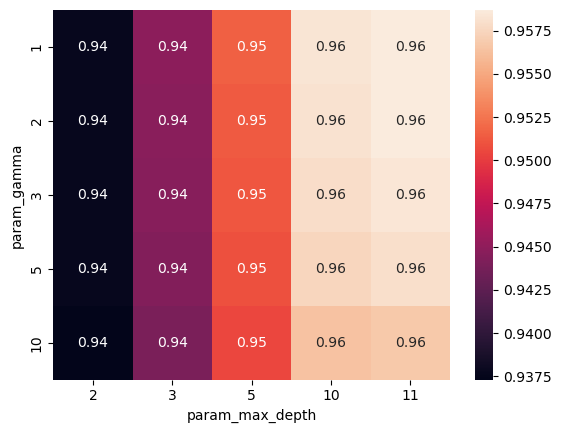

In [24]:
import seaborn as sns

grid_results_df = pd.DataFrame(grid_search.cv_results_)

viz_data = grid_results_df.pivot_table(index='param_gamma', columns='param_max_depth', values='mean_test_score')
sns.heatmap(viz_data, annot=True)

<Axes: xlabel='param_colsample_bytree', ylabel='param_learning_rate'>

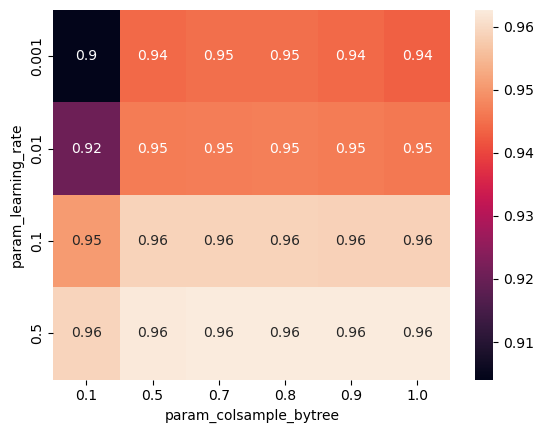

In [25]:
import seaborn as sns

grid_results_df = pd.DataFrame(grid_search.cv_results_)

viz_data = grid_results_df.pivot_table(index='param_learning_rate', columns='param_colsample_bytree', values='mean_test_score')
sns.heatmap(viz_data, annot=True)

<Axes: xlabel='param_colsample_bytree', ylabel='param_max_depth'>

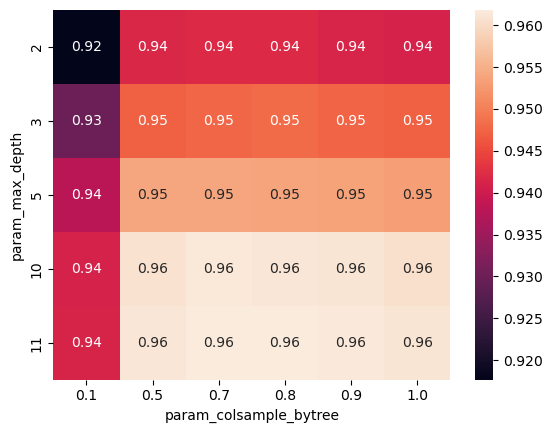

In [26]:
import seaborn as sns

grid_results_df = pd.DataFrame(grid_search.cv_results_)

viz_data = grid_results_df.pivot_table(index='param_max_depth', columns='param_colsample_bytree', values='mean_test_score')
sns.heatmap(viz_data, annot=True)

In [27]:
xgb_tuned = XGBClassifier(max_depth=11, colsample_bytree=0.8, learning_rate=0.5)

train_X, val_X, train_y, val_y = train_test_split(X_adjusted_filters, y)
xgb_tuned.fit(train_X, train_y)
val_predictions = xgb_tuned.predict(val_X)
print(f"Balanced accuracy score for fine-tuned xgb model: {balanced_accuracy_score(val_y, val_predictions)}")

Balanced accuracy score for fine-tuned xgb model: 0.9544297265818935


In [28]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(train_X, train_y)
val_predictions = gnb.predict(val_X)
print(f"Balanced accuracy score for gnb model: {balanced_accuracy_score(val_y, val_predictions)}")

Balanced accuracy score for gnb model: 0.8773298823809438


/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(train_X, train_y)
val_predictions = knn.predict(val_X)
print(f"Balanced accuracy score for knn model: {balanced_accuracy_score(val_y, val_predictions)}")

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Balanced accuracy score for knn model: 0.9181121547508223


In [30]:
# Fine tune kneighborsclassifier

param_grid = {
    'n_neighbors': [9, 7, 5, 3],
    'metric': ['minkowski', 'chebyshev'],
    'weights': ['uniform', 'distance']
    
}
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(train_X, train_y)

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['minkowski', 'chebyshev'], 'n_neighbors': [9, 7, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,5


<Axes: xlabel='param_metric', ylabel='param_n_neighbors'>

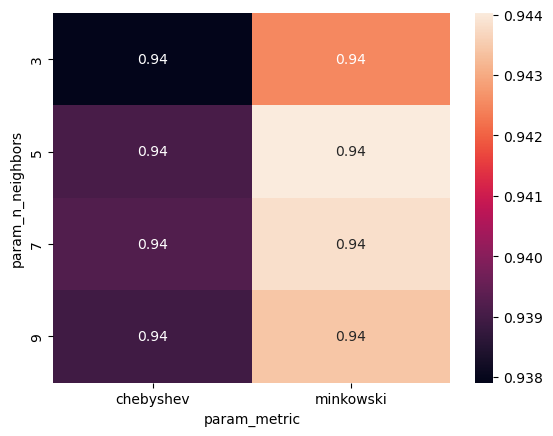

In [31]:
grid_results_df = pd.DataFrame(grid_search.cv_results_)

viz_data = grid_results_df.pivot_table(index='param_n_neighbors', columns='param_metric', values='mean_test_score')
sns.heatmap(viz_data, annot=True)

<Axes: xlabel='param_weights', ylabel='param_n_neighbors'>

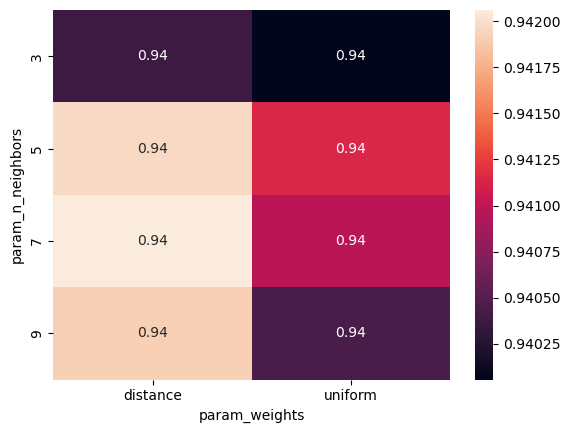

In [32]:
grid_results_df = pd.DataFrame(grid_search.cv_results_)

viz_data = grid_results_df.pivot_table(index='param_n_neighbors', columns='param_weights', values='mean_test_score')
sns.heatmap(viz_data, annot=True)

In [33]:
knn_tuned = KNeighborsClassifier(n_neighbors=7, metric='minkowski', weights="distance")

knn_tuned.fit(train_X, train_y)
val_predictions = knn_tuned.predict(val_X)
print(f"Balanced accuracy score for tuned knn model: {balanced_accuracy_score(val_y, val_predictions)}")

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Balanced accuracy score for tuned knn model: 0.9191063609653264


In [34]:
from catboost import CatBoostClassifier
cbc = CatBoostClassifier()

cbc.fit(train_X, train_y)
val_predictions = cbc.predict(val_X)
print(f"Balanced accuracy score for tuned catboost model: {balanced_accuracy_score(val_y, val_predictions)}")

Learning rate set to 0.107841
0:	learn: 0.9298403	total: 94.2ms	remaining: 1m 34s
1:	learn: 0.8063729	total: 125ms	remaining: 1m 2s
2:	learn: 0.7101006	total: 156ms	remaining: 51.9s
3:	learn: 0.6326288	total: 187ms	remaining: 46.6s
4:	learn: 0.5694339	total: 216ms	remaining: 43.1s
5:	learn: 0.5163496	total: 246ms	remaining: 40.7s
6:	learn: 0.4716366	total: 275ms	remaining: 39s
7:	learn: 0.4332029	total: 305ms	remaining: 37.8s
8:	learn: 0.4001641	total: 335ms	remaining: 36.9s
9:	learn: 0.3714642	total: 366ms	remaining: 36.2s
10:	learn: 0.3461459	total: 397ms	remaining: 35.7s
11:	learn: 0.3240602	total: 428ms	remaining: 35.3s
12:	learn: 0.3047083	total: 460ms	remaining: 34.9s
13:	learn: 0.2874676	total: 491ms	remaining: 34.6s
14:	learn: 0.2725344	total: 521ms	remaining: 34.2s
15:	learn: 0.2589857	total: 554ms	remaining: 34s
16:	learn: 0.2471121	total: 585ms	remaining: 33.8s
17:	learn: 0.2363338	total: 616ms	remaining: 33.6s
18:	learn: 0.2270412	total: 646ms	remaining: 33.4s
19:	learn: 0.

163:	learn: 0.1075939	total: 4.8s	remaining: 24.5s
164:	learn: 0.1075151	total: 4.83s	remaining: 24.4s
165:	learn: 0.1074321	total: 4.86s	remaining: 24.4s
166:	learn: 0.1072911	total: 4.89s	remaining: 24.4s
167:	learn: 0.1070947	total: 4.92s	remaining: 24.3s
168:	learn: 0.1070007	total: 4.94s	remaining: 24.3s
169:	learn: 0.1068825	total: 4.97s	remaining: 24.3s
170:	learn: 0.1067333	total: 5s	remaining: 24.2s
171:	learn: 0.1066879	total: 5.03s	remaining: 24.2s
172:	learn: 0.1066180	total: 5.06s	remaining: 24.2s
173:	learn: 0.1064489	total: 5.08s	remaining: 24.1s
174:	learn: 0.1062949	total: 5.11s	remaining: 24.1s
175:	learn: 0.1062257	total: 5.14s	remaining: 24.1s
176:	learn: 0.1061337	total: 5.17s	remaining: 24.1s
177:	learn: 0.1060649	total: 5.2s	remaining: 24s
178:	learn: 0.1059220	total: 5.23s	remaining: 24s
179:	learn: 0.1058791	total: 5.26s	remaining: 24s
180:	learn: 0.1057699	total: 5.29s	remaining: 23.9s
181:	learn: 0.1057061	total: 5.32s	remaining: 23.9s
182:	learn: 0.1055993	t

322:	learn: 0.0983925	total: 9.37s	remaining: 19.6s
323:	learn: 0.0983773	total: 9.41s	remaining: 19.6s
324:	learn: 0.0983599	total: 9.43s	remaining: 19.6s
325:	learn: 0.0982992	total: 9.46s	remaining: 19.6s
326:	learn: 0.0982485	total: 9.49s	remaining: 19.5s
327:	learn: 0.0982228	total: 9.52s	remaining: 19.5s
328:	learn: 0.0981932	total: 9.54s	remaining: 19.5s
329:	learn: 0.0981774	total: 9.57s	remaining: 19.4s
330:	learn: 0.0981193	total: 9.6s	remaining: 19.4s
331:	learn: 0.0980833	total: 9.63s	remaining: 19.4s
332:	learn: 0.0980571	total: 9.66s	remaining: 19.4s
333:	learn: 0.0980450	total: 9.69s	remaining: 19.3s
334:	learn: 0.0980106	total: 9.72s	remaining: 19.3s
335:	learn: 0.0979514	total: 9.75s	remaining: 19.3s
336:	learn: 0.0979325	total: 9.78s	remaining: 19.2s
337:	learn: 0.0978707	total: 9.81s	remaining: 19.2s
338:	learn: 0.0978497	total: 9.84s	remaining: 19.2s
339:	learn: 0.0978435	total: 9.87s	remaining: 19.2s
340:	learn: 0.0978251	total: 9.9s	remaining: 19.1s
341:	learn: 0.

482:	learn: 0.0943482	total: 13.9s	remaining: 14.9s
483:	learn: 0.0943412	total: 14s	remaining: 14.9s
484:	learn: 0.0943319	total: 14s	remaining: 14.9s
485:	learn: 0.0943224	total: 14s	remaining: 14.8s
486:	learn: 0.0943126	total: 14.1s	remaining: 14.8s
487:	learn: 0.0942945	total: 14.1s	remaining: 14.8s
488:	learn: 0.0942801	total: 14.1s	remaining: 14.8s
489:	learn: 0.0942511	total: 14.1s	remaining: 14.7s
490:	learn: 0.0942340	total: 14.2s	remaining: 14.7s
491:	learn: 0.0942205	total: 14.2s	remaining: 14.7s
492:	learn: 0.0941796	total: 14.2s	remaining: 14.6s
493:	learn: 0.0941542	total: 14.3s	remaining: 14.6s
494:	learn: 0.0941408	total: 14.3s	remaining: 14.6s
495:	learn: 0.0940722	total: 14.3s	remaining: 14.6s
496:	learn: 0.0940170	total: 14.3s	remaining: 14.5s
497:	learn: 0.0939974	total: 14.4s	remaining: 14.5s
498:	learn: 0.0939786	total: 14.4s	remaining: 14.5s
499:	learn: 0.0939579	total: 14.4s	remaining: 14.4s
500:	learn: 0.0939314	total: 14.5s	remaining: 14.4s
501:	learn: 0.0939

642:	learn: 0.0912270	total: 18.5s	remaining: 10.3s
643:	learn: 0.0912060	total: 18.6s	remaining: 10.3s
644:	learn: 0.0911883	total: 18.6s	remaining: 10.2s
645:	learn: 0.0911818	total: 18.6s	remaining: 10.2s
646:	learn: 0.0911583	total: 18.6s	remaining: 10.2s
647:	learn: 0.0911458	total: 18.7s	remaining: 10.1s
648:	learn: 0.0911257	total: 18.7s	remaining: 10.1s
649:	learn: 0.0911112	total: 18.7s	remaining: 10.1s
650:	learn: 0.0910889	total: 18.8s	remaining: 10.1s
651:	learn: 0.0910770	total: 18.8s	remaining: 10s
652:	learn: 0.0910642	total: 18.8s	remaining: 10s
653:	learn: 0.0910457	total: 18.9s	remaining: 9.98s
654:	learn: 0.0910355	total: 18.9s	remaining: 9.95s
655:	learn: 0.0910134	total: 18.9s	remaining: 9.92s
656:	learn: 0.0910011	total: 18.9s	remaining: 9.89s
657:	learn: 0.0909864	total: 19s	remaining: 9.86s
658:	learn: 0.0909672	total: 19s	remaining: 9.83s
659:	learn: 0.0909557	total: 19s	remaining: 9.8s
660:	learn: 0.0909461	total: 19.1s	remaining: 9.77s
661:	learn: 0.0909376	t

803:	learn: 0.0891030	total: 23.1s	remaining: 5.63s
804:	learn: 0.0890947	total: 23.1s	remaining: 5.6s
805:	learn: 0.0890735	total: 23.2s	remaining: 5.57s
806:	learn: 0.0890677	total: 23.2s	remaining: 5.54s
807:	learn: 0.0890581	total: 23.2s	remaining: 5.51s
808:	learn: 0.0890460	total: 23.2s	remaining: 5.49s
809:	learn: 0.0890399	total: 23.3s	remaining: 5.46s
810:	learn: 0.0890174	total: 23.3s	remaining: 5.43s
811:	learn: 0.0890122	total: 23.3s	remaining: 5.4s
812:	learn: 0.0889801	total: 23.3s	remaining: 5.37s
813:	learn: 0.0889664	total: 23.4s	remaining: 5.34s
814:	learn: 0.0889555	total: 23.4s	remaining: 5.31s
815:	learn: 0.0889441	total: 23.4s	remaining: 5.28s
816:	learn: 0.0889207	total: 23.5s	remaining: 5.26s
817:	learn: 0.0889161	total: 23.5s	remaining: 5.23s
818:	learn: 0.0889042	total: 23.5s	remaining: 5.2s
819:	learn: 0.0888887	total: 23.6s	remaining: 5.17s
820:	learn: 0.0888806	total: 23.6s	remaining: 5.14s
821:	learn: 0.0888672	total: 23.6s	remaining: 5.12s
822:	learn: 0.0

969:	learn: 0.0871913	total: 27.8s	remaining: 861ms
970:	learn: 0.0871830	total: 27.9s	remaining: 833ms
971:	learn: 0.0871684	total: 27.9s	remaining: 804ms
972:	learn: 0.0871583	total: 27.9s	remaining: 775ms
973:	learn: 0.0871463	total: 28s	remaining: 747ms
974:	learn: 0.0871294	total: 28s	remaining: 718ms
975:	learn: 0.0871216	total: 28s	remaining: 689ms
976:	learn: 0.0871143	total: 28s	remaining: 660ms
977:	learn: 0.0871046	total: 28.1s	remaining: 632ms
978:	learn: 0.0870963	total: 28.1s	remaining: 603ms
979:	learn: 0.0870839	total: 28.1s	remaining: 574ms
980:	learn: 0.0870707	total: 28.2s	remaining: 545ms
981:	learn: 0.0870623	total: 28.2s	remaining: 517ms
982:	learn: 0.0870126	total: 28.2s	remaining: 488ms
983:	learn: 0.0870054	total: 28.2s	remaining: 459ms
984:	learn: 0.0869964	total: 28.3s	remaining: 431ms
985:	learn: 0.0869869	total: 28.3s	remaining: 402ms
986:	learn: 0.0869789	total: 28.3s	remaining: 373ms
987:	learn: 0.0869708	total: 28.4s	remaining: 344ms
988:	learn: 0.086962

In [39]:
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import StackingClassifier

base_models = [
    ('xgb', XGBClassifier(max_depth=11, colsample_bytree=0.8, learning_rate=0.5)),
    ('knn', KNeighborsClassifier(n_neighbors=7, metric='minkowski', weights="distance")), 
    ('gnb', GaussianNB()),
    ('cbc', CatBoostClassifier())
]

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegressionCV(max_iter=1000),
    cv=5
)

stack.fit(X_adjusted_filters, y)

scores = cross_val_score(stack, X_adjusted_filters, y, cv=5, scoring='balanced_accuracy')

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Learning rate set to 0.109435
0:	learn: 0.9270019	total: 62.3ms	remaining: 1m 2s
1:	learn: 0.8024353	total: 105ms	remaining: 52.5s
2:	learn: 0.7058090	total: 144ms	remaining: 47.9s
3:	learn: 0.6278589	total: 185ms	remaining: 46.1s
4:	learn: 0.5644751	total: 224ms	remaining: 44.5s
5:	learn: 0.5110434	total: 262ms	remaining: 43.4s
6:	learn: 0.4664686	total: 301ms	remaining: 42.7s
7:	learn: 0.4278499	total: 344ms	remaining: 42.6s
8:	learn: 0.3952095	total: 383ms	remaining: 42.2s
9:	learn: 0.3663859	total: 425ms	remaining: 42s
10:	learn: 0.3416017	total: 465ms	remaining: 41.8s
11:	learn: 0.3195507	total: 501ms	remaining: 41.3s
12:	learn: 0.3003836	total: 540ms	remaining: 41s
13:	learn: 0.2834899	total: 578ms	remaining: 40.7s
14:	learn: 0.2681951	total: 614ms	remaining: 40.3s
15:	learn: 0.2550493	total: 658ms	remaining: 40.5s
16:	learn: 0.2431279	total: 694ms	remaining: 40.1s
17:	learn: 0.2323234	total: 734ms	remaining: 40s
18:	learn: 0.2229239	total: 774ms	remaining: 40s
19:	learn: 0.21418

162:	learn: 0.1069789	total: 6.06s	remaining: 31.1s
163:	learn: 0.1068466	total: 6.1s	remaining: 31.1s
164:	learn: 0.1067810	total: 6.14s	remaining: 31.1s
165:	learn: 0.1067469	total: 6.17s	remaining: 31s
166:	learn: 0.1066582	total: 6.21s	remaining: 31s
167:	learn: 0.1065469	total: 6.24s	remaining: 30.9s
168:	learn: 0.1064301	total: 6.28s	remaining: 30.9s
169:	learn: 0.1063159	total: 6.32s	remaining: 30.9s
170:	learn: 0.1061799	total: 6.35s	remaining: 30.8s
171:	learn: 0.1060778	total: 6.39s	remaining: 30.8s
172:	learn: 0.1060295	total: 6.42s	remaining: 30.7s
173:	learn: 0.1059869	total: 6.46s	remaining: 30.7s
174:	learn: 0.1059260	total: 6.5s	remaining: 30.6s
175:	learn: 0.1058027	total: 6.54s	remaining: 30.6s
176:	learn: 0.1057272	total: 6.58s	remaining: 30.6s
177:	learn: 0.1056841	total: 6.61s	remaining: 30.5s
178:	learn: 0.1056457	total: 6.64s	remaining: 30.5s
179:	learn: 0.1055527	total: 6.68s	remaining: 30.4s
180:	learn: 0.1054213	total: 6.72s	remaining: 30.4s
181:	learn: 0.1053

322:	learn: 0.0979640	total: 12s	remaining: 25.1s
323:	learn: 0.0979499	total: 12s	remaining: 25s
324:	learn: 0.0979262	total: 12s	remaining: 25s
325:	learn: 0.0978292	total: 12.1s	remaining: 25s
326:	learn: 0.0978120	total: 12.1s	remaining: 24.9s
327:	learn: 0.0977505	total: 12.2s	remaining: 24.9s
328:	learn: 0.0977415	total: 12.2s	remaining: 24.9s
329:	learn: 0.0977136	total: 12.2s	remaining: 24.8s
330:	learn: 0.0976866	total: 12.3s	remaining: 24.8s
331:	learn: 0.0976726	total: 12.3s	remaining: 24.7s
332:	learn: 0.0976162	total: 12.3s	remaining: 24.7s
333:	learn: 0.0975875	total: 12.4s	remaining: 24.7s
334:	learn: 0.0975259	total: 12.4s	remaining: 24.6s
335:	learn: 0.0975106	total: 12.4s	remaining: 24.6s
336:	learn: 0.0974953	total: 12.5s	remaining: 24.6s
337:	learn: 0.0974757	total: 12.5s	remaining: 24.5s
338:	learn: 0.0973930	total: 12.6s	remaining: 24.5s
339:	learn: 0.0973577	total: 12.6s	remaining: 24.4s
340:	learn: 0.0973374	total: 12.6s	remaining: 24.4s
341:	learn: 0.0973252	to

482:	learn: 0.0939792	total: 17.9s	remaining: 19.2s
483:	learn: 0.0939155	total: 18s	remaining: 19.2s
484:	learn: 0.0938942	total: 18s	remaining: 19.1s
485:	learn: 0.0938842	total: 18.1s	remaining: 19.1s
486:	learn: 0.0938777	total: 18.1s	remaining: 19.1s
487:	learn: 0.0938722	total: 18.1s	remaining: 19s
488:	learn: 0.0938510	total: 18.2s	remaining: 19s
489:	learn: 0.0938097	total: 18.2s	remaining: 19s
490:	learn: 0.0937977	total: 18.2s	remaining: 18.9s
491:	learn: 0.0937859	total: 18.3s	remaining: 18.9s
492:	learn: 0.0937755	total: 18.3s	remaining: 18.8s
493:	learn: 0.0937409	total: 18.3s	remaining: 18.8s
494:	learn: 0.0937243	total: 18.4s	remaining: 18.8s
495:	learn: 0.0937012	total: 18.4s	remaining: 18.7s
496:	learn: 0.0936727	total: 18.5s	remaining: 18.7s
497:	learn: 0.0936586	total: 18.5s	remaining: 18.7s
498:	learn: 0.0936410	total: 18.5s	remaining: 18.6s
499:	learn: 0.0936331	total: 18.6s	remaining: 18.6s
500:	learn: 0.0936113	total: 18.6s	remaining: 18.5s
501:	learn: 0.0935980	

641:	learn: 0.0913587	total: 24s	remaining: 13.4s
642:	learn: 0.0913526	total: 24.1s	remaining: 13.4s
643:	learn: 0.0913437	total: 24.1s	remaining: 13.3s
644:	learn: 0.0913328	total: 24.1s	remaining: 13.3s
645:	learn: 0.0913262	total: 24.2s	remaining: 13.2s
646:	learn: 0.0913180	total: 24.2s	remaining: 13.2s
647:	learn: 0.0912982	total: 24.2s	remaining: 13.2s
648:	learn: 0.0912897	total: 24.3s	remaining: 13.1s
649:	learn: 0.0912811	total: 24.3s	remaining: 13.1s
650:	learn: 0.0912710	total: 24.3s	remaining: 13s
651:	learn: 0.0912592	total: 24.4s	remaining: 13s
652:	learn: 0.0912475	total: 24.4s	remaining: 13s
653:	learn: 0.0912405	total: 24.4s	remaining: 12.9s
654:	learn: 0.0912149	total: 24.5s	remaining: 12.9s
655:	learn: 0.0912124	total: 24.5s	remaining: 12.9s
656:	learn: 0.0912060	total: 24.6s	remaining: 12.8s
657:	learn: 0.0911976	total: 24.6s	remaining: 12.8s
658:	learn: 0.0911846	total: 24.6s	remaining: 12.7s
659:	learn: 0.0911580	total: 24.7s	remaining: 12.7s
660:	learn: 0.091151

805:	learn: 0.0895478	total: 30.1s	remaining: 7.25s
806:	learn: 0.0895358	total: 30.2s	remaining: 7.21s
807:	learn: 0.0895274	total: 30.2s	remaining: 7.18s
808:	learn: 0.0894767	total: 30.2s	remaining: 7.14s
809:	learn: 0.0894682	total: 30.3s	remaining: 7.1s
810:	learn: 0.0894549	total: 30.3s	remaining: 7.07s
811:	learn: 0.0894454	total: 30.4s	remaining: 7.03s
812:	learn: 0.0894399	total: 30.4s	remaining: 6.99s
813:	learn: 0.0894179	total: 30.4s	remaining: 6.95s
814:	learn: 0.0894083	total: 30.5s	remaining: 6.92s
815:	learn: 0.0893835	total: 30.5s	remaining: 6.88s
816:	learn: 0.0893787	total: 30.5s	remaining: 6.84s
817:	learn: 0.0893740	total: 30.6s	remaining: 6.8s
818:	learn: 0.0893643	total: 30.6s	remaining: 6.77s
819:	learn: 0.0893585	total: 30.7s	remaining: 6.73s
820:	learn: 0.0893469	total: 30.7s	remaining: 6.7s
821:	learn: 0.0893413	total: 30.8s	remaining: 6.66s
822:	learn: 0.0893353	total: 30.8s	remaining: 6.62s
823:	learn: 0.0893250	total: 30.8s	remaining: 6.59s
824:	learn: 0.0

965:	learn: 0.0878488	total: 36.3s	remaining: 1.28s
966:	learn: 0.0878439	total: 36.3s	remaining: 1.24s
967:	learn: 0.0878347	total: 36.4s	remaining: 1.2s
968:	learn: 0.0878231	total: 36.4s	remaining: 1.16s
969:	learn: 0.0878172	total: 36.5s	remaining: 1.13s
970:	learn: 0.0878085	total: 36.5s	remaining: 1.09s
971:	learn: 0.0877951	total: 36.5s	remaining: 1.05s
972:	learn: 0.0877863	total: 36.6s	remaining: 1.01s
973:	learn: 0.0877780	total: 36.6s	remaining: 977ms
974:	learn: 0.0877630	total: 36.6s	remaining: 939ms
975:	learn: 0.0877549	total: 36.7s	remaining: 902ms
976:	learn: 0.0877486	total: 36.7s	remaining: 864ms
977:	learn: 0.0877379	total: 36.7s	remaining: 827ms
978:	learn: 0.0877149	total: 36.8s	remaining: 789ms
979:	learn: 0.0876802	total: 36.8s	remaining: 751ms
980:	learn: 0.0876697	total: 36.9s	remaining: 714ms
981:	learn: 0.0876643	total: 36.9s	remaining: 676ms
982:	learn: 0.0876573	total: 36.9s	remaining: 639ms
983:	learn: 0.0876518	total: 37s	remaining: 601ms
984:	learn: 0.0

125:	learn: 0.1115799	total: 5.48s	remaining: 38s
126:	learn: 0.1114454	total: 5.52s	remaining: 37.9s
127:	learn: 0.1112606	total: 5.57s	remaining: 38s
128:	learn: 0.1110915	total: 5.61s	remaining: 37.9s
129:	learn: 0.1109498	total: 5.66s	remaining: 37.9s
130:	learn: 0.1107190	total: 5.7s	remaining: 37.8s
131:	learn: 0.1106096	total: 5.74s	remaining: 37.8s
132:	learn: 0.1105249	total: 5.78s	remaining: 37.7s
133:	learn: 0.1104237	total: 5.82s	remaining: 37.6s
134:	learn: 0.1103398	total: 5.86s	remaining: 37.6s
135:	learn: 0.1102781	total: 5.9s	remaining: 37.5s
136:	learn: 0.1100718	total: 5.94s	remaining: 37.4s
137:	learn: 0.1099453	total: 5.99s	remaining: 37.4s
138:	learn: 0.1098637	total: 6.02s	remaining: 37.3s
139:	learn: 0.1097113	total: 6.07s	remaining: 37.3s
140:	learn: 0.1094655	total: 6.11s	remaining: 37.2s
141:	learn: 0.1093572	total: 6.14s	remaining: 37.1s
142:	learn: 0.1091616	total: 6.19s	remaining: 37.1s
143:	learn: 0.1090559	total: 6.23s	remaining: 37s
144:	learn: 0.108951

288:	learn: 0.0988776	total: 12.4s	remaining: 30.6s
289:	learn: 0.0988257	total: 12.5s	remaining: 30.6s
290:	learn: 0.0987926	total: 12.5s	remaining: 30.5s
291:	learn: 0.0987789	total: 12.6s	remaining: 30.5s
292:	learn: 0.0987565	total: 12.6s	remaining: 30.4s
293:	learn: 0.0987144	total: 12.7s	remaining: 30.4s
294:	learn: 0.0986317	total: 12.7s	remaining: 30.4s
295:	learn: 0.0986031	total: 12.7s	remaining: 30.3s
296:	learn: 0.0985812	total: 12.8s	remaining: 30.3s
297:	learn: 0.0985487	total: 12.8s	remaining: 30.3s
298:	learn: 0.0984876	total: 12.9s	remaining: 30.2s
299:	learn: 0.0984431	total: 13s	remaining: 30.2s
300:	learn: 0.0984000	total: 13s	remaining: 30.2s
301:	learn: 0.0983895	total: 13s	remaining: 30.2s
302:	learn: 0.0983567	total: 13.1s	remaining: 30.1s
303:	learn: 0.0983233	total: 13.1s	remaining: 30.1s
304:	learn: 0.0982997	total: 13.2s	remaining: 30s
305:	learn: 0.0982758	total: 13.2s	remaining: 30s
306:	learn: 0.0982473	total: 13.3s	remaining: 30s
307:	learn: 0.0982248	to

448:	learn: 0.0942861	total: 19.3s	remaining: 23.7s
449:	learn: 0.0942441	total: 19.4s	remaining: 23.6s
450:	learn: 0.0942316	total: 19.4s	remaining: 23.6s
451:	learn: 0.0942185	total: 19.4s	remaining: 23.6s
452:	learn: 0.0942043	total: 19.5s	remaining: 23.5s
453:	learn: 0.0941895	total: 19.5s	remaining: 23.5s
454:	learn: 0.0941752	total: 19.6s	remaining: 23.4s
455:	learn: 0.0941631	total: 19.6s	remaining: 23.4s
456:	learn: 0.0941271	total: 19.6s	remaining: 23.3s
457:	learn: 0.0941112	total: 19.7s	remaining: 23.3s
458:	learn: 0.0940451	total: 19.7s	remaining: 23.2s
459:	learn: 0.0940274	total: 19.8s	remaining: 23.2s
460:	learn: 0.0940110	total: 19.8s	remaining: 23.1s
461:	learn: 0.0939814	total: 19.8s	remaining: 23.1s
462:	learn: 0.0939670	total: 19.9s	remaining: 23s
463:	learn: 0.0939552	total: 19.9s	remaining: 23s
464:	learn: 0.0939467	total: 20s	remaining: 23s
465:	learn: 0.0939339	total: 20s	remaining: 22.9s
466:	learn: 0.0939065	total: 20s	remaining: 22.9s
467:	learn: 0.0938827	to

611:	learn: 0.0913403	total: 26.1s	remaining: 16.6s
612:	learn: 0.0913292	total: 26.2s	remaining: 16.5s
613:	learn: 0.0913190	total: 26.2s	remaining: 16.5s
614:	learn: 0.0913015	total: 26.2s	remaining: 16.4s
615:	learn: 0.0912728	total: 26.3s	remaining: 16.4s
616:	learn: 0.0912580	total: 26.3s	remaining: 16.3s
617:	learn: 0.0912211	total: 26.4s	remaining: 16.3s
618:	learn: 0.0911998	total: 26.4s	remaining: 16.3s
619:	learn: 0.0911710	total: 26.5s	remaining: 16.2s
620:	learn: 0.0911408	total: 26.5s	remaining: 16.2s
621:	learn: 0.0911333	total: 26.6s	remaining: 16.1s
622:	learn: 0.0911208	total: 26.6s	remaining: 16.1s
623:	learn: 0.0911013	total: 26.6s	remaining: 16s
624:	learn: 0.0910677	total: 26.7s	remaining: 16s
625:	learn: 0.0910587	total: 26.7s	remaining: 16s
626:	learn: 0.0910332	total: 26.7s	remaining: 15.9s
627:	learn: 0.0910242	total: 26.8s	remaining: 15.9s
628:	learn: 0.0910102	total: 26.8s	remaining: 15.8s
629:	learn: 0.0909972	total: 26.9s	remaining: 15.8s
630:	learn: 0.0909

775:	learn: 0.0889406	total: 33.1s	remaining: 9.55s
776:	learn: 0.0889331	total: 33.1s	remaining: 9.51s
777:	learn: 0.0889234	total: 33.2s	remaining: 9.47s
778:	learn: 0.0889094	total: 33.2s	remaining: 9.43s
779:	learn: 0.0888978	total: 33.3s	remaining: 9.38s
780:	learn: 0.0888853	total: 33.3s	remaining: 9.34s
781:	learn: 0.0888737	total: 33.3s	remaining: 9.3s
782:	learn: 0.0888662	total: 33.4s	remaining: 9.25s
783:	learn: 0.0888536	total: 33.4s	remaining: 9.21s
784:	learn: 0.0888502	total: 33.5s	remaining: 9.16s
785:	learn: 0.0888445	total: 33.5s	remaining: 9.12s
786:	learn: 0.0888319	total: 33.5s	remaining: 9.08s
787:	learn: 0.0888166	total: 33.6s	remaining: 9.04s
788:	learn: 0.0888108	total: 33.6s	remaining: 8.99s
789:	learn: 0.0888067	total: 33.7s	remaining: 8.95s
790:	learn: 0.0887987	total: 33.7s	remaining: 8.91s
791:	learn: 0.0887899	total: 33.8s	remaining: 8.87s
792:	learn: 0.0887796	total: 33.8s	remaining: 8.83s
793:	learn: 0.0887734	total: 33.9s	remaining: 8.78s
794:	learn: 0

935:	learn: 0.0871416	total: 39.7s	remaining: 2.71s
936:	learn: 0.0871301	total: 39.8s	remaining: 2.67s
937:	learn: 0.0871280	total: 39.8s	remaining: 2.63s
938:	learn: 0.0871158	total: 39.9s	remaining: 2.59s
939:	learn: 0.0871080	total: 39.9s	remaining: 2.55s
940:	learn: 0.0871021	total: 39.9s	remaining: 2.5s
941:	learn: 0.0870757	total: 40s	remaining: 2.46s
942:	learn: 0.0870667	total: 40.1s	remaining: 2.42s
943:	learn: 0.0870501	total: 40.1s	remaining: 2.38s
944:	learn: 0.0870414	total: 40.2s	remaining: 2.34s
945:	learn: 0.0870294	total: 40.2s	remaining: 2.29s
946:	learn: 0.0870189	total: 40.3s	remaining: 2.25s
947:	learn: 0.0870147	total: 40.3s	remaining: 2.21s
948:	learn: 0.0870129	total: 40.3s	remaining: 2.17s
949:	learn: 0.0870035	total: 40.4s	remaining: 2.13s
950:	learn: 0.0869898	total: 40.4s	remaining: 2.08s
951:	learn: 0.0869837	total: 40.5s	remaining: 2.04s
952:	learn: 0.0869771	total: 40.5s	remaining: 2s
953:	learn: 0.0869693	total: 40.5s	remaining: 1.96s
954:	learn: 0.0869

96:	learn: 0.1164702	total: 4.22s	remaining: 39.3s
97:	learn: 0.1160935	total: 4.27s	remaining: 39.3s
98:	learn: 0.1159936	total: 4.31s	remaining: 39.3s
99:	learn: 0.1157305	total: 4.36s	remaining: 39.3s
100:	learn: 0.1155381	total: 4.41s	remaining: 39.3s
101:	learn: 0.1153270	total: 4.46s	remaining: 39.2s
102:	learn: 0.1151799	total: 4.5s	remaining: 39.2s
103:	learn: 0.1150240	total: 4.54s	remaining: 39.1s
104:	learn: 0.1148632	total: 4.58s	remaining: 39s
105:	learn: 0.1147596	total: 4.62s	remaining: 39s
106:	learn: 0.1146031	total: 4.67s	remaining: 38.9s
107:	learn: 0.1144346	total: 4.72s	remaining: 39s
108:	learn: 0.1141655	total: 4.76s	remaining: 38.9s
109:	learn: 0.1139749	total: 4.81s	remaining: 38.9s
110:	learn: 0.1137086	total: 4.85s	remaining: 38.9s
111:	learn: 0.1136060	total: 4.89s	remaining: 38.8s
112:	learn: 0.1133026	total: 4.93s	remaining: 38.7s
113:	learn: 0.1131447	total: 4.98s	remaining: 38.7s
114:	learn: 0.1129106	total: 5.02s	remaining: 38.6s
115:	learn: 0.1127957	t

255:	learn: 0.1004016	total: 11.6s	remaining: 33.6s
256:	learn: 0.1003390	total: 11.6s	remaining: 33.5s
257:	learn: 0.1003103	total: 11.6s	remaining: 33.5s
258:	learn: 0.1002756	total: 11.7s	remaining: 33.4s
259:	learn: 0.1002596	total: 11.7s	remaining: 33.3s
260:	learn: 0.1002080	total: 11.8s	remaining: 33.3s
261:	learn: 0.1001491	total: 11.8s	remaining: 33.2s
262:	learn: 0.1000804	total: 11.8s	remaining: 33.2s
263:	learn: 0.1000026	total: 11.9s	remaining: 33.1s
264:	learn: 0.0999133	total: 11.9s	remaining: 33.1s
265:	learn: 0.0998810	total: 12s	remaining: 33s
266:	learn: 0.0998550	total: 12s	remaining: 33s
267:	learn: 0.0998203	total: 12.1s	remaining: 32.9s
268:	learn: 0.0997824	total: 12.1s	remaining: 32.9s
269:	learn: 0.0997557	total: 12.1s	remaining: 32.8s
270:	learn: 0.0996598	total: 12.2s	remaining: 32.8s
271:	learn: 0.0996274	total: 12.2s	remaining: 32.8s
272:	learn: 0.0995886	total: 12.3s	remaining: 32.7s
273:	learn: 0.0995511	total: 12.3s	remaining: 32.7s
274:	learn: 0.099447

414:	learn: 0.0949539	total: 18.5s	remaining: 26.1s
415:	learn: 0.0949169	total: 18.6s	remaining: 26.1s
416:	learn: 0.0948834	total: 18.6s	remaining: 26s
417:	learn: 0.0948658	total: 18.7s	remaining: 26s
418:	learn: 0.0948594	total: 18.7s	remaining: 25.9s
419:	learn: 0.0948130	total: 18.7s	remaining: 25.9s
420:	learn: 0.0947760	total: 18.8s	remaining: 25.8s
421:	learn: 0.0947167	total: 18.8s	remaining: 25.8s
422:	learn: 0.0946857	total: 18.9s	remaining: 25.7s
423:	learn: 0.0946702	total: 18.9s	remaining: 25.7s
424:	learn: 0.0946453	total: 18.9s	remaining: 25.6s
425:	learn: 0.0946259	total: 19s	remaining: 25.6s
426:	learn: 0.0945925	total: 19s	remaining: 25.6s
427:	learn: 0.0945840	total: 19.1s	remaining: 25.5s
428:	learn: 0.0945556	total: 19.1s	remaining: 25.5s
429:	learn: 0.0945077	total: 19.2s	remaining: 25.4s
430:	learn: 0.0944943	total: 19.2s	remaining: 25.4s
431:	learn: 0.0944595	total: 19.3s	remaining: 25.3s
432:	learn: 0.0944285	total: 19.3s	remaining: 25.3s
433:	learn: 0.094416

577:	learn: 0.0915592	total: 25.3s	remaining: 18.5s
578:	learn: 0.0915491	total: 25.4s	remaining: 18.4s
579:	learn: 0.0915234	total: 25.4s	remaining: 18.4s
580:	learn: 0.0914943	total: 25.4s	remaining: 18.4s
581:	learn: 0.0914789	total: 25.5s	remaining: 18.3s
582:	learn: 0.0914707	total: 25.5s	remaining: 18.3s
583:	learn: 0.0914574	total: 25.6s	remaining: 18.2s
584:	learn: 0.0913992	total: 25.6s	remaining: 18.2s
585:	learn: 0.0913931	total: 25.7s	remaining: 18.1s
586:	learn: 0.0913816	total: 25.7s	remaining: 18.1s
587:	learn: 0.0913659	total: 25.8s	remaining: 18s
588:	learn: 0.0913568	total: 25.8s	remaining: 18s
589:	learn: 0.0913439	total: 25.8s	remaining: 17.9s
590:	learn: 0.0913333	total: 25.9s	remaining: 17.9s
591:	learn: 0.0913190	total: 25.9s	remaining: 17.9s
592:	learn: 0.0913032	total: 26s	remaining: 17.8s
593:	learn: 0.0912948	total: 26s	remaining: 17.8s
594:	learn: 0.0912767	total: 26s	remaining: 17.7s
595:	learn: 0.0912667	total: 26.1s	remaining: 17.7s
596:	learn: 0.0912477	

738:	learn: 0.0891341	total: 32.1s	remaining: 11.3s
739:	learn: 0.0891294	total: 32.1s	remaining: 11.3s
740:	learn: 0.0891228	total: 32.1s	remaining: 11.2s
741:	learn: 0.0891063	total: 32.2s	remaining: 11.2s
742:	learn: 0.0890973	total: 32.2s	remaining: 11.1s
743:	learn: 0.0890347	total: 32.3s	remaining: 11.1s
744:	learn: 0.0890145	total: 32.3s	remaining: 11.1s
745:	learn: 0.0890059	total: 32.4s	remaining: 11s
746:	learn: 0.0889958	total: 32.4s	remaining: 11s
747:	learn: 0.0889858	total: 32.5s	remaining: 10.9s
748:	learn: 0.0889719	total: 32.5s	remaining: 10.9s
749:	learn: 0.0889539	total: 32.5s	remaining: 10.8s
750:	learn: 0.0889432	total: 32.6s	remaining: 10.8s
751:	learn: 0.0889224	total: 32.6s	remaining: 10.8s
752:	learn: 0.0889040	total: 32.7s	remaining: 10.7s
753:	learn: 0.0888926	total: 32.7s	remaining: 10.7s
754:	learn: 0.0888814	total: 32.7s	remaining: 10.6s
755:	learn: 0.0888688	total: 32.8s	remaining: 10.6s
756:	learn: 0.0888563	total: 32.8s	remaining: 10.5s
757:	learn: 0.08

900:	learn: 0.0872698	total: 38.7s	remaining: 4.25s
901:	learn: 0.0872622	total: 38.7s	remaining: 4.21s
902:	learn: 0.0872543	total: 38.8s	remaining: 4.17s
903:	learn: 0.0872454	total: 38.8s	remaining: 4.12s
904:	learn: 0.0872387	total: 38.8s	remaining: 4.08s
905:	learn: 0.0872285	total: 38.9s	remaining: 4.03s
906:	learn: 0.0872153	total: 38.9s	remaining: 3.99s
907:	learn: 0.0871970	total: 39s	remaining: 3.95s
908:	learn: 0.0871857	total: 39s	remaining: 3.9s
909:	learn: 0.0871770	total: 39s	remaining: 3.86s
910:	learn: 0.0871705	total: 39.1s	remaining: 3.82s
911:	learn: 0.0871626	total: 39.1s	remaining: 3.77s
912:	learn: 0.0871529	total: 39.2s	remaining: 3.73s
913:	learn: 0.0871413	total: 39.2s	remaining: 3.69s
914:	learn: 0.0871321	total: 39.3s	remaining: 3.65s
915:	learn: 0.0871277	total: 39.3s	remaining: 3.6s
916:	learn: 0.0871218	total: 39.3s	remaining: 3.56s
917:	learn: 0.0871135	total: 39.4s	remaining: 3.52s
918:	learn: 0.0870917	total: 39.4s	remaining: 3.48s
919:	learn: 0.087078

61:	learn: 0.1283619	total: 2.63s	remaining: 39.8s
62:	learn: 0.1279519	total: 2.66s	remaining: 39.6s
63:	learn: 0.1273795	total: 2.71s	remaining: 39.6s
64:	learn: 0.1270427	total: 2.75s	remaining: 39.5s
65:	learn: 0.1264837	total: 2.8s	remaining: 39.6s
66:	learn: 0.1257946	total: 2.85s	remaining: 39.6s
67:	learn: 0.1254502	total: 2.88s	remaining: 39.5s
68:	learn: 0.1249679	total: 2.93s	remaining: 39.5s
69:	learn: 0.1246231	total: 2.96s	remaining: 39.3s
70:	learn: 0.1242396	total: 3s	remaining: 39.3s
71:	learn: 0.1239631	total: 3.04s	remaining: 39.2s
72:	learn: 0.1237560	total: 3.08s	remaining: 39.1s
73:	learn: 0.1235012	total: 3.11s	remaining: 38.9s
74:	learn: 0.1229185	total: 3.16s	remaining: 38.9s
75:	learn: 0.1225357	total: 3.2s	remaining: 38.9s
76:	learn: 0.1222491	total: 3.24s	remaining: 38.9s
77:	learn: 0.1219369	total: 3.28s	remaining: 38.8s
78:	learn: 0.1217068	total: 3.32s	remaining: 38.8s
79:	learn: 0.1211589	total: 3.37s	remaining: 38.7s
80:	learn: 0.1208013	total: 3.41s	re

222:	learn: 0.1023136	total: 9.29s	remaining: 32.4s
223:	learn: 0.1022699	total: 9.33s	remaining: 32.3s
224:	learn: 0.1021101	total: 9.37s	remaining: 32.3s
225:	learn: 0.1020476	total: 9.41s	remaining: 32.2s
226:	learn: 0.1019871	total: 9.45s	remaining: 32.2s
227:	learn: 0.1019022	total: 9.49s	remaining: 32.1s
228:	learn: 0.1018047	total: 9.53s	remaining: 32.1s
229:	learn: 0.1017657	total: 9.56s	remaining: 32s
230:	learn: 0.1017451	total: 9.6s	remaining: 32s
231:	learn: 0.1017101	total: 9.64s	remaining: 31.9s
232:	learn: 0.1016783	total: 9.68s	remaining: 31.9s
233:	learn: 0.1016497	total: 9.72s	remaining: 31.8s
234:	learn: 0.1016269	total: 9.75s	remaining: 31.7s
235:	learn: 0.1015976	total: 9.79s	remaining: 31.7s
236:	learn: 0.1015550	total: 9.83s	remaining: 31.7s
237:	learn: 0.1014885	total: 9.87s	remaining: 31.6s
238:	learn: 0.1013589	total: 9.92s	remaining: 31.6s
239:	learn: 0.1013298	total: 9.96s	remaining: 31.5s
240:	learn: 0.1012596	total: 9.99s	remaining: 31.5s
241:	learn: 0.101

385:	learn: 0.0961191	total: 16s	remaining: 25.4s
386:	learn: 0.0960609	total: 16s	remaining: 25.3s
387:	learn: 0.0960301	total: 16s	remaining: 25.3s
388:	learn: 0.0960137	total: 16.1s	remaining: 25.3s
389:	learn: 0.0960018	total: 16.1s	remaining: 25.2s
390:	learn: 0.0959867	total: 16.2s	remaining: 25.2s
391:	learn: 0.0959664	total: 16.2s	remaining: 25.1s
392:	learn: 0.0959480	total: 16.2s	remaining: 25.1s
393:	learn: 0.0959194	total: 16.3s	remaining: 25.1s
394:	learn: 0.0958837	total: 16.3s	remaining: 25s
395:	learn: 0.0958612	total: 16.4s	remaining: 25s
396:	learn: 0.0958269	total: 16.4s	remaining: 24.9s
397:	learn: 0.0958006	total: 16.5s	remaining: 24.9s
398:	learn: 0.0957920	total: 16.5s	remaining: 24.8s
399:	learn: 0.0957362	total: 16.5s	remaining: 24.8s
400:	learn: 0.0957070	total: 16.6s	remaining: 24.8s
401:	learn: 0.0956902	total: 16.6s	remaining: 24.7s
402:	learn: 0.0956631	total: 16.7s	remaining: 24.7s
403:	learn: 0.0956486	total: 16.7s	remaining: 24.6s
404:	learn: 0.0956367	

545:	learn: 0.0926159	total: 22.4s	remaining: 18.6s
546:	learn: 0.0925797	total: 22.5s	remaining: 18.6s
547:	learn: 0.0925696	total: 22.5s	remaining: 18.6s
548:	learn: 0.0925654	total: 22.5s	remaining: 18.5s
549:	learn: 0.0925295	total: 22.6s	remaining: 18.5s
550:	learn: 0.0925178	total: 22.6s	remaining: 18.4s
551:	learn: 0.0925089	total: 22.7s	remaining: 18.4s
552:	learn: 0.0924947	total: 22.7s	remaining: 18.3s
553:	learn: 0.0924833	total: 22.7s	remaining: 18.3s
554:	learn: 0.0924493	total: 22.8s	remaining: 18.3s
555:	learn: 0.0924273	total: 22.8s	remaining: 18.2s
556:	learn: 0.0923760	total: 22.8s	remaining: 18.2s
557:	learn: 0.0923687	total: 22.9s	remaining: 18.1s
558:	learn: 0.0923552	total: 22.9s	remaining: 18.1s
559:	learn: 0.0923423	total: 23s	remaining: 18s
560:	learn: 0.0923197	total: 23s	remaining: 18s
561:	learn: 0.0923088	total: 23.1s	remaining: 18s
562:	learn: 0.0922753	total: 23.1s	remaining: 17.9s
563:	learn: 0.0922509	total: 23.1s	remaining: 17.9s
564:	learn: 0.0922281	

707:	learn: 0.0900041	total: 29s	remaining: 11.9s
708:	learn: 0.0899933	total: 29s	remaining: 11.9s
709:	learn: 0.0899468	total: 29s	remaining: 11.9s
710:	learn: 0.0899384	total: 29.1s	remaining: 11.8s
711:	learn: 0.0899180	total: 29.1s	remaining: 11.8s
712:	learn: 0.0899096	total: 29.2s	remaining: 11.7s
713:	learn: 0.0898896	total: 29.2s	remaining: 11.7s
714:	learn: 0.0898789	total: 29.3s	remaining: 11.7s
715:	learn: 0.0898590	total: 29.3s	remaining: 11.6s
716:	learn: 0.0898464	total: 29.3s	remaining: 11.6s
717:	learn: 0.0898357	total: 29.4s	remaining: 11.5s
718:	learn: 0.0898104	total: 29.4s	remaining: 11.5s
719:	learn: 0.0898048	total: 29.4s	remaining: 11.4s
720:	learn: 0.0897575	total: 29.5s	remaining: 11.4s
721:	learn: 0.0897506	total: 29.5s	remaining: 11.4s
722:	learn: 0.0897353	total: 29.6s	remaining: 11.3s
723:	learn: 0.0897092	total: 29.6s	remaining: 11.3s
724:	learn: 0.0896823	total: 29.6s	remaining: 11.2s
725:	learn: 0.0896446	total: 29.7s	remaining: 11.2s
726:	learn: 0.0896

870:	learn: 0.0878826	total: 35.5s	remaining: 5.25s
871:	learn: 0.0878718	total: 35.5s	remaining: 5.21s
872:	learn: 0.0878664	total: 35.6s	remaining: 5.17s
873:	learn: 0.0878498	total: 35.6s	remaining: 5.13s
874:	learn: 0.0878404	total: 35.6s	remaining: 5.09s
875:	learn: 0.0878368	total: 35.7s	remaining: 5.05s
876:	learn: 0.0878143	total: 35.7s	remaining: 5.01s
877:	learn: 0.0877964	total: 35.8s	remaining: 4.97s
878:	learn: 0.0877878	total: 35.8s	remaining: 4.93s
879:	learn: 0.0877766	total: 35.8s	remaining: 4.89s
880:	learn: 0.0877717	total: 35.9s	remaining: 4.84s
881:	learn: 0.0877672	total: 35.9s	remaining: 4.8s
882:	learn: 0.0877586	total: 35.9s	remaining: 4.76s
883:	learn: 0.0877500	total: 36s	remaining: 4.72s
884:	learn: 0.0877430	total: 36s	remaining: 4.68s
885:	learn: 0.0877341	total: 36.1s	remaining: 4.64s
886:	learn: 0.0877247	total: 36.1s	remaining: 4.6s
887:	learn: 0.0877121	total: 36.1s	remaining: 4.56s
888:	learn: 0.0877002	total: 36.2s	remaining: 4.52s
889:	learn: 0.0876

30:	learn: 0.1628454	total: 1.28s	remaining: 40.1s
31:	learn: 0.1608656	total: 1.32s	remaining: 39.9s
32:	learn: 0.1589220	total: 1.35s	remaining: 39.7s
33:	learn: 0.1562744	total: 1.4s	remaining: 39.8s
34:	learn: 0.1541762	total: 1.44s	remaining: 39.8s
35:	learn: 0.1522854	total: 1.48s	remaining: 39.7s
36:	learn: 0.1505124	total: 1.52s	remaining: 39.5s
37:	learn: 0.1492162	total: 1.55s	remaining: 39.4s
38:	learn: 0.1478395	total: 1.59s	remaining: 39.2s
39:	learn: 0.1462445	total: 1.63s	remaining: 39.2s
40:	learn: 0.1448255	total: 1.67s	remaining: 39.2s
41:	learn: 0.1431100	total: 1.72s	remaining: 39.1s
42:	learn: 0.1419706	total: 1.75s	remaining: 38.9s
43:	learn: 0.1412472	total: 1.78s	remaining: 38.8s
44:	learn: 0.1404137	total: 1.82s	remaining: 38.6s
45:	learn: 0.1392444	total: 1.86s	remaining: 38.6s
46:	learn: 0.1380291	total: 1.91s	remaining: 38.8s
47:	learn: 0.1374411	total: 1.95s	remaining: 38.6s
48:	learn: 0.1368717	total: 1.99s	remaining: 38.5s
49:	learn: 0.1364251	total: 2.02

192:	learn: 0.1051952	total: 7.8s	remaining: 32.6s
193:	learn: 0.1051458	total: 7.84s	remaining: 32.6s
194:	learn: 0.1050154	total: 7.88s	remaining: 32.5s
195:	learn: 0.1048744	total: 7.92s	remaining: 32.5s
196:	learn: 0.1048146	total: 7.96s	remaining: 32.5s
197:	learn: 0.1046807	total: 8.01s	remaining: 32.4s
198:	learn: 0.1045755	total: 8.05s	remaining: 32.4s
199:	learn: 0.1044777	total: 8.09s	remaining: 32.4s
200:	learn: 0.1044110	total: 8.15s	remaining: 32.4s
201:	learn: 0.1043289	total: 8.19s	remaining: 32.4s
202:	learn: 0.1042682	total: 8.23s	remaining: 32.3s
203:	learn: 0.1042299	total: 8.26s	remaining: 32.2s
204:	learn: 0.1041181	total: 8.31s	remaining: 32.2s
205:	learn: 0.1040700	total: 8.34s	remaining: 32.1s
206:	learn: 0.1040300	total: 8.38s	remaining: 32.1s
207:	learn: 0.1039295	total: 8.44s	remaining: 32.1s
208:	learn: 0.1038942	total: 8.48s	remaining: 32.1s
209:	learn: 0.1038247	total: 8.51s	remaining: 32s
210:	learn: 0.1037895	total: 8.55s	remaining: 32s
211:	learn: 0.103

353:	learn: 0.0976247	total: 14.2s	remaining: 26s
354:	learn: 0.0976081	total: 14.3s	remaining: 25.9s
355:	learn: 0.0975891	total: 14.3s	remaining: 25.9s
356:	learn: 0.0975586	total: 14.4s	remaining: 25.9s
357:	learn: 0.0974979	total: 14.4s	remaining: 25.8s
358:	learn: 0.0974449	total: 14.4s	remaining: 25.8s
359:	learn: 0.0973901	total: 14.5s	remaining: 25.8s
360:	learn: 0.0973547	total: 14.5s	remaining: 25.7s
361:	learn: 0.0973306	total: 14.6s	remaining: 25.7s
362:	learn: 0.0972946	total: 14.6s	remaining: 25.6s
363:	learn: 0.0972833	total: 14.7s	remaining: 25.6s
364:	learn: 0.0972637	total: 14.7s	remaining: 25.5s
365:	learn: 0.0972431	total: 14.7s	remaining: 25.5s
366:	learn: 0.0972317	total: 14.8s	remaining: 25.5s
367:	learn: 0.0971947	total: 14.8s	remaining: 25.4s
368:	learn: 0.0971624	total: 14.8s	remaining: 25.4s
369:	learn: 0.0971425	total: 14.9s	remaining: 25.3s
370:	learn: 0.0971320	total: 14.9s	remaining: 25.3s
371:	learn: 0.0971120	total: 14.9s	remaining: 25.2s
372:	learn: 0.

512:	learn: 0.0937964	total: 20.4s	remaining: 19.4s
513:	learn: 0.0937744	total: 20.5s	remaining: 19.4s
514:	learn: 0.0937646	total: 20.5s	remaining: 19.3s
515:	learn: 0.0937511	total: 20.6s	remaining: 19.3s
516:	learn: 0.0937344	total: 20.6s	remaining: 19.2s
517:	learn: 0.0937219	total: 20.6s	remaining: 19.2s
518:	learn: 0.0937009	total: 20.7s	remaining: 19.2s
519:	learn: 0.0936827	total: 20.7s	remaining: 19.1s
520:	learn: 0.0936509	total: 20.7s	remaining: 19.1s
521:	learn: 0.0936362	total: 20.8s	remaining: 19s
522:	learn: 0.0936204	total: 20.8s	remaining: 19s
523:	learn: 0.0936091	total: 20.9s	remaining: 18.9s
524:	learn: 0.0935832	total: 20.9s	remaining: 18.9s
525:	learn: 0.0935761	total: 20.9s	remaining: 18.9s
526:	learn: 0.0935642	total: 21s	remaining: 18.8s
527:	learn: 0.0935533	total: 21s	remaining: 18.8s
528:	learn: 0.0935452	total: 21.1s	remaining: 18.7s
529:	learn: 0.0935270	total: 21.1s	remaining: 18.7s
530:	learn: 0.0935084	total: 21.1s	remaining: 18.7s
531:	learn: 0.093491

671:	learn: 0.0914449	total: 26.8s	remaining: 13.1s
672:	learn: 0.0914384	total: 26.9s	remaining: 13.1s
673:	learn: 0.0914317	total: 26.9s	remaining: 13s
674:	learn: 0.0914096	total: 26.9s	remaining: 13s
675:	learn: 0.0914020	total: 27s	remaining: 12.9s
676:	learn: 0.0913930	total: 27s	remaining: 12.9s
677:	learn: 0.0913873	total: 27s	remaining: 12.8s
678:	learn: 0.0913623	total: 27.1s	remaining: 12.8s
679:	learn: 0.0913479	total: 27.1s	remaining: 12.8s
680:	learn: 0.0913391	total: 27.2s	remaining: 12.7s
681:	learn: 0.0913208	total: 27.2s	remaining: 12.7s
682:	learn: 0.0913097	total: 27.2s	remaining: 12.6s
683:	learn: 0.0913025	total: 27.3s	remaining: 12.6s
684:	learn: 0.0912934	total: 27.3s	remaining: 12.6s
685:	learn: 0.0912826	total: 27.3s	remaining: 12.5s
686:	learn: 0.0912772	total: 27.4s	remaining: 12.5s
687:	learn: 0.0912671	total: 27.4s	remaining: 12.4s
688:	learn: 0.0912599	total: 27.4s	remaining: 12.4s
689:	learn: 0.0912505	total: 27.5s	remaining: 12.3s
690:	learn: 0.0912348	

831:	learn: 0.0891995	total: 32.8s	remaining: 6.63s
832:	learn: 0.0891946	total: 32.9s	remaining: 6.59s
833:	learn: 0.0891852	total: 32.9s	remaining: 6.55s
834:	learn: 0.0891721	total: 33s	remaining: 6.51s
835:	learn: 0.0891592	total: 33s	remaining: 6.47s
836:	learn: 0.0891549	total: 33s	remaining: 6.43s
837:	learn: 0.0891409	total: 33.1s	remaining: 6.39s
838:	learn: 0.0891315	total: 33.1s	remaining: 6.36s
839:	learn: 0.0891179	total: 33.2s	remaining: 6.32s
840:	learn: 0.0891141	total: 33.2s	remaining: 6.28s
841:	learn: 0.0890830	total: 33.2s	remaining: 6.24s
842:	learn: 0.0890753	total: 33.3s	remaining: 6.2s
843:	learn: 0.0890571	total: 33.3s	remaining: 6.16s
844:	learn: 0.0890252	total: 33.3s	remaining: 6.12s
845:	learn: 0.0890190	total: 33.4s	remaining: 6.08s
846:	learn: 0.0890030	total: 33.4s	remaining: 6.04s
847:	learn: 0.0889990	total: 33.5s	remaining: 6s
848:	learn: 0.0889906	total: 33.5s	remaining: 5.96s
849:	learn: 0.0889831	total: 33.5s	remaining: 5.92s
850:	learn: 0.0889672	

992:	learn: 0.0873209	total: 38.8s	remaining: 274ms
993:	learn: 0.0873150	total: 38.8s	remaining: 235ms
994:	learn: 0.0873086	total: 38.9s	remaining: 195ms
995:	learn: 0.0873002	total: 38.9s	remaining: 156ms
996:	learn: 0.0872951	total: 39s	remaining: 117ms
997:	learn: 0.0872831	total: 39s	remaining: 78.2ms
998:	learn: 0.0872775	total: 39s	remaining: 39.1ms
999:	learn: 0.0872711	total: 39.1s	remaining: 0us
Learning rate set to 0.108197
0:	learn: 0.9296855	total: 38.6ms	remaining: 38.6s
1:	learn: 0.8061452	total: 78.2ms	remaining: 39s
2:	learn: 0.7095546	total: 117ms	remaining: 38.9s
3:	learn: 0.6310647	total: 158ms	remaining: 39.2s
4:	learn: 0.5672233	total: 197ms	remaining: 39.2s
5:	learn: 0.5144203	total: 235ms	remaining: 39s
6:	learn: 0.4695815	total: 274ms	remaining: 38.8s
7:	learn: 0.4312213	total: 315ms	remaining: 39s
8:	learn: 0.3978952	total: 353ms	remaining: 38.9s
9:	learn: 0.3692630	total: 393ms	remaining: 38.9s
10:	learn: 0.3443254	total: 432ms	remaining: 38.9s
11:	learn: 0.

154:	learn: 0.1087083	total: 5.81s	remaining: 31.7s
155:	learn: 0.1086162	total: 5.84s	remaining: 31.6s
156:	learn: 0.1085441	total: 5.88s	remaining: 31.6s
157:	learn: 0.1084735	total: 5.91s	remaining: 31.5s
158:	learn: 0.1083213	total: 5.95s	remaining: 31.5s
159:	learn: 0.1081599	total: 5.99s	remaining: 31.4s
160:	learn: 0.1079767	total: 6.03s	remaining: 31.4s
161:	learn: 0.1078941	total: 6.07s	remaining: 31.4s
162:	learn: 0.1077905	total: 6.1s	remaining: 31.3s
163:	learn: 0.1076449	total: 6.14s	remaining: 31.3s
164:	learn: 0.1075574	total: 6.18s	remaining: 31.3s
165:	learn: 0.1074973	total: 6.21s	remaining: 31.2s
166:	learn: 0.1074086	total: 6.25s	remaining: 31.2s
167:	learn: 0.1072662	total: 6.28s	remaining: 31.1s
168:	learn: 0.1071750	total: 6.32s	remaining: 31.1s
169:	learn: 0.1071008	total: 6.36s	remaining: 31s
170:	learn: 0.1070230	total: 6.4s	remaining: 31s
171:	learn: 0.1069360	total: 6.44s	remaining: 31s
172:	learn: 0.1068711	total: 6.48s	remaining: 31s
173:	learn: 0.1067539	

315:	learn: 0.0990169	total: 11.8s	remaining: 25.5s
316:	learn: 0.0989920	total: 11.8s	remaining: 25.4s
317:	learn: 0.0988843	total: 11.9s	remaining: 25.4s
318:	learn: 0.0988715	total: 11.9s	remaining: 25.4s
319:	learn: 0.0988013	total: 11.9s	remaining: 25.3s
320:	learn: 0.0987844	total: 12s	remaining: 25.3s
321:	learn: 0.0987608	total: 12s	remaining: 25.3s
322:	learn: 0.0987081	total: 12s	remaining: 25.2s
323:	learn: 0.0986953	total: 12.1s	remaining: 25.2s
324:	learn: 0.0986679	total: 12.1s	remaining: 25.1s
325:	learn: 0.0986373	total: 12.1s	remaining: 25.1s
326:	learn: 0.0985883	total: 12.2s	remaining: 25s
327:	learn: 0.0985585	total: 12.2s	remaining: 25s
328:	learn: 0.0985270	total: 12.2s	remaining: 25s
329:	learn: 0.0984930	total: 12.3s	remaining: 24.9s
330:	learn: 0.0984465	total: 12.3s	remaining: 24.9s
331:	learn: 0.0984280	total: 12.4s	remaining: 24.9s
332:	learn: 0.0984008	total: 12.4s	remaining: 24.8s
333:	learn: 0.0983856	total: 12.4s	remaining: 24.8s
334:	learn: 0.0983328	to

477:	learn: 0.0947886	total: 17.7s	remaining: 19.3s
478:	learn: 0.0947355	total: 17.7s	remaining: 19.3s
479:	learn: 0.0947242	total: 17.7s	remaining: 19.2s
480:	learn: 0.0947068	total: 17.8s	remaining: 19.2s
481:	learn: 0.0946871	total: 17.8s	remaining: 19.1s
482:	learn: 0.0946714	total: 17.8s	remaining: 19.1s
483:	learn: 0.0946275	total: 17.9s	remaining: 19.1s
484:	learn: 0.0945658	total: 17.9s	remaining: 19s
485:	learn: 0.0945254	total: 18s	remaining: 19s
486:	learn: 0.0945185	total: 18s	remaining: 18.9s
487:	learn: 0.0944928	total: 18s	remaining: 18.9s
488:	learn: 0.0944816	total: 18.1s	remaining: 18.9s
489:	learn: 0.0944662	total: 18.1s	remaining: 18.8s
490:	learn: 0.0944557	total: 18.1s	remaining: 18.8s
491:	learn: 0.0944454	total: 18.1s	remaining: 18.7s
492:	learn: 0.0944282	total: 18.2s	remaining: 18.7s
493:	learn: 0.0944136	total: 18.2s	remaining: 18.7s
494:	learn: 0.0944023	total: 18.3s	remaining: 18.6s
495:	learn: 0.0943926	total: 18.3s	remaining: 18.6s
496:	learn: 0.0943566	

636:	learn: 0.0920097	total: 23.4s	remaining: 13.3s
637:	learn: 0.0920033	total: 23.4s	remaining: 13.3s
638:	learn: 0.0919931	total: 23.4s	remaining: 13.2s
639:	learn: 0.0919809	total: 23.5s	remaining: 13.2s
640:	learn: 0.0919542	total: 23.5s	remaining: 13.2s
641:	learn: 0.0919411	total: 23.5s	remaining: 13.1s
642:	learn: 0.0919372	total: 23.6s	remaining: 13.1s
643:	learn: 0.0919287	total: 23.6s	remaining: 13.1s
644:	learn: 0.0919152	total: 23.6s	remaining: 13s
645:	learn: 0.0919047	total: 23.7s	remaining: 13s
646:	learn: 0.0918953	total: 23.7s	remaining: 12.9s
647:	learn: 0.0918896	total: 23.8s	remaining: 12.9s
648:	learn: 0.0918731	total: 23.8s	remaining: 12.9s
649:	learn: 0.0918601	total: 23.8s	remaining: 12.8s
650:	learn: 0.0918516	total: 23.9s	remaining: 12.8s
651:	learn: 0.0918426	total: 23.9s	remaining: 12.8s
652:	learn: 0.0918318	total: 23.9s	remaining: 12.7s
653:	learn: 0.0918218	total: 24s	remaining: 12.7s
654:	learn: 0.0918007	total: 24s	remaining: 12.6s
655:	learn: 0.091793

795:	learn: 0.0899277	total: 28.9s	remaining: 7.42s
796:	learn: 0.0899205	total: 29s	remaining: 7.38s
797:	learn: 0.0899130	total: 29s	remaining: 7.34s
798:	learn: 0.0898975	total: 29s	remaining: 7.31s
799:	learn: 0.0898874	total: 29.1s	remaining: 7.27s
800:	learn: 0.0898704	total: 29.1s	remaining: 7.23s
801:	learn: 0.0898594	total: 29.1s	remaining: 7.2s
802:	learn: 0.0898545	total: 29.2s	remaining: 7.16s
803:	learn: 0.0898390	total: 29.2s	remaining: 7.12s
804:	learn: 0.0898338	total: 29.3s	remaining: 7.09s
805:	learn: 0.0898077	total: 29.3s	remaining: 7.05s
806:	learn: 0.0897948	total: 29.3s	remaining: 7.01s
807:	learn: 0.0897876	total: 29.4s	remaining: 6.98s
808:	learn: 0.0897595	total: 29.4s	remaining: 6.94s
809:	learn: 0.0897538	total: 29.4s	remaining: 6.9s
810:	learn: 0.0897467	total: 29.5s	remaining: 6.87s
811:	learn: 0.0897361	total: 29.5s	remaining: 6.83s
812:	learn: 0.0897289	total: 29.5s	remaining: 6.79s
813:	learn: 0.0897121	total: 29.6s	remaining: 6.76s
814:	learn: 0.089695

957:	learn: 0.0880460	total: 34.8s	remaining: 1.52s
958:	learn: 0.0880360	total: 34.8s	remaining: 1.49s
959:	learn: 0.0880291	total: 34.9s	remaining: 1.45s
960:	learn: 0.0880187	total: 34.9s	remaining: 1.42s
961:	learn: 0.0880162	total: 34.9s	remaining: 1.38s
962:	learn: 0.0880115	total: 34.9s	remaining: 1.34s
963:	learn: 0.0880010	total: 35s	remaining: 1.31s
964:	learn: 0.0879950	total: 35s	remaining: 1.27s
965:	learn: 0.0879891	total: 35s	remaining: 1.23s
966:	learn: 0.0879729	total: 35.1s	remaining: 1.2s
967:	learn: 0.0879622	total: 35.1s	remaining: 1.16s
968:	learn: 0.0879520	total: 35.1s	remaining: 1.12s
969:	learn: 0.0879485	total: 35.2s	remaining: 1.09s
970:	learn: 0.0879385	total: 35.2s	remaining: 1.05s
971:	learn: 0.0879183	total: 35.3s	remaining: 1.01s
972:	learn: 0.0879084	total: 35.3s	remaining: 979ms
973:	learn: 0.0878935	total: 35.3s	remaining: 943ms
974:	learn: 0.0878698	total: 35.4s	remaining: 907ms
975:	learn: 0.0878551	total: 35.4s	remaining: 870ms
976:	learn: 0.08785

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Learning rate set to 0.108197
0:	learn: 0.9287687	total: 41.3ms	remaining: 41.3s
1:	learn: 0.8050912	total: 78.1ms	remaining: 39s
2:	learn: 0.7088873	total: 113ms	remaining: 37.5s
3:	learn: 0.6317897	total: 149ms	remaining: 37.2s
4:	learn: 0.5680315	total: 190ms	remaining: 37.8s
5:	learn: 0.5142721	total: 228ms	remaining: 37.8s
6:	learn: 0.4691550	total: 263ms	remaining: 37.3s
7:	learn: 0.4312537	total: 300ms	remaining: 37.2s
8:	learn: 0.3982232	total: 337ms	remaining: 37.1s
9:	learn: 0.3694630	total: 374ms	remaining: 37s
10:	learn: 0.3442649	total: 415ms	remaining: 37.3s
11:	learn: 0.3226870	total: 453ms	remaining: 37.3s
12:	learn: 0.3036203	total: 491ms	remaining: 37.3s
13:	learn: 0.2865476	total: 528ms	remaining: 37.2s
14:	learn: 0.2714037	total: 564ms	remaining: 37s
15:	learn: 0.2575030	total: 597ms	remaining: 36.7s
16:	learn: 0.2455810	total: 638ms	remaining: 36.9s
17:	learn: 0.2344346	total: 680ms	remaining: 37.1s
18:	learn: 0.2249228	total: 720ms	remaining: 37.2s
19:	learn: 0.21

160:	learn: 0.1072057	total: 5.88s	remaining: 30.6s
161:	learn: 0.1071018	total: 5.92s	remaining: 30.6s
162:	learn: 0.1069560	total: 5.96s	remaining: 30.6s
163:	learn: 0.1067537	total: 5.99s	remaining: 30.5s
164:	learn: 0.1066873	total: 6.02s	remaining: 30.5s
165:	learn: 0.1066074	total: 6.06s	remaining: 30.5s
166:	learn: 0.1065148	total: 6.11s	remaining: 30.5s
167:	learn: 0.1064140	total: 6.15s	remaining: 30.5s
168:	learn: 0.1063301	total: 6.19s	remaining: 30.4s
169:	learn: 0.1062253	total: 6.22s	remaining: 30.4s
170:	learn: 0.1061551	total: 6.26s	remaining: 30.4s
171:	learn: 0.1060642	total: 6.3s	remaining: 30.3s
172:	learn: 0.1060045	total: 6.34s	remaining: 30.3s
173:	learn: 0.1059501	total: 6.38s	remaining: 30.3s
174:	learn: 0.1058192	total: 6.41s	remaining: 30.2s
175:	learn: 0.1056390	total: 6.45s	remaining: 30.2s
176:	learn: 0.1054736	total: 6.49s	remaining: 30.2s
177:	learn: 0.1053694	total: 6.52s	remaining: 30.1s
178:	learn: 0.1053197	total: 6.56s	remaining: 30.1s
179:	learn: 0

321:	learn: 0.0977902	total: 11.8s	remaining: 24.9s
322:	learn: 0.0977167	total: 11.9s	remaining: 24.9s
323:	learn: 0.0976682	total: 11.9s	remaining: 24.9s
324:	learn: 0.0976576	total: 12s	remaining: 24.8s
325:	learn: 0.0976331	total: 12s	remaining: 24.8s
326:	learn: 0.0975646	total: 12s	remaining: 24.8s
327:	learn: 0.0975396	total: 12.1s	remaining: 24.7s
328:	learn: 0.0974461	total: 12.1s	remaining: 24.7s
329:	learn: 0.0973520	total: 12.1s	remaining: 24.7s
330:	learn: 0.0973420	total: 12.2s	remaining: 24.6s
331:	learn: 0.0973172	total: 12.2s	remaining: 24.6s
332:	learn: 0.0972890	total: 12.2s	remaining: 24.5s
333:	learn: 0.0972642	total: 12.3s	remaining: 24.5s
334:	learn: 0.0972064	total: 12.3s	remaining: 24.5s
335:	learn: 0.0971811	total: 12.4s	remaining: 24.4s
336:	learn: 0.0971615	total: 12.4s	remaining: 24.4s
337:	learn: 0.0971314	total: 12.4s	remaining: 24.4s
338:	learn: 0.0970980	total: 12.5s	remaining: 24.3s
339:	learn: 0.0970637	total: 12.5s	remaining: 24.3s
340:	learn: 0.0970

483:	learn: 0.0935554	total: 17.8s	remaining: 19s
484:	learn: 0.0935410	total: 17.8s	remaining: 18.9s
485:	learn: 0.0935299	total: 17.9s	remaining: 18.9s
486:	learn: 0.0935221	total: 17.9s	remaining: 18.9s
487:	learn: 0.0935049	total: 17.9s	remaining: 18.8s
488:	learn: 0.0934948	total: 18s	remaining: 18.8s
489:	learn: 0.0934543	total: 18s	remaining: 18.7s
490:	learn: 0.0934423	total: 18.1s	remaining: 18.7s
491:	learn: 0.0934298	total: 18.1s	remaining: 18.7s
492:	learn: 0.0934103	total: 18.1s	remaining: 18.6s
493:	learn: 0.0933942	total: 18.2s	remaining: 18.6s
494:	learn: 0.0933833	total: 18.2s	remaining: 18.6s
495:	learn: 0.0933631	total: 18.2s	remaining: 18.5s
496:	learn: 0.0933281	total: 18.3s	remaining: 18.5s
497:	learn: 0.0933186	total: 18.3s	remaining: 18.5s
498:	learn: 0.0933093	total: 18.3s	remaining: 18.4s
499:	learn: 0.0932904	total: 18.4s	remaining: 18.4s
500:	learn: 0.0932795	total: 18.4s	remaining: 18.3s
501:	learn: 0.0932592	total: 18.4s	remaining: 18.3s
502:	learn: 0.0932

644:	learn: 0.0907923	total: 23.7s	remaining: 13s
645:	learn: 0.0907821	total: 23.7s	remaining: 13s
646:	learn: 0.0907751	total: 23.8s	remaining: 13s
647:	learn: 0.0907539	total: 23.8s	remaining: 12.9s
648:	learn: 0.0907423	total: 23.8s	remaining: 12.9s
649:	learn: 0.0907335	total: 23.9s	remaining: 12.8s
650:	learn: 0.0907265	total: 23.9s	remaining: 12.8s
651:	learn: 0.0907141	total: 23.9s	remaining: 12.8s
652:	learn: 0.0906965	total: 24s	remaining: 12.7s
653:	learn: 0.0906781	total: 24s	remaining: 12.7s
654:	learn: 0.0906542	total: 24s	remaining: 12.7s
655:	learn: 0.0906448	total: 24.1s	remaining: 12.6s
656:	learn: 0.0906326	total: 24.1s	remaining: 12.6s
657:	learn: 0.0906253	total: 24.1s	remaining: 12.5s
658:	learn: 0.0906140	total: 24.2s	remaining: 12.5s
659:	learn: 0.0906046	total: 24.2s	remaining: 12.5s
660:	learn: 0.0905864	total: 24.2s	remaining: 12.4s
661:	learn: 0.0905785	total: 24.3s	remaining: 12.4s
662:	learn: 0.0905657	total: 24.3s	remaining: 12.4s
663:	learn: 0.0905529	to

807:	learn: 0.0886442	total: 29.5s	remaining: 7.02s
808:	learn: 0.0886393	total: 29.6s	remaining: 6.98s
809:	learn: 0.0886276	total: 29.6s	remaining: 6.94s
810:	learn: 0.0886102	total: 29.6s	remaining: 6.91s
811:	learn: 0.0885886	total: 29.7s	remaining: 6.87s
812:	learn: 0.0885752	total: 29.7s	remaining: 6.84s
813:	learn: 0.0885634	total: 29.8s	remaining: 6.8s
814:	learn: 0.0885534	total: 29.8s	remaining: 6.76s
815:	learn: 0.0885434	total: 29.8s	remaining: 6.72s
816:	learn: 0.0885245	total: 29.9s	remaining: 6.69s
817:	learn: 0.0885144	total: 29.9s	remaining: 6.65s
818:	learn: 0.0885033	total: 29.9s	remaining: 6.62s
819:	learn: 0.0884916	total: 30s	remaining: 6.58s
820:	learn: 0.0884658	total: 30s	remaining: 6.54s
821:	learn: 0.0884563	total: 30.1s	remaining: 6.51s
822:	learn: 0.0884507	total: 30.1s	remaining: 6.47s
823:	learn: 0.0884311	total: 30.1s	remaining: 6.43s
824:	learn: 0.0884265	total: 30.2s	remaining: 6.4s
825:	learn: 0.0884132	total: 30.2s	remaining: 6.36s
826:	learn: 0.0884

969:	learn: 0.0867913	total: 35.4s	remaining: 1.09s
970:	learn: 0.0867874	total: 35.4s	remaining: 1.06s
971:	learn: 0.0867788	total: 35.5s	remaining: 1.02s
972:	learn: 0.0867622	total: 35.5s	remaining: 985ms
973:	learn: 0.0867471	total: 35.5s	remaining: 949ms
974:	learn: 0.0867375	total: 35.6s	remaining: 912ms
975:	learn: 0.0867336	total: 35.6s	remaining: 876ms
976:	learn: 0.0867275	total: 35.6s	remaining: 839ms
977:	learn: 0.0867213	total: 35.7s	remaining: 803ms
978:	learn: 0.0867094	total: 35.7s	remaining: 766ms
979:	learn: 0.0867041	total: 35.7s	remaining: 730ms
980:	learn: 0.0866979	total: 35.8s	remaining: 693ms
981:	learn: 0.0866845	total: 35.8s	remaining: 657ms
982:	learn: 0.0866693	total: 35.9s	remaining: 620ms
983:	learn: 0.0866599	total: 35.9s	remaining: 584ms
984:	learn: 0.0866523	total: 35.9s	remaining: 547ms
985:	learn: 0.0866420	total: 36s	remaining: 511ms
986:	learn: 0.0866328	total: 36s	remaining: 474ms
987:	learn: 0.0866201	total: 36.1s	remaining: 438ms
988:	learn: 0.08

130:	learn: 0.1106202	total: 4.16s	remaining: 27.6s
131:	learn: 0.1105234	total: 4.2s	remaining: 27.6s
132:	learn: 0.1104081	total: 4.23s	remaining: 27.6s
133:	learn: 0.1102878	total: 4.26s	remaining: 27.5s
134:	learn: 0.1100697	total: 4.3s	remaining: 27.5s
135:	learn: 0.1099186	total: 4.34s	remaining: 27.6s
136:	learn: 0.1097630	total: 4.38s	remaining: 27.6s
137:	learn: 0.1096034	total: 4.42s	remaining: 27.6s
138:	learn: 0.1095132	total: 4.45s	remaining: 27.6s
139:	learn: 0.1094545	total: 4.48s	remaining: 27.5s
140:	learn: 0.1093647	total: 4.51s	remaining: 27.5s
141:	learn: 0.1091617	total: 4.54s	remaining: 27.5s
142:	learn: 0.1091158	total: 4.57s	remaining: 27.4s
143:	learn: 0.1090237	total: 4.61s	remaining: 27.4s
144:	learn: 0.1087637	total: 4.64s	remaining: 27.4s
145:	learn: 0.1086718	total: 4.67s	remaining: 27.3s
146:	learn: 0.1085987	total: 4.7s	remaining: 27.3s
147:	learn: 0.1084310	total: 4.73s	remaining: 27.2s
148:	learn: 0.1083657	total: 4.76s	remaining: 27.2s
149:	learn: 0.1

295:	learn: 0.0981107	total: 9.69s	remaining: 23.1s
296:	learn: 0.0980804	total: 9.73s	remaining: 23s
297:	learn: 0.0980130	total: 9.76s	remaining: 23s
298:	learn: 0.0979502	total: 9.79s	remaining: 23s
299:	learn: 0.0978998	total: 9.82s	remaining: 22.9s
300:	learn: 0.0978742	total: 9.85s	remaining: 22.9s
301:	learn: 0.0978315	total: 9.89s	remaining: 22.9s
302:	learn: 0.0978040	total: 9.92s	remaining: 22.8s
303:	learn: 0.0977786	total: 9.95s	remaining: 22.8s
304:	learn: 0.0977413	total: 9.99s	remaining: 22.8s
305:	learn: 0.0976839	total: 10s	remaining: 22.7s
306:	learn: 0.0976585	total: 10.1s	remaining: 22.7s
307:	learn: 0.0976245	total: 10.1s	remaining: 22.7s
308:	learn: 0.0975818	total: 10.1s	remaining: 22.6s
309:	learn: 0.0975658	total: 10.1s	remaining: 22.6s
310:	learn: 0.0975438	total: 10.2s	remaining: 22.5s
311:	learn: 0.0975280	total: 10.2s	remaining: 22.6s
312:	learn: 0.0975058	total: 10.3s	remaining: 22.5s
313:	learn: 0.0974558	total: 10.3s	remaining: 22.5s
314:	learn: 0.097385

456:	learn: 0.0933827	total: 15s	remaining: 17.8s
457:	learn: 0.0933702	total: 15s	remaining: 17.8s
458:	learn: 0.0933099	total: 15.1s	remaining: 17.7s
459:	learn: 0.0932916	total: 15.1s	remaining: 17.7s
460:	learn: 0.0932682	total: 15.1s	remaining: 17.7s
461:	learn: 0.0932399	total: 15.2s	remaining: 17.6s
462:	learn: 0.0931748	total: 15.2s	remaining: 17.6s
463:	learn: 0.0931591	total: 15.2s	remaining: 17.6s
464:	learn: 0.0931477	total: 15.2s	remaining: 17.5s
465:	learn: 0.0931147	total: 15.3s	remaining: 17.5s
466:	learn: 0.0931024	total: 15.3s	remaining: 17.5s
467:	learn: 0.0930846	total: 15.4s	remaining: 17.5s
468:	learn: 0.0930738	total: 15.4s	remaining: 17.4s
469:	learn: 0.0930612	total: 15.4s	remaining: 17.4s
470:	learn: 0.0930327	total: 15.5s	remaining: 17.4s
471:	learn: 0.0929716	total: 15.5s	remaining: 17.3s
472:	learn: 0.0929550	total: 15.5s	remaining: 17.3s
473:	learn: 0.0929422	total: 15.6s	remaining: 17.3s
474:	learn: 0.0929281	total: 15.6s	remaining: 17.3s
475:	learn: 0.09

617:	learn: 0.0902836	total: 20.5s	remaining: 12.7s
618:	learn: 0.0902696	total: 20.5s	remaining: 12.6s
619:	learn: 0.0902581	total: 20.5s	remaining: 12.6s
620:	learn: 0.0902484	total: 20.6s	remaining: 12.6s
621:	learn: 0.0902361	total: 20.6s	remaining: 12.5s
622:	learn: 0.0902200	total: 20.6s	remaining: 12.5s
623:	learn: 0.0901988	total: 20.7s	remaining: 12.5s
624:	learn: 0.0901915	total: 20.7s	remaining: 12.4s
625:	learn: 0.0901551	total: 20.7s	remaining: 12.4s
626:	learn: 0.0901383	total: 20.8s	remaining: 12.4s
627:	learn: 0.0901198	total: 20.8s	remaining: 12.3s
628:	learn: 0.0901115	total: 20.8s	remaining: 12.3s
629:	learn: 0.0900958	total: 20.9s	remaining: 12.3s
630:	learn: 0.0900760	total: 20.9s	remaining: 12.2s
631:	learn: 0.0900655	total: 20.9s	remaining: 12.2s
632:	learn: 0.0900561	total: 21s	remaining: 12.2s
633:	learn: 0.0900462	total: 21s	remaining: 12.1s
634:	learn: 0.0900374	total: 21s	remaining: 12.1s
635:	learn: 0.0900109	total: 21.1s	remaining: 12.1s
636:	learn: 0.0899

780:	learn: 0.0878466	total: 25.9s	remaining: 7.26s
781:	learn: 0.0878344	total: 25.9s	remaining: 7.23s
782:	learn: 0.0878234	total: 26s	remaining: 7.2s
783:	learn: 0.0878143	total: 26s	remaining: 7.17s
784:	learn: 0.0878005	total: 26s	remaining: 7.13s
785:	learn: 0.0877889	total: 26.1s	remaining: 7.1s
786:	learn: 0.0877773	total: 26.1s	remaining: 7.07s
787:	learn: 0.0877682	total: 26.1s	remaining: 7.04s
788:	learn: 0.0877625	total: 26.2s	remaining: 7s
789:	learn: 0.0877476	total: 26.2s	remaining: 6.97s
790:	learn: 0.0877415	total: 26.2s	remaining: 6.93s
791:	learn: 0.0877329	total: 26.3s	remaining: 6.9s
792:	learn: 0.0877263	total: 26.3s	remaining: 6.87s
793:	learn: 0.0877153	total: 26.3s	remaining: 6.83s
794:	learn: 0.0877062	total: 26.4s	remaining: 6.8s
795:	learn: 0.0876822	total: 26.4s	remaining: 6.77s
796:	learn: 0.0876692	total: 26.4s	remaining: 6.74s
797:	learn: 0.0876552	total: 26.5s	remaining: 6.7s
798:	learn: 0.0876136	total: 26.5s	remaining: 6.67s
799:	learn: 0.0876068	tota

942:	learn: 0.0857241	total: 31.2s	remaining: 1.89s
943:	learn: 0.0857127	total: 31.3s	remaining: 1.85s
944:	learn: 0.0856993	total: 31.3s	remaining: 1.82s
945:	learn: 0.0856848	total: 31.3s	remaining: 1.79s
946:	learn: 0.0856787	total: 31.3s	remaining: 1.75s
947:	learn: 0.0856698	total: 31.4s	remaining: 1.72s
948:	learn: 0.0856264	total: 31.4s	remaining: 1.69s
949:	learn: 0.0855852	total: 31.5s	remaining: 1.66s
950:	learn: 0.0855473	total: 31.5s	remaining: 1.62s
951:	learn: 0.0855339	total: 31.5s	remaining: 1.59s
952:	learn: 0.0855227	total: 31.5s	remaining: 1.55s
953:	learn: 0.0855180	total: 31.6s	remaining: 1.52s
954:	learn: 0.0855054	total: 31.6s	remaining: 1.49s
955:	learn: 0.0855009	total: 31.6s	remaining: 1.46s
956:	learn: 0.0854943	total: 31.7s	remaining: 1.42s
957:	learn: 0.0854855	total: 31.7s	remaining: 1.39s
958:	learn: 0.0854789	total: 31.7s	remaining: 1.36s
959:	learn: 0.0854748	total: 31.8s	remaining: 1.32s
960:	learn: 0.0854587	total: 31.8s	remaining: 1.29s
961:	learn: 

102:	learn: 0.1154854	total: 3.47s	remaining: 30.3s
103:	learn: 0.1152703	total: 3.51s	remaining: 30.2s
104:	learn: 0.1150640	total: 3.54s	remaining: 30.2s
105:	learn: 0.1148893	total: 3.57s	remaining: 30.1s
106:	learn: 0.1146625	total: 3.6s	remaining: 30.1s
107:	learn: 0.1144629	total: 3.64s	remaining: 30.1s
108:	learn: 0.1143871	total: 3.67s	remaining: 30s
109:	learn: 0.1142279	total: 3.7s	remaining: 30s
110:	learn: 0.1139874	total: 3.74s	remaining: 29.9s
111:	learn: 0.1138771	total: 3.77s	remaining: 29.9s
112:	learn: 0.1137208	total: 3.8s	remaining: 29.8s
113:	learn: 0.1135263	total: 3.83s	remaining: 29.8s
114:	learn: 0.1133834	total: 3.86s	remaining: 29.7s
115:	learn: 0.1132645	total: 3.89s	remaining: 29.7s
116:	learn: 0.1131416	total: 3.92s	remaining: 29.6s
117:	learn: 0.1130158	total: 3.95s	remaining: 29.6s
118:	learn: 0.1128243	total: 3.99s	remaining: 29.5s
119:	learn: 0.1124558	total: 4.02s	remaining: 29.5s
120:	learn: 0.1123120	total: 4.05s	remaining: 29.4s
121:	learn: 0.11214

263:	learn: 0.0999397	total: 8.76s	remaining: 24.4s
264:	learn: 0.0999111	total: 8.79s	remaining: 24.4s
265:	learn: 0.0998195	total: 8.82s	remaining: 24.4s
266:	learn: 0.0997395	total: 8.86s	remaining: 24.3s
267:	learn: 0.0996867	total: 8.9s	remaining: 24.3s
268:	learn: 0.0996516	total: 8.93s	remaining: 24.3s
269:	learn: 0.0996130	total: 8.96s	remaining: 24.2s
270:	learn: 0.0995673	total: 9s	remaining: 24.2s
271:	learn: 0.0995408	total: 9.03s	remaining: 24.2s
272:	learn: 0.0995040	total: 9.06s	remaining: 24.1s
273:	learn: 0.0994180	total: 9.1s	remaining: 24.1s
274:	learn: 0.0993762	total: 9.13s	remaining: 24.1s
275:	learn: 0.0993316	total: 9.16s	remaining: 24s
276:	learn: 0.0992554	total: 9.19s	remaining: 24s
277:	learn: 0.0992274	total: 9.23s	remaining: 24s
278:	learn: 0.0991901	total: 9.26s	remaining: 23.9s
279:	learn: 0.0991694	total: 9.29s	remaining: 23.9s
280:	learn: 0.0991300	total: 9.32s	remaining: 23.8s
281:	learn: 0.0990707	total: 9.36s	remaining: 23.8s
282:	learn: 0.0990541	t

427:	learn: 0.0947889	total: 14.3s	remaining: 19.1s
428:	learn: 0.0947497	total: 14.3s	remaining: 19s
429:	learn: 0.0947393	total: 14.3s	remaining: 19s
430:	learn: 0.0947110	total: 14.4s	remaining: 18.9s
431:	learn: 0.0946364	total: 14.4s	remaining: 18.9s
432:	learn: 0.0946065	total: 14.4s	remaining: 18.9s
433:	learn: 0.0945839	total: 14.5s	remaining: 18.9s
434:	learn: 0.0945417	total: 14.5s	remaining: 18.8s
435:	learn: 0.0945242	total: 14.5s	remaining: 18.8s
436:	learn: 0.0945159	total: 14.5s	remaining: 18.7s
437:	learn: 0.0945041	total: 14.6s	remaining: 18.7s
438:	learn: 0.0944838	total: 14.6s	remaining: 18.7s
439:	learn: 0.0944703	total: 14.6s	remaining: 18.6s
440:	learn: 0.0944642	total: 14.7s	remaining: 18.6s
441:	learn: 0.0944406	total: 14.7s	remaining: 18.6s
442:	learn: 0.0943854	total: 14.7s	remaining: 18.5s
443:	learn: 0.0943433	total: 14.8s	remaining: 18.5s
444:	learn: 0.0943060	total: 14.8s	remaining: 18.5s
445:	learn: 0.0942910	total: 14.8s	remaining: 18.4s
446:	learn: 0.09

587:	learn: 0.0915257	total: 19.6s	remaining: 13.7s
588:	learn: 0.0915142	total: 19.6s	remaining: 13.7s
589:	learn: 0.0915016	total: 19.7s	remaining: 13.7s
590:	learn: 0.0914867	total: 19.7s	remaining: 13.6s
591:	learn: 0.0914336	total: 19.7s	remaining: 13.6s
592:	learn: 0.0914270	total: 19.8s	remaining: 13.6s
593:	learn: 0.0913989	total: 19.8s	remaining: 13.5s
594:	learn: 0.0913758	total: 19.8s	remaining: 13.5s
595:	learn: 0.0913659	total: 19.9s	remaining: 13.5s
596:	learn: 0.0913236	total: 19.9s	remaining: 13.4s
597:	learn: 0.0913077	total: 19.9s	remaining: 13.4s
598:	learn: 0.0912909	total: 20s	remaining: 13.4s
599:	learn: 0.0912791	total: 20s	remaining: 13.3s
600:	learn: 0.0912627	total: 20s	remaining: 13.3s
601:	learn: 0.0912508	total: 20s	remaining: 13.3s
602:	learn: 0.0912300	total: 20.1s	remaining: 13.2s
603:	learn: 0.0912180	total: 20.1s	remaining: 13.2s
604:	learn: 0.0912049	total: 20.1s	remaining: 13.2s
605:	learn: 0.0911888	total: 20.2s	remaining: 13.1s
606:	learn: 0.091178

747:	learn: 0.0889682	total: 24.9s	remaining: 8.38s
748:	learn: 0.0889363	total: 24.9s	remaining: 8.35s
749:	learn: 0.0889067	total: 25s	remaining: 8.32s
750:	learn: 0.0888654	total: 25s	remaining: 8.28s
751:	learn: 0.0888504	total: 25s	remaining: 8.25s
752:	learn: 0.0888426	total: 25.1s	remaining: 8.22s
753:	learn: 0.0888323	total: 25.1s	remaining: 8.19s
754:	learn: 0.0888191	total: 25.1s	remaining: 8.15s
755:	learn: 0.0888115	total: 25.2s	remaining: 8.12s
756:	learn: 0.0888068	total: 25.2s	remaining: 8.08s
757:	learn: 0.0887789	total: 25.2s	remaining: 8.05s
758:	learn: 0.0887700	total: 25.2s	remaining: 8.02s
759:	learn: 0.0887552	total: 25.3s	remaining: 7.98s
760:	learn: 0.0887414	total: 25.3s	remaining: 7.95s
761:	learn: 0.0887337	total: 25.3s	remaining: 7.92s
762:	learn: 0.0887173	total: 25.4s	remaining: 7.88s
763:	learn: 0.0887092	total: 25.4s	remaining: 7.85s
764:	learn: 0.0886903	total: 25.4s	remaining: 7.81s
765:	learn: 0.0886810	total: 25.5s	remaining: 7.78s
766:	learn: 0.0886

911:	learn: 0.0868120	total: 30.1s	remaining: 2.91s
912:	learn: 0.0868022	total: 30.2s	remaining: 2.88s
913:	learn: 0.0867932	total: 30.2s	remaining: 2.84s
914:	learn: 0.0867771	total: 30.2s	remaining: 2.81s
915:	learn: 0.0867711	total: 30.3s	remaining: 2.77s
916:	learn: 0.0867579	total: 30.3s	remaining: 2.74s
917:	learn: 0.0867440	total: 30.3s	remaining: 2.71s
918:	learn: 0.0867236	total: 30.4s	remaining: 2.68s
919:	learn: 0.0867107	total: 30.4s	remaining: 2.64s
920:	learn: 0.0867074	total: 30.4s	remaining: 2.61s
921:	learn: 0.0866978	total: 30.5s	remaining: 2.58s
922:	learn: 0.0866900	total: 30.5s	remaining: 2.54s
923:	learn: 0.0866825	total: 30.5s	remaining: 2.51s
924:	learn: 0.0866768	total: 30.6s	remaining: 2.48s
925:	learn: 0.0866616	total: 30.6s	remaining: 2.44s
926:	learn: 0.0866408	total: 30.6s	remaining: 2.41s
927:	learn: 0.0866356	total: 30.7s	remaining: 2.38s
928:	learn: 0.0866319	total: 30.7s	remaining: 2.34s
929:	learn: 0.0866280	total: 30.7s	remaining: 2.31s
930:	learn: 

75:	learn: 0.1230940	total: 2.6s	remaining: 31.6s
76:	learn: 0.1226919	total: 2.63s	remaining: 31.5s
77:	learn: 0.1224664	total: 2.66s	remaining: 31.4s
78:	learn: 0.1221596	total: 2.69s	remaining: 31.4s
79:	learn: 0.1216641	total: 2.72s	remaining: 31.3s
80:	learn: 0.1211777	total: 2.76s	remaining: 31.3s
81:	learn: 0.1209142	total: 2.79s	remaining: 31.3s
82:	learn: 0.1206563	total: 2.82s	remaining: 31.2s
83:	learn: 0.1205087	total: 2.84s	remaining: 31s
84:	learn: 0.1201060	total: 2.88s	remaining: 31s
85:	learn: 0.1198615	total: 2.91s	remaining: 31s
86:	learn: 0.1195986	total: 2.94s	remaining: 30.9s
87:	learn: 0.1193128	total: 2.98s	remaining: 30.8s
88:	learn: 0.1190687	total: 3.01s	remaining: 30.8s
89:	learn: 0.1184878	total: 3.04s	remaining: 30.8s
90:	learn: 0.1182818	total: 3.08s	remaining: 30.8s
91:	learn: 0.1180875	total: 3.11s	remaining: 30.7s
92:	learn: 0.1179078	total: 3.14s	remaining: 30.6s
93:	learn: 0.1177081	total: 3.17s	remaining: 30.6s
94:	learn: 0.1174722	total: 3.21s	rema

237:	learn: 0.1010229	total: 7.91s	remaining: 25.3s
238:	learn: 0.1009692	total: 7.95s	remaining: 25.3s
239:	learn: 0.1009376	total: 7.98s	remaining: 25.3s
240:	learn: 0.1008928	total: 8.01s	remaining: 25.2s
241:	learn: 0.1008545	total: 8.04s	remaining: 25.2s
242:	learn: 0.1007713	total: 8.08s	remaining: 25.2s
243:	learn: 0.1006629	total: 8.11s	remaining: 25.1s
244:	learn: 0.1006277	total: 8.15s	remaining: 25.1s
245:	learn: 0.1005542	total: 8.18s	remaining: 25.1s
246:	learn: 0.1004933	total: 8.22s	remaining: 25.1s
247:	learn: 0.1004587	total: 8.25s	remaining: 25s
248:	learn: 0.1004381	total: 8.27s	remaining: 25s
249:	learn: 0.1003765	total: 8.31s	remaining: 24.9s
250:	learn: 0.1003471	total: 8.34s	remaining: 24.9s
251:	learn: 0.1003240	total: 8.37s	remaining: 24.9s
252:	learn: 0.1002907	total: 8.4s	remaining: 24.8s
253:	learn: 0.1002659	total: 8.43s	remaining: 24.8s
254:	learn: 0.1002263	total: 8.47s	remaining: 24.8s
255:	learn: 0.1001987	total: 8.51s	remaining: 24.7s
256:	learn: 0.100

401:	learn: 0.0951609	total: 13.4s	remaining: 19.9s
402:	learn: 0.0951433	total: 13.4s	remaining: 19.9s
403:	learn: 0.0951326	total: 13.4s	remaining: 19.8s
404:	learn: 0.0950670	total: 13.5s	remaining: 19.8s
405:	learn: 0.0950595	total: 13.5s	remaining: 19.8s
406:	learn: 0.0949911	total: 13.5s	remaining: 19.7s
407:	learn: 0.0949742	total: 13.6s	remaining: 19.7s
408:	learn: 0.0949054	total: 13.6s	remaining: 19.7s
409:	learn: 0.0948851	total: 13.6s	remaining: 19.6s
410:	learn: 0.0948620	total: 13.7s	remaining: 19.6s
411:	learn: 0.0948476	total: 13.7s	remaining: 19.5s
412:	learn: 0.0948287	total: 13.7s	remaining: 19.5s
413:	learn: 0.0947735	total: 13.8s	remaining: 19.5s
414:	learn: 0.0947490	total: 13.8s	remaining: 19.4s
415:	learn: 0.0947252	total: 13.8s	remaining: 19.4s
416:	learn: 0.0946895	total: 13.9s	remaining: 19.4s
417:	learn: 0.0946749	total: 13.9s	remaining: 19.3s
418:	learn: 0.0946253	total: 13.9s	remaining: 19.3s
419:	learn: 0.0946055	total: 13.9s	remaining: 19.3s
420:	learn: 

561:	learn: 0.0915557	total: 18.6s	remaining: 14.5s
562:	learn: 0.0915418	total: 18.6s	remaining: 14.5s
563:	learn: 0.0915321	total: 18.7s	remaining: 14.4s
564:	learn: 0.0915188	total: 18.7s	remaining: 14.4s
565:	learn: 0.0915001	total: 18.7s	remaining: 14.4s
566:	learn: 0.0914798	total: 18.8s	remaining: 14.3s
567:	learn: 0.0914622	total: 18.8s	remaining: 14.3s
568:	learn: 0.0914537	total: 18.8s	remaining: 14.3s
569:	learn: 0.0914420	total: 18.9s	remaining: 14.2s
570:	learn: 0.0914215	total: 18.9s	remaining: 14.2s
571:	learn: 0.0914128	total: 18.9s	remaining: 14.2s
572:	learn: 0.0913980	total: 19s	remaining: 14.1s
573:	learn: 0.0913737	total: 19s	remaining: 14.1s
574:	learn: 0.0913664	total: 19s	remaining: 14.1s
575:	learn: 0.0913550	total: 19.1s	remaining: 14s
576:	learn: 0.0913389	total: 19.1s	remaining: 14s
577:	learn: 0.0913325	total: 19.1s	remaining: 14s
578:	learn: 0.0913005	total: 19.2s	remaining: 13.9s
579:	learn: 0.0912897	total: 19.2s	remaining: 13.9s
580:	learn: 0.0912800	to

722:	learn: 0.0889757	total: 23.9s	remaining: 9.14s
723:	learn: 0.0889578	total: 23.9s	remaining: 9.11s
724:	learn: 0.0889464	total: 23.9s	remaining: 9.08s
725:	learn: 0.0889219	total: 24s	remaining: 9.04s
726:	learn: 0.0889061	total: 24s	remaining: 9.01s
727:	learn: 0.0889003	total: 24s	remaining: 8.98s
728:	learn: 0.0888935	total: 24.1s	remaining: 8.95s
729:	learn: 0.0888789	total: 24.1s	remaining: 8.91s
730:	learn: 0.0888573	total: 24.1s	remaining: 8.88s
731:	learn: 0.0888408	total: 24.2s	remaining: 8.85s
732:	learn: 0.0888312	total: 24.2s	remaining: 8.81s
733:	learn: 0.0888213	total: 24.2s	remaining: 8.78s
734:	learn: 0.0888116	total: 24.3s	remaining: 8.74s
735:	learn: 0.0887960	total: 24.3s	remaining: 8.71s
736:	learn: 0.0887753	total: 24.3s	remaining: 8.68s
737:	learn: 0.0887521	total: 24.3s	remaining: 8.64s
738:	learn: 0.0887346	total: 24.4s	remaining: 8.61s
739:	learn: 0.0887283	total: 24.4s	remaining: 8.58s
740:	learn: 0.0887208	total: 24.4s	remaining: 8.54s
741:	learn: 0.0887

884:	learn: 0.0867835	total: 29.2s	remaining: 3.79s
885:	learn: 0.0867764	total: 29.2s	remaining: 3.75s
886:	learn: 0.0867574	total: 29.2s	remaining: 3.72s
887:	learn: 0.0867341	total: 29.3s	remaining: 3.69s
888:	learn: 0.0867253	total: 29.3s	remaining: 3.66s
889:	learn: 0.0867047	total: 29.3s	remaining: 3.62s
890:	learn: 0.0866923	total: 29.4s	remaining: 3.59s
891:	learn: 0.0866807	total: 29.4s	remaining: 3.56s
892:	learn: 0.0866692	total: 29.4s	remaining: 3.52s
893:	learn: 0.0866594	total: 29.4s	remaining: 3.49s
894:	learn: 0.0866496	total: 29.5s	remaining: 3.46s
895:	learn: 0.0866413	total: 29.5s	remaining: 3.42s
896:	learn: 0.0866220	total: 29.5s	remaining: 3.39s
897:	learn: 0.0866122	total: 29.6s	remaining: 3.36s
898:	learn: 0.0866015	total: 29.6s	remaining: 3.33s
899:	learn: 0.0865835	total: 29.7s	remaining: 3.29s
900:	learn: 0.0865709	total: 29.7s	remaining: 3.26s
901:	learn: 0.0865649	total: 29.7s	remaining: 3.23s
902:	learn: 0.0865492	total: 29.7s	remaining: 3.19s
903:	learn: 

43:	learn: 0.1420324	total: 1.5s	remaining: 32.5s
44:	learn: 0.1413483	total: 1.53s	remaining: 32.5s
45:	learn: 0.1401879	total: 1.56s	remaining: 32.5s
46:	learn: 0.1389846	total: 1.6s	remaining: 32.4s
47:	learn: 0.1382912	total: 1.63s	remaining: 32.3s
48:	learn: 0.1374450	total: 1.67s	remaining: 32.4s
49:	learn: 0.1363611	total: 1.7s	remaining: 32.4s
50:	learn: 0.1357203	total: 1.73s	remaining: 32.2s
51:	learn: 0.1348094	total: 1.77s	remaining: 32.2s
52:	learn: 0.1339651	total: 1.8s	remaining: 32.1s
53:	learn: 0.1335661	total: 1.83s	remaining: 32s
54:	learn: 0.1329867	total: 1.86s	remaining: 32s
55:	learn: 0.1321403	total: 1.9s	remaining: 32s
56:	learn: 0.1316781	total: 1.93s	remaining: 31.9s
57:	learn: 0.1311543	total: 1.96s	remaining: 31.9s
58:	learn: 0.1304835	total: 2s	remaining: 31.8s
59:	learn: 0.1300327	total: 2.02s	remaining: 31.7s
60:	learn: 0.1296575	total: 2.05s	remaining: 31.6s
61:	learn: 0.1293036	total: 2.09s	remaining: 31.6s
62:	learn: 0.1289822	total: 2.12s	remaining: 

206:	learn: 0.1042300	total: 6.82s	remaining: 26.1s
207:	learn: 0.1041827	total: 6.85s	remaining: 26.1s
208:	learn: 0.1041346	total: 6.88s	remaining: 26s
209:	learn: 0.1040694	total: 6.91s	remaining: 26s
210:	learn: 0.1039644	total: 6.94s	remaining: 26s
211:	learn: 0.1038684	total: 6.97s	remaining: 25.9s
212:	learn: 0.1038434	total: 7s	remaining: 25.9s
213:	learn: 0.1037826	total: 7.04s	remaining: 25.8s
214:	learn: 0.1037274	total: 7.07s	remaining: 25.8s
215:	learn: 0.1035960	total: 7.1s	remaining: 25.8s
216:	learn: 0.1035201	total: 7.13s	remaining: 25.7s
217:	learn: 0.1034829	total: 7.16s	remaining: 25.7s
218:	learn: 0.1034500	total: 7.2s	remaining: 25.7s
219:	learn: 0.1033504	total: 7.23s	remaining: 25.6s
220:	learn: 0.1032421	total: 7.27s	remaining: 25.6s
221:	learn: 0.1031207	total: 7.31s	remaining: 25.6s
222:	learn: 0.1030050	total: 7.34s	remaining: 25.6s
223:	learn: 0.1029501	total: 7.37s	remaining: 25.5s
224:	learn: 0.1029182	total: 7.4s	remaining: 25.5s
225:	learn: 0.1028271	to

371:	learn: 0.0969603	total: 12.3s	remaining: 20.8s
372:	learn: 0.0969029	total: 12.4s	remaining: 20.8s
373:	learn: 0.0968747	total: 12.4s	remaining: 20.8s
374:	learn: 0.0968541	total: 12.4s	remaining: 20.7s
375:	learn: 0.0968101	total: 12.5s	remaining: 20.7s
376:	learn: 0.0967871	total: 12.5s	remaining: 20.7s
377:	learn: 0.0967692	total: 12.5s	remaining: 20.6s
378:	learn: 0.0966855	total: 12.6s	remaining: 20.6s
379:	learn: 0.0966603	total: 12.6s	remaining: 20.6s
380:	learn: 0.0966429	total: 12.6s	remaining: 20.5s
381:	learn: 0.0966228	total: 12.7s	remaining: 20.5s
382:	learn: 0.0966102	total: 12.7s	remaining: 20.5s
383:	learn: 0.0965901	total: 12.7s	remaining: 20.4s
384:	learn: 0.0965722	total: 12.8s	remaining: 20.4s
385:	learn: 0.0965627	total: 12.8s	remaining: 20.3s
386:	learn: 0.0965508	total: 12.8s	remaining: 20.3s
387:	learn: 0.0965193	total: 12.9s	remaining: 20.3s
388:	learn: 0.0964997	total: 12.9s	remaining: 20.2s
389:	learn: 0.0964774	total: 12.9s	remaining: 20.2s
390:	learn: 

536:	learn: 0.0928894	total: 17.7s	remaining: 15.3s
537:	learn: 0.0928723	total: 17.7s	remaining: 15.2s
538:	learn: 0.0928667	total: 17.8s	remaining: 15.2s
539:	learn: 0.0928388	total: 17.8s	remaining: 15.2s
540:	learn: 0.0928170	total: 17.8s	remaining: 15.1s
541:	learn: 0.0928004	total: 17.9s	remaining: 15.1s
542:	learn: 0.0927755	total: 17.9s	remaining: 15.1s
543:	learn: 0.0927603	total: 17.9s	remaining: 15s
544:	learn: 0.0927503	total: 18s	remaining: 15s
545:	learn: 0.0927347	total: 18s	remaining: 15s
546:	learn: 0.0927116	total: 18s	remaining: 14.9s
547:	learn: 0.0926911	total: 18.1s	remaining: 14.9s
548:	learn: 0.0926763	total: 18.1s	remaining: 14.9s
549:	learn: 0.0926544	total: 18.1s	remaining: 14.8s
550:	learn: 0.0926376	total: 18.2s	remaining: 14.8s
551:	learn: 0.0926249	total: 18.2s	remaining: 14.8s
552:	learn: 0.0925982	total: 18.2s	remaining: 14.7s
553:	learn: 0.0925836	total: 18.3s	remaining: 14.7s
554:	learn: 0.0925520	total: 18.3s	remaining: 14.7s
555:	learn: 0.0925280	to

699:	learn: 0.0900904	total: 23.1s	remaining: 9.89s
700:	learn: 0.0900745	total: 23.1s	remaining: 9.86s
701:	learn: 0.0900582	total: 23.1s	remaining: 9.82s
702:	learn: 0.0900499	total: 23.2s	remaining: 9.79s
703:	learn: 0.0899994	total: 23.2s	remaining: 9.76s
704:	learn: 0.0899891	total: 23.2s	remaining: 9.72s
705:	learn: 0.0899742	total: 23.3s	remaining: 9.69s
706:	learn: 0.0899646	total: 23.3s	remaining: 9.66s
707:	learn: 0.0899523	total: 23.3s	remaining: 9.63s
708:	learn: 0.0899332	total: 23.4s	remaining: 9.59s
709:	learn: 0.0899237	total: 23.4s	remaining: 9.56s
710:	learn: 0.0898964	total: 23.4s	remaining: 9.53s
711:	learn: 0.0898691	total: 23.5s	remaining: 9.5s
712:	learn: 0.0898497	total: 23.5s	remaining: 9.46s
713:	learn: 0.0898354	total: 23.5s	remaining: 9.43s
714:	learn: 0.0898259	total: 23.6s	remaining: 9.4s
715:	learn: 0.0898144	total: 23.6s	remaining: 9.36s
716:	learn: 0.0898052	total: 23.6s	remaining: 9.33s
717:	learn: 0.0897778	total: 23.7s	remaining: 9.29s
718:	learn: 0.

858:	learn: 0.0879168	total: 28.4s	remaining: 4.66s
859:	learn: 0.0878979	total: 28.4s	remaining: 4.62s
860:	learn: 0.0878849	total: 28.4s	remaining: 4.59s
861:	learn: 0.0878716	total: 28.5s	remaining: 4.56s
862:	learn: 0.0878576	total: 28.5s	remaining: 4.53s
863:	learn: 0.0878491	total: 28.5s	remaining: 4.49s
864:	learn: 0.0878229	total: 28.6s	remaining: 4.46s
865:	learn: 0.0878159	total: 28.6s	remaining: 4.43s
866:	learn: 0.0877903	total: 28.6s	remaining: 4.39s
867:	learn: 0.0877851	total: 28.7s	remaining: 4.36s
868:	learn: 0.0877510	total: 28.7s	remaining: 4.33s
869:	learn: 0.0877311	total: 28.7s	remaining: 4.29s
870:	learn: 0.0877162	total: 28.8s	remaining: 4.26s
871:	learn: 0.0877000	total: 28.8s	remaining: 4.23s
872:	learn: 0.0876951	total: 28.8s	remaining: 4.2s
873:	learn: 0.0876906	total: 28.9s	remaining: 4.16s
874:	learn: 0.0876795	total: 28.9s	remaining: 4.13s
875:	learn: 0.0876677	total: 28.9s	remaining: 4.09s
876:	learn: 0.0876529	total: 29s	remaining: 4.06s
877:	learn: 0.0

21:	learn: 0.2033581	total: 878ms	remaining: 39s
22:	learn: 0.1970533	total: 912ms	remaining: 38.7s
23:	learn: 0.1914413	total: 952ms	remaining: 38.7s
24:	learn: 0.1864599	total: 1s	remaining: 39s
25:	learn: 0.1813637	total: 1.05s	remaining: 39.2s
26:	learn: 0.1770023	total: 1.09s	remaining: 39.5s
27:	learn: 0.1732020	total: 1.13s	remaining: 39.3s
28:	learn: 0.1700591	total: 1.18s	remaining: 39.4s
29:	learn: 0.1671073	total: 1.22s	remaining: 39.4s
30:	learn: 0.1642942	total: 1.25s	remaining: 39.2s
31:	learn: 0.1617193	total: 1.29s	remaining: 38.9s
32:	learn: 0.1597785	total: 1.32s	remaining: 38.6s
33:	learn: 0.1573747	total: 1.35s	remaining: 38.4s
34:	learn: 0.1549491	total: 1.39s	remaining: 38.4s
35:	learn: 0.1529264	total: 1.43s	remaining: 38.3s
36:	learn: 0.1511932	total: 1.47s	remaining: 38.2s
37:	learn: 0.1494207	total: 1.51s	remaining: 38.2s
38:	learn: 0.1483092	total: 1.54s	remaining: 38s
39:	learn: 0.1468925	total: 1.57s	remaining: 37.8s
40:	learn: 0.1455862	total: 1.61s	remain

184:	learn: 0.1049407	total: 6.86s	remaining: 30.2s
185:	learn: 0.1048562	total: 6.89s	remaining: 30.2s
186:	learn: 0.1047987	total: 6.93s	remaining: 30.1s
187:	learn: 0.1047273	total: 6.96s	remaining: 30.1s
188:	learn: 0.1046785	total: 7s	remaining: 30s
189:	learn: 0.1046182	total: 7.03s	remaining: 30s
190:	learn: 0.1045303	total: 7.07s	remaining: 29.9s
191:	learn: 0.1044661	total: 7.11s	remaining: 29.9s
192:	learn: 0.1043714	total: 7.15s	remaining: 29.9s
193:	learn: 0.1043179	total: 7.19s	remaining: 29.9s
194:	learn: 0.1041928	total: 7.23s	remaining: 29.9s
195:	learn: 0.1041049	total: 7.28s	remaining: 29.9s
196:	learn: 0.1039992	total: 7.32s	remaining: 29.8s
197:	learn: 0.1039787	total: 7.35s	remaining: 29.8s
198:	learn: 0.1039286	total: 7.38s	remaining: 29.7s
199:	learn: 0.1038924	total: 7.42s	remaining: 29.7s
200:	learn: 0.1038343	total: 7.46s	remaining: 29.6s
201:	learn: 0.1037963	total: 7.5s	remaining: 29.6s
202:	learn: 0.1037408	total: 7.54s	remaining: 29.6s
203:	learn: 0.103662

349:	learn: 0.0971529	total: 12.8s	remaining: 23.8s
350:	learn: 0.0971161	total: 12.8s	remaining: 23.7s
351:	learn: 0.0970436	total: 12.9s	remaining: 23.7s
352:	learn: 0.0970238	total: 12.9s	remaining: 23.7s
353:	learn: 0.0970040	total: 12.9s	remaining: 23.6s
354:	learn: 0.0969875	total: 13s	remaining: 23.6s
355:	learn: 0.0969333	total: 13s	remaining: 23.5s
356:	learn: 0.0968989	total: 13s	remaining: 23.5s
357:	learn: 0.0968874	total: 13.1s	remaining: 23.4s
358:	learn: 0.0968518	total: 13.1s	remaining: 23.4s
359:	learn: 0.0968263	total: 13.1s	remaining: 23.4s
360:	learn: 0.0968051	total: 13.2s	remaining: 23.3s
361:	learn: 0.0967587	total: 13.2s	remaining: 23.3s
362:	learn: 0.0967327	total: 13.2s	remaining: 23.2s
363:	learn: 0.0966784	total: 13.3s	remaining: 23.2s
364:	learn: 0.0966571	total: 13.3s	remaining: 23.1s
365:	learn: 0.0966457	total: 13.3s	remaining: 23.1s
366:	learn: 0.0966253	total: 13.4s	remaining: 23.1s
367:	learn: 0.0965812	total: 13.4s	remaining: 23s
368:	learn: 0.096551

510:	learn: 0.0932549	total: 18.7s	remaining: 17.9s
511:	learn: 0.0932280	total: 18.7s	remaining: 17.8s
512:	learn: 0.0932086	total: 18.7s	remaining: 17.8s
513:	learn: 0.0931533	total: 18.8s	remaining: 17.7s
514:	learn: 0.0931088	total: 18.8s	remaining: 17.7s
515:	learn: 0.0930837	total: 18.8s	remaining: 17.7s
516:	learn: 0.0930722	total: 18.9s	remaining: 17.6s
517:	learn: 0.0930457	total: 18.9s	remaining: 17.6s
518:	learn: 0.0930283	total: 18.9s	remaining: 17.5s
519:	learn: 0.0929975	total: 19s	remaining: 17.5s
520:	learn: 0.0929735	total: 19s	remaining: 17.5s
521:	learn: 0.0929472	total: 19s	remaining: 17.4s
522:	learn: 0.0929342	total: 19.1s	remaining: 17.4s
523:	learn: 0.0929153	total: 19.1s	remaining: 17.4s
524:	learn: 0.0928877	total: 19.1s	remaining: 17.3s
525:	learn: 0.0928721	total: 19.2s	remaining: 17.3s
526:	learn: 0.0928576	total: 19.2s	remaining: 17.2s
527:	learn: 0.0928392	total: 19.3s	remaining: 17.2s
528:	learn: 0.0928236	total: 19.3s	remaining: 17.2s
529:	learn: 0.0928

673:	learn: 0.0905715	total: 24.1s	remaining: 11.6s
674:	learn: 0.0905667	total: 24.1s	remaining: 11.6s
675:	learn: 0.0905464	total: 24.1s	remaining: 11.6s
676:	learn: 0.0905198	total: 24.2s	remaining: 11.5s
677:	learn: 0.0905058	total: 24.2s	remaining: 11.5s
678:	learn: 0.0904994	total: 24.2s	remaining: 11.5s
679:	learn: 0.0904886	total: 24.3s	remaining: 11.4s
680:	learn: 0.0904654	total: 24.3s	remaining: 11.4s
681:	learn: 0.0904525	total: 24.3s	remaining: 11.3s
682:	learn: 0.0904341	total: 24.4s	remaining: 11.3s
683:	learn: 0.0904188	total: 24.4s	remaining: 11.3s
684:	learn: 0.0904067	total: 24.4s	remaining: 11.2s
685:	learn: 0.0903922	total: 24.5s	remaining: 11.2s
686:	learn: 0.0903820	total: 24.5s	remaining: 11.2s
687:	learn: 0.0903627	total: 24.5s	remaining: 11.1s
688:	learn: 0.0903408	total: 24.6s	remaining: 11.1s
689:	learn: 0.0903285	total: 24.6s	remaining: 11s
690:	learn: 0.0903178	total: 24.6s	remaining: 11s
691:	learn: 0.0903087	total: 24.7s	remaining: 11s
692:	learn: 0.0902

835:	learn: 0.0882520	total: 29.4s	remaining: 5.76s
836:	learn: 0.0882402	total: 29.4s	remaining: 5.72s
837:	learn: 0.0882303	total: 29.4s	remaining: 5.69s
838:	learn: 0.0882212	total: 29.5s	remaining: 5.65s
839:	learn: 0.0882091	total: 29.5s	remaining: 5.62s
840:	learn: 0.0881995	total: 29.5s	remaining: 5.58s
841:	learn: 0.0881836	total: 29.6s	remaining: 5.55s
842:	learn: 0.0881675	total: 29.6s	remaining: 5.51s
843:	learn: 0.0881638	total: 29.6s	remaining: 5.48s
844:	learn: 0.0881569	total: 29.7s	remaining: 5.44s
845:	learn: 0.0881427	total: 29.7s	remaining: 5.41s
846:	learn: 0.0881161	total: 29.7s	remaining: 5.37s
847:	learn: 0.0881053	total: 29.8s	remaining: 5.33s
848:	learn: 0.0880868	total: 29.8s	remaining: 5.3s
849:	learn: 0.0880758	total: 29.8s	remaining: 5.26s
850:	learn: 0.0880663	total: 29.9s	remaining: 5.23s
851:	learn: 0.0880480	total: 29.9s	remaining: 5.19s
852:	learn: 0.0880404	total: 29.9s	remaining: 5.16s
853:	learn: 0.0880286	total: 30s	remaining: 5.12s
854:	learn: 0.0

994:	learn: 0.0863324	total: 34.6s	remaining: 174ms
995:	learn: 0.0863206	total: 34.6s	remaining: 139ms
996:	learn: 0.0862992	total: 34.7s	remaining: 104ms
997:	learn: 0.0862929	total: 34.7s	remaining: 69.5ms
998:	learn: 0.0862807	total: 34.7s	remaining: 34.8ms
999:	learn: 0.0862744	total: 34.8s	remaining: 0us


/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Learning rate set to 0.108197
0:	learn: 0.9288786	total: 59ms	remaining: 59s
1:	learn: 0.8053047	total: 102ms	remaining: 51.1s
2:	learn: 0.7085905	total: 145ms	remaining: 48.1s
3:	learn: 0.6314513	total: 184ms	remaining: 45.8s
4:	learn: 0.5677383	total: 228ms	remaining: 45.3s
5:	learn: 0.5146428	total: 273ms	remaining: 45.2s
6:	learn: 0.4700262	total: 315ms	remaining: 44.6s
7:	learn: 0.4316385	total: 354ms	remaining: 43.9s
8:	learn: 0.3987396	total: 395ms	remaining: 43.5s
9:	learn: 0.3699970	total: 438ms	remaining: 43.4s
10:	learn: 0.3449967	total: 485ms	remaining: 43.6s
11:	learn: 0.3230303	total: 530ms	remaining: 43.6s
12:	learn: 0.3035816	total: 570ms	remaining: 43.3s
13:	learn: 0.2861695	total: 612ms	remaining: 43.1s
14:	learn: 0.2709002	total: 658ms	remaining: 43.2s
15:	learn: 0.2575992	total: 700ms	remaining: 43.1s
16:	learn: 0.2455461	total: 744ms	remaining: 43s
17:	learn: 0.2349682	total: 794ms	remaining: 43.3s
18:	learn: 0.2253008	total: 843ms	remaining: 43.5s
19:	learn: 0.216

164:	learn: 0.1063299	total: 7.26s	remaining: 36.7s
165:	learn: 0.1062394	total: 7.32s	remaining: 36.8s
166:	learn: 0.1061819	total: 7.36s	remaining: 36.7s
167:	learn: 0.1061256	total: 7.4s	remaining: 36.7s
168:	learn: 0.1060873	total: 7.44s	remaining: 36.6s
169:	learn: 0.1060168	total: 7.48s	remaining: 36.5s
170:	learn: 0.1059643	total: 7.53s	remaining: 36.5s
171:	learn: 0.1058675	total: 7.58s	remaining: 36.5s
172:	learn: 0.1058035	total: 7.62s	remaining: 36.4s
173:	learn: 0.1057465	total: 7.67s	remaining: 36.4s
174:	learn: 0.1056347	total: 7.71s	remaining: 36.4s
175:	learn: 0.1055906	total: 7.75s	remaining: 36.3s
176:	learn: 0.1055020	total: 7.8s	remaining: 36.3s
177:	learn: 0.1053509	total: 7.84s	remaining: 36.2s
178:	learn: 0.1053045	total: 7.88s	remaining: 36.1s
179:	learn: 0.1052480	total: 7.92s	remaining: 36.1s
180:	learn: 0.1051182	total: 7.96s	remaining: 36s
181:	learn: 0.1050296	total: 8.01s	remaining: 36s
182:	learn: 0.1049342	total: 8.06s	remaining: 36s
183:	learn: 0.104860

327:	learn: 0.0975365	total: 14.2s	remaining: 29.2s
328:	learn: 0.0974307	total: 14.3s	remaining: 29.1s
329:	learn: 0.0973959	total: 14.3s	remaining: 29.1s
330:	learn: 0.0973788	total: 14.4s	remaining: 29s
331:	learn: 0.0973335	total: 14.4s	remaining: 29s
332:	learn: 0.0973216	total: 14.4s	remaining: 28.9s
333:	learn: 0.0972765	total: 14.5s	remaining: 28.9s
334:	learn: 0.0972476	total: 14.5s	remaining: 28.8s
335:	learn: 0.0972274	total: 14.6s	remaining: 28.8s
336:	learn: 0.0971960	total: 14.6s	remaining: 28.8s
337:	learn: 0.0971772	total: 14.7s	remaining: 28.7s
338:	learn: 0.0970958	total: 14.7s	remaining: 28.7s
339:	learn: 0.0970632	total: 14.7s	remaining: 28.6s
340:	learn: 0.0970399	total: 14.8s	remaining: 28.6s
341:	learn: 0.0969689	total: 14.8s	remaining: 28.5s
342:	learn: 0.0969489	total: 14.9s	remaining: 28.5s
343:	learn: 0.0969296	total: 14.9s	remaining: 28.4s
344:	learn: 0.0969024	total: 15s	remaining: 28.4s
345:	learn: 0.0968818	total: 15s	remaining: 28.3s
346:	learn: 0.096839

490:	learn: 0.0931108	total: 21.1s	remaining: 21.8s
491:	learn: 0.0930947	total: 21.1s	remaining: 21.8s
492:	learn: 0.0930666	total: 21.1s	remaining: 21.7s
493:	learn: 0.0930571	total: 21.2s	remaining: 21.7s
494:	learn: 0.0930442	total: 21.2s	remaining: 21.6s
495:	learn: 0.0930176	total: 21.3s	remaining: 21.6s
496:	learn: 0.0930103	total: 21.3s	remaining: 21.6s
497:	learn: 0.0929891	total: 21.3s	remaining: 21.5s
498:	learn: 0.0929628	total: 21.4s	remaining: 21.5s
499:	learn: 0.0929370	total: 21.4s	remaining: 21.4s
500:	learn: 0.0929240	total: 21.5s	remaining: 21.4s
501:	learn: 0.0929109	total: 21.5s	remaining: 21.3s
502:	learn: 0.0928811	total: 21.6s	remaining: 21.3s
503:	learn: 0.0928448	total: 21.6s	remaining: 21.3s
504:	learn: 0.0928359	total: 21.6s	remaining: 21.2s
505:	learn: 0.0927984	total: 21.7s	remaining: 21.2s
506:	learn: 0.0927909	total: 21.7s	remaining: 21.1s
507:	learn: 0.0927832	total: 21.7s	remaining: 21.1s
508:	learn: 0.0927570	total: 21.8s	remaining: 21s
509:	learn: 0.

652:	learn: 0.0904310	total: 27.8s	remaining: 14.8s
653:	learn: 0.0903937	total: 27.8s	remaining: 14.7s
654:	learn: 0.0903886	total: 27.9s	remaining: 14.7s
655:	learn: 0.0903764	total: 27.9s	remaining: 14.6s
656:	learn: 0.0903364	total: 28s	remaining: 14.6s
657:	learn: 0.0903256	total: 28s	remaining: 14.6s
658:	learn: 0.0903045	total: 28.1s	remaining: 14.5s
659:	learn: 0.0902984	total: 28.1s	remaining: 14.5s
660:	learn: 0.0902867	total: 28.1s	remaining: 14.4s
661:	learn: 0.0902727	total: 28.2s	remaining: 14.4s
662:	learn: 0.0902449	total: 28.2s	remaining: 14.3s
663:	learn: 0.0902072	total: 28.3s	remaining: 14.3s
664:	learn: 0.0901957	total: 28.3s	remaining: 14.3s
665:	learn: 0.0901677	total: 28.4s	remaining: 14.2s
666:	learn: 0.0901527	total: 28.4s	remaining: 14.2s
667:	learn: 0.0901466	total: 28.4s	remaining: 14.1s
668:	learn: 0.0901085	total: 28.5s	remaining: 14.1s
669:	learn: 0.0900838	total: 28.5s	remaining: 14.1s
670:	learn: 0.0900725	total: 28.6s	remaining: 14s
671:	learn: 0.0900

813:	learn: 0.0882505	total: 35s	remaining: 8s
814:	learn: 0.0882405	total: 35.1s	remaining: 7.96s
815:	learn: 0.0882206	total: 35.1s	remaining: 7.92s
816:	learn: 0.0882129	total: 35.2s	remaining: 7.88s
817:	learn: 0.0882041	total: 35.2s	remaining: 7.84s
818:	learn: 0.0881864	total: 35.3s	remaining: 7.8s
819:	learn: 0.0881786	total: 35.3s	remaining: 7.76s
820:	learn: 0.0881697	total: 35.4s	remaining: 7.71s
821:	learn: 0.0881637	total: 35.4s	remaining: 7.68s
822:	learn: 0.0881596	total: 35.5s	remaining: 7.63s
823:	learn: 0.0881480	total: 35.6s	remaining: 7.59s
824:	learn: 0.0881408	total: 35.6s	remaining: 7.55s
825:	learn: 0.0881268	total: 35.7s	remaining: 7.51s
826:	learn: 0.0881212	total: 35.7s	remaining: 7.47s
827:	learn: 0.0881080	total: 35.8s	remaining: 7.43s
828:	learn: 0.0880996	total: 35.8s	remaining: 7.38s
829:	learn: 0.0880901	total: 35.9s	remaining: 7.34s
830:	learn: 0.0880786	total: 35.9s	remaining: 7.3s
831:	learn: 0.0880684	total: 35.9s	remaining: 7.26s
832:	learn: 0.08805

975:	learn: 0.0864888	total: 42.3s	remaining: 1.04s
976:	learn: 0.0864747	total: 42.3s	remaining: 997ms
977:	learn: 0.0864685	total: 42.4s	remaining: 954ms
978:	learn: 0.0864544	total: 42.4s	remaining: 910ms
979:	learn: 0.0864417	total: 42.5s	remaining: 867ms
980:	learn: 0.0864327	total: 42.5s	remaining: 823ms
981:	learn: 0.0864247	total: 42.5s	remaining: 780ms
982:	learn: 0.0864138	total: 42.6s	remaining: 737ms
983:	learn: 0.0864033	total: 42.6s	remaining: 693ms
984:	learn: 0.0863901	total: 42.7s	remaining: 650ms
985:	learn: 0.0863859	total: 42.7s	remaining: 607ms
986:	learn: 0.0863742	total: 42.8s	remaining: 563ms
987:	learn: 0.0863678	total: 42.8s	remaining: 520ms
988:	learn: 0.0863626	total: 42.8s	remaining: 477ms
989:	learn: 0.0863548	total: 42.9s	remaining: 433ms
990:	learn: 0.0863411	total: 42.9s	remaining: 390ms
991:	learn: 0.0863298	total: 43s	remaining: 347ms
992:	learn: 0.0863199	total: 43s	remaining: 303ms
993:	learn: 0.0863106	total: 43s	remaining: 260ms
994:	learn: 0.0863

135:	learn: 0.1100019	total: 4.74s	remaining: 30.1s
136:	learn: 0.1097777	total: 4.78s	remaining: 30.1s
137:	learn: 0.1096663	total: 4.81s	remaining: 30s
138:	learn: 0.1095574	total: 4.85s	remaining: 30s
139:	learn: 0.1094250	total: 4.88s	remaining: 30s
140:	learn: 0.1092478	total: 4.92s	remaining: 29.9s
141:	learn: 0.1091547	total: 4.95s	remaining: 29.9s
142:	learn: 0.1089480	total: 4.99s	remaining: 29.9s
143:	learn: 0.1088668	total: 5.02s	remaining: 29.8s
144:	learn: 0.1087394	total: 5.06s	remaining: 29.8s
145:	learn: 0.1085506	total: 5.09s	remaining: 29.8s
146:	learn: 0.1084773	total: 5.12s	remaining: 29.7s
147:	learn: 0.1083075	total: 5.15s	remaining: 29.7s
148:	learn: 0.1081803	total: 5.19s	remaining: 29.6s
149:	learn: 0.1080313	total: 5.22s	remaining: 29.6s
150:	learn: 0.1079593	total: 5.25s	remaining: 29.5s
151:	learn: 0.1078003	total: 5.28s	remaining: 29.5s
152:	learn: 0.1076442	total: 5.32s	remaining: 29.4s
153:	learn: 0.1075634	total: 5.35s	remaining: 29.4s
154:	learn: 0.1074

296:	learn: 0.0979455	total: 10.3s	remaining: 24.4s
297:	learn: 0.0979086	total: 10.3s	remaining: 24.4s
298:	learn: 0.0978835	total: 10.4s	remaining: 24.3s
299:	learn: 0.0978420	total: 10.4s	remaining: 24.3s
300:	learn: 0.0978240	total: 10.5s	remaining: 24.3s
301:	learn: 0.0977228	total: 10.5s	remaining: 24.2s
302:	learn: 0.0976911	total: 10.5s	remaining: 24.2s
303:	learn: 0.0976585	total: 10.6s	remaining: 24.2s
304:	learn: 0.0975630	total: 10.6s	remaining: 24.1s
305:	learn: 0.0974880	total: 10.6s	remaining: 24.1s
306:	learn: 0.0974722	total: 10.7s	remaining: 24.1s
307:	learn: 0.0974029	total: 10.7s	remaining: 24s
308:	learn: 0.0973773	total: 10.7s	remaining: 24s
309:	learn: 0.0973535	total: 10.8s	remaining: 24s
310:	learn: 0.0973300	total: 10.8s	remaining: 23.9s
311:	learn: 0.0973077	total: 10.8s	remaining: 23.9s
312:	learn: 0.0972825	total: 10.9s	remaining: 23.9s
313:	learn: 0.0972586	total: 10.9s	remaining: 23.8s
314:	learn: 0.0972215	total: 10.9s	remaining: 23.8s
315:	learn: 0.0972

460:	learn: 0.0933118	total: 16.1s	remaining: 18.9s
461:	learn: 0.0932879	total: 16.2s	remaining: 18.8s
462:	learn: 0.0932604	total: 16.2s	remaining: 18.8s
463:	learn: 0.0932414	total: 16.2s	remaining: 18.8s
464:	learn: 0.0932266	total: 16.3s	remaining: 18.7s
465:	learn: 0.0931774	total: 16.3s	remaining: 18.7s
466:	learn: 0.0931621	total: 16.3s	remaining: 18.7s
467:	learn: 0.0931470	total: 16.4s	remaining: 18.6s
468:	learn: 0.0931225	total: 16.4s	remaining: 18.6s
469:	learn: 0.0931001	total: 16.4s	remaining: 18.6s
470:	learn: 0.0930754	total: 16.5s	remaining: 18.5s
471:	learn: 0.0930629	total: 16.5s	remaining: 18.5s
472:	learn: 0.0930438	total: 16.6s	remaining: 18.5s
473:	learn: 0.0930364	total: 16.6s	remaining: 18.4s
474:	learn: 0.0930232	total: 16.6s	remaining: 18.4s
475:	learn: 0.0929611	total: 16.7s	remaining: 18.4s
476:	learn: 0.0929464	total: 16.7s	remaining: 18.3s
477:	learn: 0.0929384	total: 16.8s	remaining: 18.3s
478:	learn: 0.0929193	total: 16.8s	remaining: 18.3s
479:	learn: 

622:	learn: 0.0902288	total: 21.9s	remaining: 13.2s
623:	learn: 0.0902169	total: 21.9s	remaining: 13.2s
624:	learn: 0.0902059	total: 21.9s	remaining: 13.2s
625:	learn: 0.0901911	total: 22s	remaining: 13.1s
626:	learn: 0.0901842	total: 22s	remaining: 13.1s
627:	learn: 0.0901640	total: 22s	remaining: 13s
628:	learn: 0.0901512	total: 22.1s	remaining: 13s
629:	learn: 0.0901434	total: 22.1s	remaining: 13s
630:	learn: 0.0901339	total: 22.1s	remaining: 12.9s
631:	learn: 0.0901207	total: 22.2s	remaining: 12.9s
632:	learn: 0.0900962	total: 22.2s	remaining: 12.9s
633:	learn: 0.0900911	total: 22.2s	remaining: 12.8s
634:	learn: 0.0900806	total: 22.3s	remaining: 12.8s
635:	learn: 0.0900708	total: 22.3s	remaining: 12.8s
636:	learn: 0.0900570	total: 22.3s	remaining: 12.7s
637:	learn: 0.0900419	total: 22.4s	remaining: 12.7s
638:	learn: 0.0900358	total: 22.4s	remaining: 12.7s
639:	learn: 0.0900154	total: 22.4s	remaining: 12.6s
640:	learn: 0.0899911	total: 22.5s	remaining: 12.6s
641:	learn: 0.0899834	to

782:	learn: 0.0879776	total: 27.4s	remaining: 7.59s
783:	learn: 0.0879566	total: 27.4s	remaining: 7.55s
784:	learn: 0.0879409	total: 27.4s	remaining: 7.51s
785:	learn: 0.0879337	total: 27.5s	remaining: 7.48s
786:	learn: 0.0879303	total: 27.5s	remaining: 7.44s
787:	learn: 0.0879241	total: 27.5s	remaining: 7.41s
788:	learn: 0.0879074	total: 27.6s	remaining: 7.37s
789:	learn: 0.0878961	total: 27.6s	remaining: 7.34s
790:	learn: 0.0878884	total: 27.6s	remaining: 7.3s
791:	learn: 0.0878792	total: 27.7s	remaining: 7.26s
792:	learn: 0.0878691	total: 27.7s	remaining: 7.23s
793:	learn: 0.0878592	total: 27.7s	remaining: 7.19s
794:	learn: 0.0878448	total: 27.8s	remaining: 7.16s
795:	learn: 0.0878353	total: 27.8s	remaining: 7.12s
796:	learn: 0.0878195	total: 27.8s	remaining: 7.09s
797:	learn: 0.0878129	total: 27.9s	remaining: 7.05s
798:	learn: 0.0878080	total: 27.9s	remaining: 7.02s
799:	learn: 0.0878005	total: 27.9s	remaining: 6.98s
800:	learn: 0.0877746	total: 28s	remaining: 6.95s
801:	learn: 0.0

942:	learn: 0.0860753	total: 32.9s	remaining: 1.99s
943:	learn: 0.0860702	total: 32.9s	remaining: 1.95s
944:	learn: 0.0860548	total: 33s	remaining: 1.92s
945:	learn: 0.0860448	total: 33s	remaining: 1.88s
946:	learn: 0.0860411	total: 33s	remaining: 1.85s
947:	learn: 0.0860314	total: 33.1s	remaining: 1.81s
948:	learn: 0.0860191	total: 33.1s	remaining: 1.78s
949:	learn: 0.0859889	total: 33.1s	remaining: 1.74s
950:	learn: 0.0859447	total: 33.2s	remaining: 1.71s
951:	learn: 0.0858869	total: 33.2s	remaining: 1.68s
952:	learn: 0.0858717	total: 33.3s	remaining: 1.64s
953:	learn: 0.0858369	total: 33.3s	remaining: 1.6s
954:	learn: 0.0858258	total: 33.3s	remaining: 1.57s
955:	learn: 0.0858198	total: 33.4s	remaining: 1.53s
956:	learn: 0.0858154	total: 33.4s	remaining: 1.5s
957:	learn: 0.0857980	total: 33.5s	remaining: 1.47s
958:	learn: 0.0857658	total: 33.5s	remaining: 1.43s
959:	learn: 0.0857601	total: 33.5s	remaining: 1.4s
960:	learn: 0.0857493	total: 33.6s	remaining: 1.36s
961:	learn: 0.0857354

108:	learn: 0.1147827	total: 3.76s	remaining: 30.7s
109:	learn: 0.1144635	total: 3.8s	remaining: 30.8s
110:	learn: 0.1143186	total: 3.84s	remaining: 30.7s
111:	learn: 0.1140761	total: 3.88s	remaining: 30.8s
112:	learn: 0.1139034	total: 3.92s	remaining: 30.8s
113:	learn: 0.1137951	total: 3.97s	remaining: 30.9s
114:	learn: 0.1136669	total: 4.01s	remaining: 30.9s
115:	learn: 0.1135202	total: 4.07s	remaining: 31s
116:	learn: 0.1133154	total: 4.11s	remaining: 31s
117:	learn: 0.1129325	total: 4.15s	remaining: 31s
118:	learn: 0.1127669	total: 4.19s	remaining: 31s
119:	learn: 0.1126393	total: 4.23s	remaining: 31s
120:	learn: 0.1125407	total: 4.26s	remaining: 31s
121:	learn: 0.1124210	total: 4.3s	remaining: 30.9s
122:	learn: 0.1123031	total: 4.33s	remaining: 30.9s
123:	learn: 0.1121092	total: 4.37s	remaining: 30.9s
124:	learn: 0.1119852	total: 4.41s	remaining: 30.9s
125:	learn: 0.1117180	total: 4.44s	remaining: 30.8s
126:	learn: 0.1114324	total: 4.47s	remaining: 30.8s
127:	learn: 0.1112841	tota

271:	learn: 0.0993271	total: 10.2s	remaining: 27.3s
272:	learn: 0.0992980	total: 10.2s	remaining: 27.2s
273:	learn: 0.0991848	total: 10.3s	remaining: 27.2s
274:	learn: 0.0991645	total: 10.3s	remaining: 27.1s
275:	learn: 0.0991140	total: 10.3s	remaining: 27.1s
276:	learn: 0.0990624	total: 10.4s	remaining: 27.1s
277:	learn: 0.0990277	total: 10.4s	remaining: 27.1s
278:	learn: 0.0990069	total: 10.4s	remaining: 27s
279:	learn: 0.0989569	total: 10.5s	remaining: 27s
280:	learn: 0.0989091	total: 10.5s	remaining: 26.9s
281:	learn: 0.0988436	total: 10.6s	remaining: 26.9s
282:	learn: 0.0988038	total: 10.6s	remaining: 26.8s
283:	learn: 0.0987685	total: 10.6s	remaining: 26.8s
284:	learn: 0.0987482	total: 10.7s	remaining: 26.7s
285:	learn: 0.0987152	total: 10.7s	remaining: 26.7s
286:	learn: 0.0986882	total: 10.7s	remaining: 26.7s
287:	learn: 0.0986665	total: 10.8s	remaining: 26.6s
288:	learn: 0.0986430	total: 10.8s	remaining: 26.6s
289:	learn: 0.0986241	total: 10.8s	remaining: 26.5s
290:	learn: 0.09

431:	learn: 0.0941507	total: 16.2s	remaining: 21.2s
432:	learn: 0.0941371	total: 16.2s	remaining: 21.2s
433:	learn: 0.0941201	total: 16.2s	remaining: 21.2s
434:	learn: 0.0941085	total: 16.3s	remaining: 21.1s
435:	learn: 0.0940873	total: 16.3s	remaining: 21.1s
436:	learn: 0.0940752	total: 16.3s	remaining: 21.1s
437:	learn: 0.0940631	total: 16.4s	remaining: 21s
438:	learn: 0.0940571	total: 16.4s	remaining: 21s
439:	learn: 0.0940429	total: 16.5s	remaining: 20.9s
440:	learn: 0.0940379	total: 16.5s	remaining: 20.9s
441:	learn: 0.0940229	total: 16.5s	remaining: 20.9s
442:	learn: 0.0940120	total: 16.6s	remaining: 20.8s
443:	learn: 0.0939793	total: 16.6s	remaining: 20.8s
444:	learn: 0.0939607	total: 16.6s	remaining: 20.7s
445:	learn: 0.0939248	total: 16.7s	remaining: 20.7s
446:	learn: 0.0938785	total: 16.7s	remaining: 20.7s
447:	learn: 0.0938243	total: 16.7s	remaining: 20.6s
448:	learn: 0.0938042	total: 16.8s	remaining: 20.6s
449:	learn: 0.0937889	total: 16.8s	remaining: 20.5s
450:	learn: 0.09

590:	learn: 0.0911338	total: 21.6s	remaining: 14.9s
591:	learn: 0.0911103	total: 21.6s	remaining: 14.9s
592:	learn: 0.0911026	total: 21.6s	remaining: 14.8s
593:	learn: 0.0910898	total: 21.7s	remaining: 14.8s
594:	learn: 0.0910811	total: 21.7s	remaining: 14.8s
595:	learn: 0.0910665	total: 21.7s	remaining: 14.7s
596:	learn: 0.0910525	total: 21.8s	remaining: 14.7s
597:	learn: 0.0910015	total: 21.8s	remaining: 14.6s
598:	learn: 0.0909894	total: 21.8s	remaining: 14.6s
599:	learn: 0.0909664	total: 21.9s	remaining: 14.6s
600:	learn: 0.0909487	total: 21.9s	remaining: 14.5s
601:	learn: 0.0909383	total: 21.9s	remaining: 14.5s
602:	learn: 0.0909175	total: 22s	remaining: 14.5s
603:	learn: 0.0909080	total: 22s	remaining: 14.4s
604:	learn: 0.0908904	total: 22s	remaining: 14.4s
605:	learn: 0.0908683	total: 22.1s	remaining: 14.3s
606:	learn: 0.0908578	total: 22.1s	remaining: 14.3s
607:	learn: 0.0908292	total: 22.1s	remaining: 14.3s
608:	learn: 0.0908221	total: 22.2s	remaining: 14.2s
609:	learn: 0.0908

749:	learn: 0.0885918	total: 27s	remaining: 8.99s
750:	learn: 0.0885869	total: 27s	remaining: 8.96s
751:	learn: 0.0885748	total: 27s	remaining: 8.92s
752:	learn: 0.0885440	total: 27.1s	remaining: 8.88s
753:	learn: 0.0885373	total: 27.1s	remaining: 8.85s
754:	learn: 0.0885307	total: 27.2s	remaining: 8.81s
755:	learn: 0.0885230	total: 27.2s	remaining: 8.77s
756:	learn: 0.0885131	total: 27.2s	remaining: 8.74s
757:	learn: 0.0884990	total: 27.2s	remaining: 8.7s
758:	learn: 0.0884859	total: 27.3s	remaining: 8.66s
759:	learn: 0.0884816	total: 27.3s	remaining: 8.62s
760:	learn: 0.0884401	total: 27.3s	remaining: 8.59s
761:	learn: 0.0884332	total: 27.4s	remaining: 8.55s
762:	learn: 0.0884228	total: 27.4s	remaining: 8.51s
763:	learn: 0.0884107	total: 27.4s	remaining: 8.48s
764:	learn: 0.0883821	total: 27.5s	remaining: 8.44s
765:	learn: 0.0883690	total: 27.5s	remaining: 8.4s
766:	learn: 0.0883623	total: 27.5s	remaining: 8.37s
767:	learn: 0.0883446	total: 27.6s	remaining: 8.33s
768:	learn: 0.088323

910:	learn: 0.0865411	total: 32.3s	remaining: 3.16s
911:	learn: 0.0865276	total: 32.3s	remaining: 3.12s
912:	learn: 0.0865115	total: 32.4s	remaining: 3.08s
913:	learn: 0.0865047	total: 32.4s	remaining: 3.05s
914:	learn: 0.0864952	total: 32.5s	remaining: 3.01s
915:	learn: 0.0864890	total: 32.5s	remaining: 2.98s
916:	learn: 0.0864782	total: 32.5s	remaining: 2.94s
917:	learn: 0.0864722	total: 32.6s	remaining: 2.91s
918:	learn: 0.0864525	total: 32.6s	remaining: 2.87s
919:	learn: 0.0864465	total: 32.6s	remaining: 2.84s
920:	learn: 0.0864302	total: 32.7s	remaining: 2.8s
921:	learn: 0.0864252	total: 32.7s	remaining: 2.77s
922:	learn: 0.0864144	total: 32.7s	remaining: 2.73s
923:	learn: 0.0864027	total: 32.8s	remaining: 2.69s
924:	learn: 0.0863930	total: 32.8s	remaining: 2.66s
925:	learn: 0.0863833	total: 32.8s	remaining: 2.62s
926:	learn: 0.0863723	total: 32.9s	remaining: 2.59s
927:	learn: 0.0863675	total: 32.9s	remaining: 2.55s
928:	learn: 0.0863514	total: 32.9s	remaining: 2.52s
929:	learn: 0

75:	learn: 0.1225571	total: 2.68s	remaining: 32.6s
76:	learn: 0.1223752	total: 2.72s	remaining: 32.6s
77:	learn: 0.1221313	total: 2.75s	remaining: 32.5s
78:	learn: 0.1218036	total: 2.79s	remaining: 32.5s
79:	learn: 0.1214849	total: 2.82s	remaining: 32.4s
80:	learn: 0.1208955	total: 2.85s	remaining: 32.4s
81:	learn: 0.1205926	total: 2.89s	remaining: 32.3s
82:	learn: 0.1203842	total: 2.92s	remaining: 32.3s
83:	learn: 0.1199954	total: 2.97s	remaining: 32.4s
84:	learn: 0.1197991	total: 3s	remaining: 32.3s
85:	learn: 0.1196357	total: 3.03s	remaining: 32.2s
86:	learn: 0.1194430	total: 3.06s	remaining: 32.1s
87:	learn: 0.1189900	total: 3.1s	remaining: 32.1s
88:	learn: 0.1187723	total: 3.13s	remaining: 32.1s
89:	learn: 0.1184409	total: 3.17s	remaining: 32s
90:	learn: 0.1182629	total: 3.2s	remaining: 32s
91:	learn: 0.1179200	total: 3.24s	remaining: 31.9s
92:	learn: 0.1176155	total: 3.27s	remaining: 31.9s
93:	learn: 0.1174498	total: 3.3s	remaining: 31.8s
94:	learn: 0.1172924	total: 3.33s	remaini

238:	learn: 0.1012763	total: 8.19s	remaining: 26.1s
239:	learn: 0.1012593	total: 8.23s	remaining: 26.1s
240:	learn: 0.1012360	total: 8.26s	remaining: 26s
241:	learn: 0.1012115	total: 8.29s	remaining: 26s
242:	learn: 0.1011259	total: 8.33s	remaining: 25.9s
243:	learn: 0.1010671	total: 8.36s	remaining: 25.9s
244:	learn: 0.1010182	total: 8.39s	remaining: 25.9s
245:	learn: 0.1009941	total: 8.42s	remaining: 25.8s
246:	learn: 0.1009396	total: 8.46s	remaining: 25.8s
247:	learn: 0.1008871	total: 8.49s	remaining: 25.8s
248:	learn: 0.1008495	total: 8.52s	remaining: 25.7s
249:	learn: 0.1007899	total: 8.56s	remaining: 25.7s
250:	learn: 0.1007329	total: 8.59s	remaining: 25.6s
251:	learn: 0.1006946	total: 8.63s	remaining: 25.6s
252:	learn: 0.1006654	total: 8.66s	remaining: 25.6s
253:	learn: 0.1006381	total: 8.69s	remaining: 25.5s
254:	learn: 0.1005929	total: 8.72s	remaining: 25.5s
255:	learn: 0.1005728	total: 8.75s	remaining: 25.4s
256:	learn: 0.1005298	total: 8.78s	remaining: 25.4s
257:	learn: 0.10

402:	learn: 0.0949651	total: 13.9s	remaining: 20.5s
403:	learn: 0.0949468	total: 13.9s	remaining: 20.5s
404:	learn: 0.0949223	total: 13.9s	remaining: 20.5s
405:	learn: 0.0949052	total: 14s	remaining: 20.4s
406:	learn: 0.0948845	total: 14s	remaining: 20.4s
407:	learn: 0.0948448	total: 14s	remaining: 20.4s
408:	learn: 0.0948174	total: 14.1s	remaining: 20.3s
409:	learn: 0.0947901	total: 14.1s	remaining: 20.3s
410:	learn: 0.0947654	total: 14.1s	remaining: 20.3s
411:	learn: 0.0947164	total: 14.2s	remaining: 20.2s
412:	learn: 0.0946888	total: 14.2s	remaining: 20.2s
413:	learn: 0.0946615	total: 14.2s	remaining: 20.1s
414:	learn: 0.0946451	total: 14.3s	remaining: 20.1s
415:	learn: 0.0946237	total: 14.3s	remaining: 20.1s
416:	learn: 0.0946104	total: 14.3s	remaining: 20s
417:	learn: 0.0945933	total: 14.4s	remaining: 20s
418:	learn: 0.0945628	total: 14.4s	remaining: 20s
419:	learn: 0.0945267	total: 14.4s	remaining: 19.9s
420:	learn: 0.0944787	total: 14.5s	remaining: 19.9s
421:	learn: 0.0944524	to

566:	learn: 0.0916002	total: 19.5s	remaining: 14.9s
567:	learn: 0.0915820	total: 19.5s	remaining: 14.8s
568:	learn: 0.0915635	total: 19.5s	remaining: 14.8s
569:	learn: 0.0915541	total: 19.6s	remaining: 14.8s
570:	learn: 0.0915440	total: 19.6s	remaining: 14.7s
571:	learn: 0.0915320	total: 19.6s	remaining: 14.7s
572:	learn: 0.0915170	total: 19.7s	remaining: 14.7s
573:	learn: 0.0915020	total: 19.7s	remaining: 14.6s
574:	learn: 0.0914653	total: 19.7s	remaining: 14.6s
575:	learn: 0.0914523	total: 19.8s	remaining: 14.6s
576:	learn: 0.0914411	total: 19.8s	remaining: 14.5s
577:	learn: 0.0914316	total: 19.8s	remaining: 14.5s
578:	learn: 0.0914175	total: 19.9s	remaining: 14.4s
579:	learn: 0.0913840	total: 19.9s	remaining: 14.4s
580:	learn: 0.0913432	total: 19.9s	remaining: 14.4s
581:	learn: 0.0913354	total: 20s	remaining: 14.3s
582:	learn: 0.0913177	total: 20s	remaining: 14.3s
583:	learn: 0.0912960	total: 20s	remaining: 14.3s
584:	learn: 0.0912789	total: 20.1s	remaining: 14.2s
585:	learn: 0.0912

729:	learn: 0.0889580	total: 25s	remaining: 9.24s
730:	learn: 0.0889433	total: 25s	remaining: 9.21s
731:	learn: 0.0889163	total: 25.1s	remaining: 9.17s
732:	learn: 0.0888785	total: 25.1s	remaining: 9.14s
733:	learn: 0.0888726	total: 25.1s	remaining: 9.11s
734:	learn: 0.0888650	total: 25.2s	remaining: 9.07s
735:	learn: 0.0888422	total: 25.2s	remaining: 9.04s
736:	learn: 0.0888137	total: 25.2s	remaining: 9.01s
737:	learn: 0.0887898	total: 25.3s	remaining: 8.97s
738:	learn: 0.0887873	total: 25.3s	remaining: 8.94s
739:	learn: 0.0887747	total: 25.3s	remaining: 8.9s
740:	learn: 0.0887574	total: 25.4s	remaining: 8.87s
741:	learn: 0.0887347	total: 25.4s	remaining: 8.84s
742:	learn: 0.0887188	total: 25.4s	remaining: 8.8s
743:	learn: 0.0887095	total: 25.5s	remaining: 8.77s
744:	learn: 0.0886969	total: 25.5s	remaining: 8.73s
745:	learn: 0.0886874	total: 25.6s	remaining: 8.7s
746:	learn: 0.0886760	total: 25.6s	remaining: 8.66s
747:	learn: 0.0886650	total: 25.6s	remaining: 8.63s
748:	learn: 0.08864

888:	learn: 0.0866304	total: 30.4s	remaining: 3.79s
889:	learn: 0.0866150	total: 30.4s	remaining: 3.76s
890:	learn: 0.0866091	total: 30.4s	remaining: 3.73s
891:	learn: 0.0865976	total: 30.5s	remaining: 3.69s
892:	learn: 0.0865894	total: 30.5s	remaining: 3.66s
893:	learn: 0.0865815	total: 30.6s	remaining: 3.62s
894:	learn: 0.0865666	total: 30.6s	remaining: 3.59s
895:	learn: 0.0865590	total: 30.6s	remaining: 3.55s
896:	learn: 0.0865505	total: 30.6s	remaining: 3.52s
897:	learn: 0.0865419	total: 30.7s	remaining: 3.48s
898:	learn: 0.0865313	total: 30.7s	remaining: 3.45s
899:	learn: 0.0865226	total: 30.8s	remaining: 3.42s
900:	learn: 0.0865100	total: 30.8s	remaining: 3.38s
901:	learn: 0.0864967	total: 30.8s	remaining: 3.35s
902:	learn: 0.0864872	total: 30.8s	remaining: 3.31s
903:	learn: 0.0864747	total: 30.9s	remaining: 3.28s
904:	learn: 0.0864589	total: 30.9s	remaining: 3.24s
905:	learn: 0.0864561	total: 30.9s	remaining: 3.21s
906:	learn: 0.0864481	total: 31s	remaining: 3.17s
907:	learn: 0.

53:	learn: 0.1333614	total: 2.06s	remaining: 36s
54:	learn: 0.1327926	total: 2.08s	remaining: 35.8s
55:	learn: 0.1319144	total: 2.12s	remaining: 35.8s
56:	learn: 0.1312303	total: 2.15s	remaining: 35.6s
57:	learn: 0.1306425	total: 2.19s	remaining: 35.6s
58:	learn: 0.1302298	total: 2.22s	remaining: 35.4s
59:	learn: 0.1295396	total: 2.25s	remaining: 35.2s
60:	learn: 0.1292280	total: 2.28s	remaining: 35.1s
61:	learn: 0.1287882	total: 2.31s	remaining: 35s
62:	learn: 0.1281776	total: 2.35s	remaining: 35s
63:	learn: 0.1276139	total: 2.39s	remaining: 35s
64:	learn: 0.1271805	total: 2.42s	remaining: 34.9s
65:	learn: 0.1268070	total: 2.46s	remaining: 34.8s
66:	learn: 0.1265264	total: 2.49s	remaining: 34.6s
67:	learn: 0.1261214	total: 2.52s	remaining: 34.6s
68:	learn: 0.1257690	total: 2.56s	remaining: 34.5s
69:	learn: 0.1253267	total: 2.6s	remaining: 34.5s
70:	learn: 0.1249467	total: 2.63s	remaining: 34.4s
71:	learn: 0.1244002	total: 2.67s	remaining: 34.4s
72:	learn: 0.1240586	total: 2.7s	remaini

213:	learn: 0.1031537	total: 7.92s	remaining: 29.1s
214:	learn: 0.1030551	total: 7.96s	remaining: 29.1s
215:	learn: 0.1030173	total: 8.01s	remaining: 29.1s
216:	learn: 0.1029967	total: 8.05s	remaining: 29s
217:	learn: 0.1029654	total: 8.09s	remaining: 29s
218:	learn: 0.1028849	total: 8.14s	remaining: 29s
219:	learn: 0.1027597	total: 8.2s	remaining: 29.1s
220:	learn: 0.1026624	total: 8.24s	remaining: 29.1s
221:	learn: 0.1026231	total: 8.28s	remaining: 29s
222:	learn: 0.1025831	total: 8.32s	remaining: 29s
223:	learn: 0.1024468	total: 8.36s	remaining: 29s
224:	learn: 0.1024145	total: 8.4s	remaining: 28.9s
225:	learn: 0.1023717	total: 8.43s	remaining: 28.9s
226:	learn: 0.1023075	total: 8.48s	remaining: 28.9s
227:	learn: 0.1022528	total: 8.53s	remaining: 28.9s
228:	learn: 0.1022340	total: 8.59s	remaining: 28.9s
229:	learn: 0.1021647	total: 8.63s	remaining: 28.9s
230:	learn: 0.1021148	total: 8.67s	remaining: 28.9s
231:	learn: 0.1020919	total: 8.71s	remaining: 28.8s
232:	learn: 0.1020414	tota

377:	learn: 0.0962923	total: 14.1s	remaining: 23.1s
378:	learn: 0.0962334	total: 14.1s	remaining: 23.1s
379:	learn: 0.0961924	total: 14.1s	remaining: 23s
380:	learn: 0.0961614	total: 14.2s	remaining: 23s
381:	learn: 0.0961340	total: 14.2s	remaining: 23s
382:	learn: 0.0960915	total: 14.2s	remaining: 22.9s
383:	learn: 0.0960706	total: 14.3s	remaining: 22.9s
384:	learn: 0.0960588	total: 14.3s	remaining: 22.9s
385:	learn: 0.0960289	total: 14.3s	remaining: 22.8s
386:	learn: 0.0960072	total: 14.4s	remaining: 22.8s
387:	learn: 0.0959740	total: 14.4s	remaining: 22.7s
388:	learn: 0.0959518	total: 14.5s	remaining: 22.7s
389:	learn: 0.0959275	total: 14.5s	remaining: 22.7s
390:	learn: 0.0959048	total: 14.5s	remaining: 22.6s
391:	learn: 0.0958888	total: 14.6s	remaining: 22.6s
392:	learn: 0.0958651	total: 14.6s	remaining: 22.6s
393:	learn: 0.0958215	total: 14.6s	remaining: 22.5s
394:	learn: 0.0958005	total: 14.7s	remaining: 22.5s
395:	learn: 0.0957870	total: 14.7s	remaining: 22.4s
396:	learn: 0.0957

539:	learn: 0.0924937	total: 19.8s	remaining: 16.9s
540:	learn: 0.0924728	total: 19.8s	remaining: 16.8s
541:	learn: 0.0924591	total: 19.9s	remaining: 16.8s
542:	learn: 0.0924479	total: 19.9s	remaining: 16.7s
543:	learn: 0.0924355	total: 19.9s	remaining: 16.7s
544:	learn: 0.0924070	total: 20s	remaining: 16.7s
545:	learn: 0.0923918	total: 20s	remaining: 16.6s
546:	learn: 0.0923777	total: 20s	remaining: 16.6s
547:	learn: 0.0923612	total: 20.1s	remaining: 16.5s
548:	learn: 0.0923503	total: 20.1s	remaining: 16.5s
549:	learn: 0.0923390	total: 20.1s	remaining: 16.5s
550:	learn: 0.0923003	total: 20.2s	remaining: 16.4s
551:	learn: 0.0922905	total: 20.2s	remaining: 16.4s
552:	learn: 0.0922646	total: 20.2s	remaining: 16.3s
553:	learn: 0.0922486	total: 20.3s	remaining: 16.3s
554:	learn: 0.0922201	total: 20.3s	remaining: 16.3s
555:	learn: 0.0922029	total: 20.3s	remaining: 16.2s
556:	learn: 0.0921922	total: 20.4s	remaining: 16.2s
557:	learn: 0.0921784	total: 20.4s	remaining: 16.2s
558:	learn: 0.0921

698:	learn: 0.0898522	total: 25.2s	remaining: 10.8s
699:	learn: 0.0898184	total: 25.2s	remaining: 10.8s
700:	learn: 0.0897988	total: 25.2s	remaining: 10.8s
701:	learn: 0.0897861	total: 25.3s	remaining: 10.7s
702:	learn: 0.0897806	total: 25.3s	remaining: 10.7s
703:	learn: 0.0897659	total: 25.3s	remaining: 10.7s
704:	learn: 0.0897492	total: 25.4s	remaining: 10.6s
705:	learn: 0.0897228	total: 25.4s	remaining: 10.6s
706:	learn: 0.0897110	total: 25.4s	remaining: 10.5s
707:	learn: 0.0896990	total: 25.5s	remaining: 10.5s
708:	learn: 0.0896869	total: 25.5s	remaining: 10.5s
709:	learn: 0.0896778	total: 25.5s	remaining: 10.4s
710:	learn: 0.0896638	total: 25.6s	remaining: 10.4s
711:	learn: 0.0896577	total: 25.6s	remaining: 10.3s
712:	learn: 0.0896479	total: 25.6s	remaining: 10.3s
713:	learn: 0.0896416	total: 25.7s	remaining: 10.3s
714:	learn: 0.0896156	total: 25.7s	remaining: 10.2s
715:	learn: 0.0896058	total: 25.7s	remaining: 10.2s
716:	learn: 0.0895911	total: 25.8s	remaining: 10.2s
717:	learn: 

858:	learn: 0.0876794	total: 30.5s	remaining: 5.01s
859:	learn: 0.0876506	total: 30.5s	remaining: 4.97s
860:	learn: 0.0876398	total: 30.6s	remaining: 4.93s
861:	learn: 0.0876269	total: 30.6s	remaining: 4.9s
862:	learn: 0.0876155	total: 30.6s	remaining: 4.86s
863:	learn: 0.0876085	total: 30.7s	remaining: 4.83s
864:	learn: 0.0875891	total: 30.7s	remaining: 4.79s
865:	learn: 0.0875807	total: 30.7s	remaining: 4.75s
866:	learn: 0.0875725	total: 30.8s	remaining: 4.72s
867:	learn: 0.0875629	total: 30.8s	remaining: 4.68s
868:	learn: 0.0875487	total: 30.8s	remaining: 4.64s
869:	learn: 0.0875341	total: 30.9s	remaining: 4.61s
870:	learn: 0.0875242	total: 30.9s	remaining: 4.57s
871:	learn: 0.0875165	total: 30.9s	remaining: 4.54s
872:	learn: 0.0875033	total: 30.9s	remaining: 4.5s
873:	learn: 0.0874943	total: 31s	remaining: 4.47s
874:	learn: 0.0874798	total: 31s	remaining: 4.43s
875:	learn: 0.0874562	total: 31.1s	remaining: 4.4s
876:	learn: 0.0874361	total: 31.1s	remaining: 4.36s
877:	learn: 0.08742

17:	learn: 0.2375385	total: 647ms	remaining: 35.3s
18:	learn: 0.2275943	total: 680ms	remaining: 35.1s
19:	learn: 0.2185796	total: 716ms	remaining: 35.1s
20:	learn: 0.2106198	total: 750ms	remaining: 35s
21:	learn: 0.2035249	total: 783ms	remaining: 34.8s
22:	learn: 0.1971218	total: 820ms	remaining: 34.8s
23:	learn: 0.1914250	total: 862ms	remaining: 35.1s
24:	learn: 0.1862191	total: 899ms	remaining: 35.1s
25:	learn: 0.1820412	total: 934ms	remaining: 35s
26:	learn: 0.1772497	total: 971ms	remaining: 35s
27:	learn: 0.1735543	total: 1.01s	remaining: 35s
28:	learn: 0.1697248	total: 1.05s	remaining: 35.1s
29:	learn: 0.1661856	total: 1.09s	remaining: 35.3s
30:	learn: 0.1634343	total: 1.13s	remaining: 35.2s
31:	learn: 0.1611724	total: 1.16s	remaining: 35.1s
32:	learn: 0.1584197	total: 1.2s	remaining: 35.1s
33:	learn: 0.1563980	total: 1.23s	remaining: 35s
34:	learn: 0.1540922	total: 1.26s	remaining: 34.9s
35:	learn: 0.1522332	total: 1.3s	remaining: 34.8s
36:	learn: 0.1503791	total: 1.33s	remaining

179:	learn: 0.1058911	total: 6.27s	remaining: 28.6s
180:	learn: 0.1057665	total: 6.31s	remaining: 28.6s
181:	learn: 0.1055784	total: 6.34s	remaining: 28.5s
182:	learn: 0.1054101	total: 6.38s	remaining: 28.5s
183:	learn: 0.1052853	total: 6.41s	remaining: 28.4s
184:	learn: 0.1051087	total: 6.45s	remaining: 28.4s
185:	learn: 0.1050366	total: 6.48s	remaining: 28.4s
186:	learn: 0.1049731	total: 6.51s	remaining: 28.3s
187:	learn: 0.1048330	total: 6.55s	remaining: 28.3s
188:	learn: 0.1047705	total: 6.59s	remaining: 28.3s
189:	learn: 0.1046839	total: 6.62s	remaining: 28.2s
190:	learn: 0.1046409	total: 6.65s	remaining: 28.2s
191:	learn: 0.1045903	total: 6.69s	remaining: 28.1s
192:	learn: 0.1045102	total: 6.72s	remaining: 28.1s
193:	learn: 0.1044601	total: 6.75s	remaining: 28.1s
194:	learn: 0.1043701	total: 6.79s	remaining: 28s
195:	learn: 0.1043214	total: 6.83s	remaining: 28s
196:	learn: 0.1042599	total: 6.87s	remaining: 28s
197:	learn: 0.1041339	total: 6.9s	remaining: 27.9s
198:	learn: 0.10410

338:	learn: 0.0975191	total: 11.7s	remaining: 22.8s
339:	learn: 0.0975047	total: 11.7s	remaining: 22.7s
340:	learn: 0.0974964	total: 11.7s	remaining: 22.7s
341:	learn: 0.0974702	total: 11.8s	remaining: 22.6s
342:	learn: 0.0974573	total: 11.8s	remaining: 22.6s
343:	learn: 0.0974128	total: 11.8s	remaining: 22.6s
344:	learn: 0.0973895	total: 11.9s	remaining: 22.5s
345:	learn: 0.0973598	total: 11.9s	remaining: 22.5s
346:	learn: 0.0973316	total: 11.9s	remaining: 22.4s
347:	learn: 0.0973125	total: 12s	remaining: 22.4s
348:	learn: 0.0973001	total: 12s	remaining: 22.4s
349:	learn: 0.0972754	total: 12s	remaining: 22.4s
350:	learn: 0.0972643	total: 12.1s	remaining: 22.3s
351:	learn: 0.0972325	total: 12.1s	remaining: 22.3s
352:	learn: 0.0971518	total: 12.1s	remaining: 22.2s
353:	learn: 0.0971330	total: 12.2s	remaining: 22.2s
354:	learn: 0.0971175	total: 12.2s	remaining: 22.2s
355:	learn: 0.0970912	total: 12.2s	remaining: 22.1s
356:	learn: 0.0970703	total: 12.3s	remaining: 22.1s
357:	learn: 0.0970

497:	learn: 0.0935512	total: 17.1s	remaining: 17.2s
498:	learn: 0.0935436	total: 17.1s	remaining: 17.2s
499:	learn: 0.0935255	total: 17.1s	remaining: 17.1s
500:	learn: 0.0935103	total: 17.2s	remaining: 17.1s
501:	learn: 0.0934706	total: 17.2s	remaining: 17.1s
502:	learn: 0.0934476	total: 17.3s	remaining: 17.1s
503:	learn: 0.0934343	total: 17.3s	remaining: 17s
504:	learn: 0.0934163	total: 17.3s	remaining: 17s
505:	learn: 0.0933926	total: 17.4s	remaining: 16.9s
506:	learn: 0.0933593	total: 17.4s	remaining: 16.9s
507:	learn: 0.0933365	total: 17.4s	remaining: 16.9s
508:	learn: 0.0933132	total: 17.5s	remaining: 16.8s
509:	learn: 0.0932754	total: 17.5s	remaining: 16.8s
510:	learn: 0.0932660	total: 17.5s	remaining: 16.8s
511:	learn: 0.0932279	total: 17.6s	remaining: 16.7s
512:	learn: 0.0932085	total: 17.6s	remaining: 16.7s
513:	learn: 0.0931994	total: 17.6s	remaining: 16.7s
514:	learn: 0.0931767	total: 17.6s	remaining: 16.6s
515:	learn: 0.0931605	total: 17.7s	remaining: 16.6s
516:	learn: 0.09

659:	learn: 0.0905927	total: 22.5s	remaining: 11.6s
660:	learn: 0.0905646	total: 22.5s	remaining: 11.6s
661:	learn: 0.0905456	total: 22.6s	remaining: 11.5s
662:	learn: 0.0905302	total: 22.6s	remaining: 11.5s
663:	learn: 0.0905173	total: 22.6s	remaining: 11.5s
664:	learn: 0.0905052	total: 22.7s	remaining: 11.4s
665:	learn: 0.0904907	total: 22.7s	remaining: 11.4s
666:	learn: 0.0904833	total: 22.7s	remaining: 11.3s
667:	learn: 0.0904680	total: 22.8s	remaining: 11.3s
668:	learn: 0.0904574	total: 22.8s	remaining: 11.3s
669:	learn: 0.0904142	total: 22.8s	remaining: 11.2s
670:	learn: 0.0904042	total: 22.9s	remaining: 11.2s
671:	learn: 0.0903672	total: 22.9s	remaining: 11.2s
672:	learn: 0.0903542	total: 22.9s	remaining: 11.1s
673:	learn: 0.0903444	total: 23s	remaining: 11.1s
674:	learn: 0.0903194	total: 23s	remaining: 11.1s
675:	learn: 0.0903069	total: 23s	remaining: 11s
676:	learn: 0.0902846	total: 23.1s	remaining: 11s
677:	learn: 0.0902624	total: 23.1s	remaining: 11s
678:	learn: 0.0902536	to

820:	learn: 0.0882576	total: 28s	remaining: 6.1s
821:	learn: 0.0882498	total: 28s	remaining: 6.07s
822:	learn: 0.0882397	total: 28.1s	remaining: 6.03s
823:	learn: 0.0882215	total: 28.1s	remaining: 6s
824:	learn: 0.0882124	total: 28.1s	remaining: 5.97s
825:	learn: 0.0881929	total: 28.2s	remaining: 5.93s
826:	learn: 0.0881840	total: 28.2s	remaining: 5.9s
827:	learn: 0.0881731	total: 28.2s	remaining: 5.87s
828:	learn: 0.0881625	total: 28.3s	remaining: 5.83s
829:	learn: 0.0881524	total: 28.3s	remaining: 5.8s
830:	learn: 0.0881411	total: 28.3s	remaining: 5.76s
831:	learn: 0.0881317	total: 28.4s	remaining: 5.73s
832:	learn: 0.0881237	total: 28.4s	remaining: 5.69s
833:	learn: 0.0881163	total: 28.4s	remaining: 5.66s
834:	learn: 0.0880958	total: 28.5s	remaining: 5.63s
835:	learn: 0.0880890	total: 28.5s	remaining: 5.59s
836:	learn: 0.0880741	total: 28.5s	remaining: 5.56s
837:	learn: 0.0880670	total: 28.6s	remaining: 5.52s
838:	learn: 0.0880607	total: 28.6s	remaining: 5.49s
839:	learn: 0.0880463	

980:	learn: 0.0863212	total: 33.4s	remaining: 647ms
981:	learn: 0.0863095	total: 33.4s	remaining: 613ms
982:	learn: 0.0862955	total: 33.5s	remaining: 579ms
983:	learn: 0.0862885	total: 33.5s	remaining: 545ms
984:	learn: 0.0862679	total: 33.5s	remaining: 511ms
985:	learn: 0.0862608	total: 33.6s	remaining: 477ms
986:	learn: 0.0862491	total: 33.6s	remaining: 443ms
987:	learn: 0.0862429	total: 33.7s	remaining: 409ms
988:	learn: 0.0862351	total: 33.7s	remaining: 375ms
989:	learn: 0.0862094	total: 33.7s	remaining: 341ms
990:	learn: 0.0861895	total: 33.8s	remaining: 307ms
991:	learn: 0.0861742	total: 33.8s	remaining: 272ms
992:	learn: 0.0861627	total: 33.8s	remaining: 238ms
993:	learn: 0.0861531	total: 33.9s	remaining: 204ms
994:	learn: 0.0861194	total: 33.9s	remaining: 170ms
995:	learn: 0.0861129	total: 33.9s	remaining: 136ms
996:	learn: 0.0861038	total: 34s	remaining: 102ms
997:	learn: 0.0860903	total: 34s	remaining: 68.1ms
998:	learn: 0.0860775	total: 34s	remaining: 34.1ms
999:	learn: 0.08

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Learning rate set to 0.108197
0:	learn: 0.9298197	total: 51.8ms	remaining: 51.8s
1:	learn: 0.8062984	total: 96.6ms	remaining: 48.2s
2:	learn: 0.7099751	total: 148ms	remaining: 49.1s
3:	learn: 0.6317294	total: 190ms	remaining: 47.3s
4:	learn: 0.5676215	total: 233ms	remaining: 46.4s
5:	learn: 0.5142327	total: 272ms	remaining: 45.1s
6:	learn: 0.4695805	total: 312ms	remaining: 44.3s
7:	learn: 0.4312757	total: 350ms	remaining: 43.4s
8:	learn: 0.3984280	total: 389ms	remaining: 42.8s
9:	learn: 0.3698900	total: 430ms	remaining: 42.6s
10:	learn: 0.3448630	total: 471ms	remaining: 42.4s
11:	learn: 0.3227453	total: 510ms	remaining: 42s
12:	learn: 0.3031604	total: 549ms	remaining: 41.7s
13:	learn: 0.2860245	total: 588ms	remaining: 41.4s
14:	learn: 0.2707666	total: 631ms	remaining: 41.4s
15:	learn: 0.2573545	total: 674ms	remaining: 41.5s
16:	learn: 0.2456112	total: 715ms	remaining: 41.4s
17:	learn: 0.2348517	total: 754ms	remaining: 41.1s
18:	learn: 0.2252635	total: 796ms	remaining: 41.1s
19:	learn: 

162:	learn: 0.1066892	total: 6.63s	remaining: 34s
163:	learn: 0.1066244	total: 6.67s	remaining: 34s
164:	learn: 0.1065697	total: 6.71s	remaining: 33.9s
165:	learn: 0.1065112	total: 6.74s	remaining: 33.9s
166:	learn: 0.1063811	total: 6.78s	remaining: 33.8s
167:	learn: 0.1062544	total: 6.82s	remaining: 33.8s
168:	learn: 0.1061767	total: 6.86s	remaining: 33.7s
169:	learn: 0.1060522	total: 6.91s	remaining: 33.7s
170:	learn: 0.1059261	total: 6.95s	remaining: 33.7s
171:	learn: 0.1057957	total: 6.99s	remaining: 33.7s
172:	learn: 0.1057097	total: 7.03s	remaining: 33.6s
173:	learn: 0.1056346	total: 7.07s	remaining: 33.5s
174:	learn: 0.1055827	total: 7.11s	remaining: 33.5s
175:	learn: 0.1055272	total: 7.14s	remaining: 33.4s
176:	learn: 0.1053998	total: 7.19s	remaining: 33.4s
177:	learn: 0.1052946	total: 7.23s	remaining: 33.4s
178:	learn: 0.1051994	total: 7.27s	remaining: 33.4s
179:	learn: 0.1051351	total: 7.31s	remaining: 33.3s
180:	learn: 0.1050784	total: 7.36s	remaining: 33.3s
181:	learn: 0.10

324:	learn: 0.0976950	total: 13.7s	remaining: 28.4s
325:	learn: 0.0976754	total: 13.7s	remaining: 28.4s
326:	learn: 0.0976506	total: 13.8s	remaining: 28.4s
327:	learn: 0.0976139	total: 13.8s	remaining: 28.3s
328:	learn: 0.0975899	total: 13.9s	remaining: 28.3s
329:	learn: 0.0975503	total: 13.9s	remaining: 28.2s
330:	learn: 0.0975189	total: 14s	remaining: 28.2s
331:	learn: 0.0975016	total: 14s	remaining: 28.2s
332:	learn: 0.0974755	total: 14s	remaining: 28.1s
333:	learn: 0.0974441	total: 14.1s	remaining: 28.1s
334:	learn: 0.0974210	total: 14.1s	remaining: 28.1s
335:	learn: 0.0974016	total: 14.2s	remaining: 28s
336:	learn: 0.0973913	total: 14.2s	remaining: 28s
337:	learn: 0.0973741	total: 14.3s	remaining: 27.9s
338:	learn: 0.0973461	total: 14.3s	remaining: 27.9s
339:	learn: 0.0972726	total: 14.4s	remaining: 27.9s
340:	learn: 0.0972533	total: 14.4s	remaining: 27.9s
341:	learn: 0.0972293	total: 14.5s	remaining: 27.8s
342:	learn: 0.0972075	total: 14.5s	remaining: 27.8s
343:	learn: 0.0971907	

483:	learn: 0.0936983	total: 20.5s	remaining: 21.9s
484:	learn: 0.0936870	total: 20.6s	remaining: 21.9s
485:	learn: 0.0936731	total: 20.6s	remaining: 21.8s
486:	learn: 0.0936557	total: 20.7s	remaining: 21.8s
487:	learn: 0.0936394	total: 20.7s	remaining: 21.7s
488:	learn: 0.0936267	total: 20.7s	remaining: 21.7s
489:	learn: 0.0936054	total: 20.8s	remaining: 21.6s
490:	learn: 0.0935929	total: 20.8s	remaining: 21.6s
491:	learn: 0.0935539	total: 20.9s	remaining: 21.6s
492:	learn: 0.0935120	total: 20.9s	remaining: 21.5s
493:	learn: 0.0935020	total: 21s	remaining: 21.5s
494:	learn: 0.0934415	total: 21s	remaining: 21.4s
495:	learn: 0.0934267	total: 21.1s	remaining: 21.4s
496:	learn: 0.0934150	total: 21.1s	remaining: 21.3s
497:	learn: 0.0933978	total: 21.1s	remaining: 21.3s
498:	learn: 0.0933763	total: 21.2s	remaining: 21.3s
499:	learn: 0.0933630	total: 21.2s	remaining: 21.2s
500:	learn: 0.0933337	total: 21.3s	remaining: 21.2s
501:	learn: 0.0933277	total: 21.3s	remaining: 21.1s
502:	learn: 0.09

644:	learn: 0.0907798	total: 27.3s	remaining: 15s
645:	learn: 0.0907717	total: 27.4s	remaining: 15s
646:	learn: 0.0907566	total: 27.4s	remaining: 15s
647:	learn: 0.0907434	total: 27.5s	remaining: 14.9s
648:	learn: 0.0907216	total: 27.5s	remaining: 14.9s
649:	learn: 0.0907090	total: 27.5s	remaining: 14.8s
650:	learn: 0.0906870	total: 27.6s	remaining: 14.8s
651:	learn: 0.0906815	total: 27.6s	remaining: 14.7s
652:	learn: 0.0906725	total: 27.7s	remaining: 14.7s
653:	learn: 0.0906593	total: 27.7s	remaining: 14.7s
654:	learn: 0.0906511	total: 27.8s	remaining: 14.6s
655:	learn: 0.0906440	total: 27.8s	remaining: 14.6s
656:	learn: 0.0906349	total: 27.9s	remaining: 14.6s
657:	learn: 0.0906255	total: 27.9s	remaining: 14.5s
658:	learn: 0.0906081	total: 28s	remaining: 14.5s
659:	learn: 0.0905912	total: 28s	remaining: 14.4s
660:	learn: 0.0905808	total: 28s	remaining: 14.4s
661:	learn: 0.0905586	total: 28.1s	remaining: 14.3s
662:	learn: 0.0905384	total: 28.1s	remaining: 14.3s
663:	learn: 0.0905252	to

805:	learn: 0.0885836	total: 34.2s	remaining: 8.23s
806:	learn: 0.0885768	total: 34.2s	remaining: 8.18s
807:	learn: 0.0885627	total: 34.3s	remaining: 8.14s
808:	learn: 0.0885492	total: 34.3s	remaining: 8.1s
809:	learn: 0.0885358	total: 34.3s	remaining: 8.06s
810:	learn: 0.0885280	total: 34.4s	remaining: 8.02s
811:	learn: 0.0885208	total: 34.4s	remaining: 7.97s
812:	learn: 0.0884930	total: 34.5s	remaining: 7.93s
813:	learn: 0.0884744	total: 34.5s	remaining: 7.89s
814:	learn: 0.0884514	total: 34.6s	remaining: 7.84s
815:	learn: 0.0884432	total: 34.6s	remaining: 7.8s
816:	learn: 0.0884318	total: 34.7s	remaining: 7.76s
817:	learn: 0.0884198	total: 34.7s	remaining: 7.72s
818:	learn: 0.0884170	total: 34.7s	remaining: 7.68s
819:	learn: 0.0884109	total: 34.8s	remaining: 7.63s
820:	learn: 0.0884005	total: 34.8s	remaining: 7.59s
821:	learn: 0.0883862	total: 34.9s	remaining: 7.55s
822:	learn: 0.0883755	total: 34.9s	remaining: 7.5s
823:	learn: 0.0883654	total: 34.9s	remaining: 7.46s
824:	learn: 0.0

969:	learn: 0.0868932	total: 40.8s	remaining: 1.26s
970:	learn: 0.0868867	total: 40.9s	remaining: 1.22s
971:	learn: 0.0868780	total: 40.9s	remaining: 1.18s
972:	learn: 0.0868626	total: 41s	remaining: 1.14s
973:	learn: 0.0868562	total: 41s	remaining: 1.09s
974:	learn: 0.0868524	total: 41.1s	remaining: 1.05s
975:	learn: 0.0868474	total: 41.1s	remaining: 1.01s
976:	learn: 0.0868421	total: 41.1s	remaining: 968ms
977:	learn: 0.0868307	total: 41.2s	remaining: 926ms
978:	learn: 0.0868210	total: 41.2s	remaining: 884ms
979:	learn: 0.0868108	total: 41.3s	remaining: 842ms
980:	learn: 0.0868028	total: 41.3s	remaining: 800ms
981:	learn: 0.0867984	total: 41.3s	remaining: 758ms
982:	learn: 0.0867680	total: 41.4s	remaining: 716ms
983:	learn: 0.0867589	total: 41.4s	remaining: 674ms
984:	learn: 0.0867500	total: 41.5s	remaining: 632ms
985:	learn: 0.0867419	total: 41.5s	remaining: 590ms
986:	learn: 0.0867314	total: 41.6s	remaining: 547ms
987:	learn: 0.0866819	total: 41.6s	remaining: 505ms
988:	learn: 0.08

131:	learn: 0.1109711	total: 4.68s	remaining: 30.8s
132:	learn: 0.1107689	total: 4.72s	remaining: 30.8s
133:	learn: 0.1106817	total: 4.75s	remaining: 30.7s
134:	learn: 0.1105369	total: 4.79s	remaining: 30.7s
135:	learn: 0.1104111	total: 4.83s	remaining: 30.7s
136:	learn: 0.1103319	total: 4.86s	remaining: 30.6s
137:	learn: 0.1102432	total: 4.89s	remaining: 30.6s
138:	learn: 0.1101403	total: 4.93s	remaining: 30.5s
139:	learn: 0.1100226	total: 4.96s	remaining: 30.5s
140:	learn: 0.1098946	total: 5s	remaining: 30.4s
141:	learn: 0.1096979	total: 5.04s	remaining: 30.5s
142:	learn: 0.1094654	total: 5.08s	remaining: 30.4s
143:	learn: 0.1092976	total: 5.11s	remaining: 30.4s
144:	learn: 0.1092364	total: 5.14s	remaining: 30.3s
145:	learn: 0.1091543	total: 5.17s	remaining: 30.3s
146:	learn: 0.1089717	total: 5.23s	remaining: 30.3s
147:	learn: 0.1088969	total: 5.26s	remaining: 30.3s
148:	learn: 0.1087668	total: 5.3s	remaining: 30.3s
149:	learn: 0.1086471	total: 5.33s	remaining: 30.2s
150:	learn: 0.10

295:	learn: 0.0984888	total: 10.4s	remaining: 24.7s
296:	learn: 0.0984696	total: 10.4s	remaining: 24.7s
297:	learn: 0.0984440	total: 10.5s	remaining: 24.7s
298:	learn: 0.0984193	total: 10.5s	remaining: 24.6s
299:	learn: 0.0983972	total: 10.5s	remaining: 24.6s
300:	learn: 0.0983780	total: 10.6s	remaining: 24.5s
301:	learn: 0.0983303	total: 10.6s	remaining: 24.5s
302:	learn: 0.0983093	total: 10.6s	remaining: 24.5s
303:	learn: 0.0982717	total: 10.7s	remaining: 24.4s
304:	learn: 0.0982257	total: 10.7s	remaining: 24.4s
305:	learn: 0.0981290	total: 10.7s	remaining: 24.4s
306:	learn: 0.0981069	total: 10.8s	remaining: 24.3s
307:	learn: 0.0980872	total: 10.8s	remaining: 24.3s
308:	learn: 0.0980512	total: 10.8s	remaining: 24.2s
309:	learn: 0.0980058	total: 10.9s	remaining: 24.2s
310:	learn: 0.0979536	total: 10.9s	remaining: 24.2s
311:	learn: 0.0978829	total: 10.9s	remaining: 24.1s
312:	learn: 0.0978506	total: 11s	remaining: 24.1s
313:	learn: 0.0978252	total: 11s	remaining: 24.1s
314:	learn: 0.09

456:	learn: 0.0939318	total: 16s	remaining: 19s
457:	learn: 0.0939193	total: 16.1s	remaining: 19s
458:	learn: 0.0938906	total: 16.1s	remaining: 19s
459:	learn: 0.0938802	total: 16.1s	remaining: 18.9s
460:	learn: 0.0938322	total: 16.2s	remaining: 18.9s
461:	learn: 0.0938067	total: 16.2s	remaining: 18.9s
462:	learn: 0.0937934	total: 16.2s	remaining: 18.8s
463:	learn: 0.0937784	total: 16.3s	remaining: 18.8s
464:	learn: 0.0937655	total: 16.3s	remaining: 18.7s
465:	learn: 0.0937380	total: 16.3s	remaining: 18.7s
466:	learn: 0.0937275	total: 16.4s	remaining: 18.7s
467:	learn: 0.0937049	total: 16.4s	remaining: 18.6s
468:	learn: 0.0936905	total: 16.4s	remaining: 18.6s
469:	learn: 0.0936710	total: 16.4s	remaining: 18.6s
470:	learn: 0.0936477	total: 16.5s	remaining: 18.5s
471:	learn: 0.0936250	total: 16.5s	remaining: 18.5s
472:	learn: 0.0936084	total: 16.6s	remaining: 18.4s
473:	learn: 0.0935943	total: 16.6s	remaining: 18.4s
474:	learn: 0.0935842	total: 16.6s	remaining: 18.4s
475:	learn: 0.093568

618:	learn: 0.0909038	total: 21.5s	remaining: 13.2s
619:	learn: 0.0908881	total: 21.5s	remaining: 13.2s
620:	learn: 0.0908764	total: 21.6s	remaining: 13.2s
621:	learn: 0.0908537	total: 21.6s	remaining: 13.1s
622:	learn: 0.0908403	total: 21.6s	remaining: 13.1s
623:	learn: 0.0908339	total: 21.7s	remaining: 13s
624:	learn: 0.0908160	total: 21.7s	remaining: 13s
625:	learn: 0.0908019	total: 21.7s	remaining: 13s
626:	learn: 0.0907737	total: 21.8s	remaining: 12.9s
627:	learn: 0.0907675	total: 21.8s	remaining: 12.9s
628:	learn: 0.0907565	total: 21.8s	remaining: 12.9s
629:	learn: 0.0907500	total: 21.9s	remaining: 12.8s
630:	learn: 0.0907319	total: 21.9s	remaining: 12.8s
631:	learn: 0.0907168	total: 21.9s	remaining: 12.8s
632:	learn: 0.0907077	total: 22s	remaining: 12.7s
633:	learn: 0.0906980	total: 22s	remaining: 12.7s
634:	learn: 0.0906824	total: 22s	remaining: 12.7s
635:	learn: 0.0906625	total: 22.1s	remaining: 12.6s
636:	learn: 0.0906443	total: 22.1s	remaining: 12.6s
637:	learn: 0.0906225	to

780:	learn: 0.0884022	total: 27.1s	remaining: 7.61s
781:	learn: 0.0883952	total: 27.2s	remaining: 7.57s
782:	learn: 0.0883831	total: 27.2s	remaining: 7.54s
783:	learn: 0.0883754	total: 27.2s	remaining: 7.5s
784:	learn: 0.0883677	total: 27.3s	remaining: 7.47s
785:	learn: 0.0883592	total: 27.3s	remaining: 7.43s
786:	learn: 0.0883489	total: 27.3s	remaining: 7.4s
787:	learn: 0.0883426	total: 27.4s	remaining: 7.36s
788:	learn: 0.0883287	total: 27.4s	remaining: 7.33s
789:	learn: 0.0883137	total: 27.4s	remaining: 7.29s
790:	learn: 0.0883107	total: 27.5s	remaining: 7.26s
791:	learn: 0.0883031	total: 27.5s	remaining: 7.22s
792:	learn: 0.0882969	total: 27.5s	remaining: 7.18s
793:	learn: 0.0882589	total: 27.6s	remaining: 7.15s
794:	learn: 0.0882519	total: 27.6s	remaining: 7.12s
795:	learn: 0.0882385	total: 27.6s	remaining: 7.08s
796:	learn: 0.0882274	total: 27.7s	remaining: 7.04s
797:	learn: 0.0882128	total: 27.7s	remaining: 7.01s
798:	learn: 0.0882094	total: 27.7s	remaining: 6.97s
799:	learn: 0.

939:	learn: 0.0863637	total: 32.6s	remaining: 2.08s
940:	learn: 0.0863504	total: 32.6s	remaining: 2.04s
941:	learn: 0.0863387	total: 32.7s	remaining: 2.01s
942:	learn: 0.0863299	total: 32.7s	remaining: 1.98s
943:	learn: 0.0863209	total: 32.7s	remaining: 1.94s
944:	learn: 0.0863030	total: 32.8s	remaining: 1.91s
945:	learn: 0.0862946	total: 32.8s	remaining: 1.87s
946:	learn: 0.0862793	total: 32.8s	remaining: 1.84s
947:	learn: 0.0862733	total: 32.9s	remaining: 1.8s
948:	learn: 0.0862647	total: 32.9s	remaining: 1.77s
949:	learn: 0.0862551	total: 32.9s	remaining: 1.73s
950:	learn: 0.0862410	total: 33s	remaining: 1.7s
951:	learn: 0.0862334	total: 33s	remaining: 1.66s
952:	learn: 0.0862193	total: 33s	remaining: 1.63s
953:	learn: 0.0862096	total: 33.1s	remaining: 1.59s
954:	learn: 0.0861833	total: 33.1s	remaining: 1.56s
955:	learn: 0.0861703	total: 33.2s	remaining: 1.52s
956:	learn: 0.0861604	total: 33.2s	remaining: 1.49s
957:	learn: 0.0861539	total: 33.2s	remaining: 1.46s
958:	learn: 0.086145

103:	learn: 0.1156414	total: 3.7s	remaining: 31.8s
104:	learn: 0.1155284	total: 3.73s	remaining: 31.8s
105:	learn: 0.1152274	total: 3.76s	remaining: 31.7s
106:	learn: 0.1149484	total: 3.8s	remaining: 31.7s
107:	learn: 0.1146228	total: 3.83s	remaining: 31.7s
108:	learn: 0.1145095	total: 3.87s	remaining: 31.6s
109:	learn: 0.1143542	total: 3.91s	remaining: 31.6s
110:	learn: 0.1142042	total: 3.94s	remaining: 31.6s
111:	learn: 0.1140079	total: 3.98s	remaining: 31.5s
112:	learn: 0.1138567	total: 4.01s	remaining: 31.5s
113:	learn: 0.1136653	total: 4.04s	remaining: 31.4s
114:	learn: 0.1135869	total: 4.07s	remaining: 31.3s
115:	learn: 0.1134458	total: 4.1s	remaining: 31.3s
116:	learn: 0.1133284	total: 4.13s	remaining: 31.2s
117:	learn: 0.1130716	total: 4.17s	remaining: 31.2s
118:	learn: 0.1129894	total: 4.21s	remaining: 31.1s
119:	learn: 0.1127924	total: 4.24s	remaining: 31.1s
120:	learn: 0.1126322	total: 4.27s	remaining: 31s
121:	learn: 0.1125068	total: 4.3s	remaining: 31s
122:	learn: 0.112155

265:	learn: 0.0997709	total: 9.51s	remaining: 26.2s
266:	learn: 0.0997277	total: 9.55s	remaining: 26.2s
267:	learn: 0.0996443	total: 9.58s	remaining: 26.2s
268:	learn: 0.0995864	total: 9.62s	remaining: 26.1s
269:	learn: 0.0995654	total: 9.65s	remaining: 26.1s
270:	learn: 0.0995362	total: 9.69s	remaining: 26.1s
271:	learn: 0.0994629	total: 9.73s	remaining: 26.1s
272:	learn: 0.0994227	total: 9.77s	remaining: 26s
273:	learn: 0.0993858	total: 9.81s	remaining: 26s
274:	learn: 0.0992862	total: 9.85s	remaining: 26s
275:	learn: 0.0992399	total: 9.88s	remaining: 25.9s
276:	learn: 0.0992095	total: 9.92s	remaining: 25.9s
277:	learn: 0.0991756	total: 9.95s	remaining: 25.8s
278:	learn: 0.0991393	total: 9.99s	remaining: 25.8s
279:	learn: 0.0991059	total: 10s	remaining: 25.8s
280:	learn: 0.0990754	total: 10.1s	remaining: 25.7s
281:	learn: 0.0989847	total: 10.1s	remaining: 25.7s
282:	learn: 0.0989474	total: 10.1s	remaining: 25.7s
283:	learn: 0.0989165	total: 10.2s	remaining: 25.6s
284:	learn: 0.098844

428:	learn: 0.0942088	total: 15.4s	remaining: 20.5s
429:	learn: 0.0941961	total: 15.5s	remaining: 20.5s
430:	learn: 0.0941660	total: 15.5s	remaining: 20.5s
431:	learn: 0.0941380	total: 15.5s	remaining: 20.4s
432:	learn: 0.0941186	total: 15.6s	remaining: 20.4s
433:	learn: 0.0941112	total: 15.6s	remaining: 20.4s
434:	learn: 0.0940944	total: 15.6s	remaining: 20.3s
435:	learn: 0.0940493	total: 15.7s	remaining: 20.3s
436:	learn: 0.0940392	total: 15.7s	remaining: 20.3s
437:	learn: 0.0940102	total: 15.8s	remaining: 20.2s
438:	learn: 0.0939979	total: 15.8s	remaining: 20.2s
439:	learn: 0.0939788	total: 15.8s	remaining: 20.1s
440:	learn: 0.0939674	total: 15.9s	remaining: 20.1s
441:	learn: 0.0939482	total: 15.9s	remaining: 20.1s
442:	learn: 0.0938950	total: 15.9s	remaining: 20s
443:	learn: 0.0938751	total: 16s	remaining: 20s
444:	learn: 0.0938616	total: 16s	remaining: 20s
445:	learn: 0.0938463	total: 16.1s	remaining: 19.9s
446:	learn: 0.0938376	total: 16.1s	remaining: 19.9s
447:	learn: 0.0937928	

589:	learn: 0.0910398	total: 21.4s	remaining: 14.8s
590:	learn: 0.0910301	total: 21.4s	remaining: 14.8s
591:	learn: 0.0910160	total: 21.4s	remaining: 14.8s
592:	learn: 0.0909744	total: 21.5s	remaining: 14.7s
593:	learn: 0.0909676	total: 21.5s	remaining: 14.7s
594:	learn: 0.0909561	total: 21.5s	remaining: 14.7s
595:	learn: 0.0909404	total: 21.6s	remaining: 14.6s
596:	learn: 0.0909248	total: 21.6s	remaining: 14.6s
597:	learn: 0.0909050	total: 21.6s	remaining: 14.5s
598:	learn: 0.0908381	total: 21.7s	remaining: 14.5s
599:	learn: 0.0908236	total: 21.7s	remaining: 14.5s
600:	learn: 0.0908139	total: 21.7s	remaining: 14.4s
601:	learn: 0.0907952	total: 21.8s	remaining: 14.4s
602:	learn: 0.0907793	total: 21.8s	remaining: 14.4s
603:	learn: 0.0907666	total: 21.9s	remaining: 14.3s
604:	learn: 0.0907503	total: 21.9s	remaining: 14.3s
605:	learn: 0.0907237	total: 21.9s	remaining: 14.3s
606:	learn: 0.0907180	total: 22s	remaining: 14.2s
607:	learn: 0.0907054	total: 22s	remaining: 14.2s
608:	learn: 0.09

750:	learn: 0.0884994	total: 27.3s	remaining: 9.05s
751:	learn: 0.0884796	total: 27.4s	remaining: 9.02s
752:	learn: 0.0884725	total: 27.4s	remaining: 8.98s
753:	learn: 0.0884477	total: 27.4s	remaining: 8.95s
754:	learn: 0.0884411	total: 27.5s	remaining: 8.91s
755:	learn: 0.0884126	total: 27.5s	remaining: 8.88s
756:	learn: 0.0884071	total: 27.5s	remaining: 8.84s
757:	learn: 0.0883931	total: 27.6s	remaining: 8.81s
758:	learn: 0.0883790	total: 27.6s	remaining: 8.77s
759:	learn: 0.0883681	total: 27.7s	remaining: 8.73s
760:	learn: 0.0883413	total: 27.7s	remaining: 8.7s
761:	learn: 0.0883307	total: 27.7s	remaining: 8.66s
762:	learn: 0.0883215	total: 27.8s	remaining: 8.63s
763:	learn: 0.0883043	total: 27.8s	remaining: 8.59s
764:	learn: 0.0882909	total: 27.9s	remaining: 8.56s
765:	learn: 0.0882738	total: 27.9s	remaining: 8.52s
766:	learn: 0.0882650	total: 27.9s	remaining: 8.49s
767:	learn: 0.0882510	total: 28s	remaining: 8.45s
768:	learn: 0.0882393	total: 28s	remaining: 8.41s
769:	learn: 0.088

914:	learn: 0.0864501	total: 33.3s	remaining: 3.09s
915:	learn: 0.0864463	total: 33.3s	remaining: 3.06s
916:	learn: 0.0864327	total: 33.3s	remaining: 3.02s
917:	learn: 0.0864266	total: 33.4s	remaining: 2.98s
918:	learn: 0.0864210	total: 33.4s	remaining: 2.94s
919:	learn: 0.0864055	total: 33.5s	remaining: 2.91s
920:	learn: 0.0863891	total: 33.5s	remaining: 2.87s
921:	learn: 0.0863798	total: 33.5s	remaining: 2.83s
922:	learn: 0.0863684	total: 33.6s	remaining: 2.8s
923:	learn: 0.0863587	total: 33.6s	remaining: 2.76s
924:	learn: 0.0863474	total: 33.6s	remaining: 2.73s
925:	learn: 0.0863328	total: 33.7s	remaining: 2.69s
926:	learn: 0.0862942	total: 33.7s	remaining: 2.65s
927:	learn: 0.0862888	total: 33.7s	remaining: 2.62s
928:	learn: 0.0862780	total: 33.8s	remaining: 2.58s
929:	learn: 0.0862712	total: 33.8s	remaining: 2.54s
930:	learn: 0.0862555	total: 33.8s	remaining: 2.51s
931:	learn: 0.0862406	total: 33.9s	remaining: 2.47s
932:	learn: 0.0862343	total: 33.9s	remaining: 2.44s
933:	learn: 0

79:	learn: 0.1221709	total: 2.85s	remaining: 32.8s
80:	learn: 0.1216709	total: 2.9s	remaining: 32.9s
81:	learn: 0.1214073	total: 2.94s	remaining: 32.9s
82:	learn: 0.1211577	total: 2.97s	remaining: 32.8s
83:	learn: 0.1207480	total: 3s	remaining: 32.8s
84:	learn: 0.1204573	total: 3.04s	remaining: 32.7s
85:	learn: 0.1202598	total: 3.07s	remaining: 32.7s
86:	learn: 0.1199944	total: 3.11s	remaining: 32.6s
87:	learn: 0.1197856	total: 3.14s	remaining: 32.6s
88:	learn: 0.1195838	total: 3.18s	remaining: 32.6s
89:	learn: 0.1192546	total: 3.23s	remaining: 32.6s
90:	learn: 0.1190017	total: 3.27s	remaining: 32.6s
91:	learn: 0.1188030	total: 3.31s	remaining: 32.6s
92:	learn: 0.1185371	total: 3.35s	remaining: 32.6s
93:	learn: 0.1182754	total: 3.39s	remaining: 32.7s
94:	learn: 0.1181106	total: 3.42s	remaining: 32.6s
95:	learn: 0.1179251	total: 3.46s	remaining: 32.6s
96:	learn: 0.1174688	total: 3.5s	remaining: 32.6s
97:	learn: 0.1173390	total: 3.53s	remaining: 32.5s
98:	learn: 0.1171546	total: 3.57s	re

241:	learn: 0.1016850	total: 8.7s	remaining: 27.3s
242:	learn: 0.1016350	total: 8.73s	remaining: 27.2s
243:	learn: 0.1016071	total: 8.78s	remaining: 27.2s
244:	learn: 0.1015686	total: 8.81s	remaining: 27.2s
245:	learn: 0.1014676	total: 8.85s	remaining: 27.1s
246:	learn: 0.1014261	total: 8.89s	remaining: 27.1s
247:	learn: 0.1013715	total: 8.92s	remaining: 27.1s
248:	learn: 0.1013306	total: 8.96s	remaining: 27s
249:	learn: 0.1013147	total: 8.99s	remaining: 27s
250:	learn: 0.1012578	total: 9.04s	remaining: 27s
251:	learn: 0.1012217	total: 9.07s	remaining: 26.9s
252:	learn: 0.1011730	total: 9.1s	remaining: 26.9s
253:	learn: 0.1010852	total: 9.13s	remaining: 26.8s
254:	learn: 0.1010097	total: 9.17s	remaining: 26.8s
255:	learn: 0.1009895	total: 9.2s	remaining: 26.8s
256:	learn: 0.1009558	total: 9.24s	remaining: 26.7s
257:	learn: 0.1009076	total: 9.28s	remaining: 26.7s
258:	learn: 0.1008773	total: 9.31s	remaining: 26.6s
259:	learn: 0.1008594	total: 9.35s	remaining: 26.6s
260:	learn: 0.1008022

402:	learn: 0.0960534	total: 14.4s	remaining: 21.3s
403:	learn: 0.0960405	total: 14.4s	remaining: 21.3s
404:	learn: 0.0960212	total: 14.5s	remaining: 21.3s
405:	learn: 0.0959773	total: 14.5s	remaining: 21.2s
406:	learn: 0.0959535	total: 14.5s	remaining: 21.2s
407:	learn: 0.0959297	total: 14.6s	remaining: 21.1s
408:	learn: 0.0959077	total: 14.6s	remaining: 21.1s
409:	learn: 0.0958808	total: 14.6s	remaining: 21.1s
410:	learn: 0.0958423	total: 14.7s	remaining: 21s
411:	learn: 0.0958232	total: 14.7s	remaining: 21s
412:	learn: 0.0957644	total: 14.7s	remaining: 21s
413:	learn: 0.0957154	total: 14.8s	remaining: 20.9s
414:	learn: 0.0956957	total: 14.8s	remaining: 20.9s
415:	learn: 0.0956766	total: 14.9s	remaining: 20.9s
416:	learn: 0.0956634	total: 14.9s	remaining: 20.8s
417:	learn: 0.0956316	total: 14.9s	remaining: 20.8s
418:	learn: 0.0956202	total: 15s	remaining: 20.8s
419:	learn: 0.0955550	total: 15s	remaining: 20.7s
420:	learn: 0.0955150	total: 15s	remaining: 20.7s
421:	learn: 0.0954967	to

563:	learn: 0.0925261	total: 20.1s	remaining: 15.5s
564:	learn: 0.0925174	total: 20.1s	remaining: 15.5s
565:	learn: 0.0925020	total: 20.2s	remaining: 15.5s
566:	learn: 0.0924923	total: 20.2s	remaining: 15.4s
567:	learn: 0.0924528	total: 20.2s	remaining: 15.4s
568:	learn: 0.0924149	total: 20.3s	remaining: 15.4s
569:	learn: 0.0924051	total: 20.3s	remaining: 15.3s
570:	learn: 0.0923855	total: 20.3s	remaining: 15.3s
571:	learn: 0.0923809	total: 20.4s	remaining: 15.3s
572:	learn: 0.0923594	total: 20.4s	remaining: 15.2s
573:	learn: 0.0923453	total: 20.5s	remaining: 15.2s
574:	learn: 0.0922973	total: 20.5s	remaining: 15.2s
575:	learn: 0.0922782	total: 20.6s	remaining: 15.2s
576:	learn: 0.0922666	total: 20.6s	remaining: 15.1s
577:	learn: 0.0922553	total: 20.7s	remaining: 15.1s
578:	learn: 0.0922441	total: 20.7s	remaining: 15.1s
579:	learn: 0.0922132	total: 20.7s	remaining: 15s
580:	learn: 0.0921965	total: 20.8s	remaining: 15s
581:	learn: 0.0921783	total: 20.8s	remaining: 15s
582:	learn: 0.0921

724:	learn: 0.0898779	total: 26s	remaining: 9.88s
725:	learn: 0.0898644	total: 26.1s	remaining: 9.84s
726:	learn: 0.0898515	total: 26.1s	remaining: 9.81s
727:	learn: 0.0898393	total: 26.2s	remaining: 9.78s
728:	learn: 0.0898265	total: 26.2s	remaining: 9.74s
729:	learn: 0.0898129	total: 26.2s	remaining: 9.7s
730:	learn: 0.0898068	total: 26.3s	remaining: 9.66s
731:	learn: 0.0898021	total: 26.3s	remaining: 9.63s
732:	learn: 0.0897906	total: 26.3s	remaining: 9.59s
733:	learn: 0.0897838	total: 26.4s	remaining: 9.55s
734:	learn: 0.0897758	total: 26.4s	remaining: 9.52s
735:	learn: 0.0897617	total: 26.4s	remaining: 9.48s
736:	learn: 0.0897503	total: 26.5s	remaining: 9.44s
737:	learn: 0.0897285	total: 26.5s	remaining: 9.41s
738:	learn: 0.0897162	total: 26.5s	remaining: 9.37s
739:	learn: 0.0897025	total: 26.6s	remaining: 9.34s
740:	learn: 0.0896879	total: 26.6s	remaining: 9.3s
741:	learn: 0.0896486	total: 26.6s	remaining: 9.26s
742:	learn: 0.0896383	total: 26.7s	remaining: 9.23s
743:	learn: 0.08

884:	learn: 0.0876549	total: 31.7s	remaining: 4.12s
885:	learn: 0.0876402	total: 31.7s	remaining: 4.08s
886:	learn: 0.0876297	total: 31.8s	remaining: 4.04s
887:	learn: 0.0876220	total: 31.8s	remaining: 4.01s
888:	learn: 0.0876045	total: 31.8s	remaining: 3.97s
889:	learn: 0.0875859	total: 31.9s	remaining: 3.94s
890:	learn: 0.0875750	total: 31.9s	remaining: 3.9s
891:	learn: 0.0875643	total: 31.9s	remaining: 3.87s
892:	learn: 0.0875288	total: 32s	remaining: 3.83s
893:	learn: 0.0875247	total: 32s	remaining: 3.79s
894:	learn: 0.0875155	total: 32s	remaining: 3.76s
895:	learn: 0.0875048	total: 32.1s	remaining: 3.72s
896:	learn: 0.0874934	total: 32.1s	remaining: 3.69s
897:	learn: 0.0874820	total: 32.1s	remaining: 3.65s
898:	learn: 0.0874719	total: 32.2s	remaining: 3.61s
899:	learn: 0.0874592	total: 32.2s	remaining: 3.58s
900:	learn: 0.0874469	total: 32.2s	remaining: 3.54s
901:	learn: 0.0874012	total: 32.3s	remaining: 3.51s
902:	learn: 0.0873915	total: 32.3s	remaining: 3.47s
903:	learn: 0.08737

47:	learn: 0.1379513	total: 1.75s	remaining: 34.6s
48:	learn: 0.1370784	total: 1.77s	remaining: 34.5s
49:	learn: 0.1361546	total: 1.81s	remaining: 34.5s
50:	learn: 0.1355203	total: 1.85s	remaining: 34.4s
51:	learn: 0.1348848	total: 1.88s	remaining: 34.2s
52:	learn: 0.1337863	total: 1.91s	remaining: 34.2s
53:	learn: 0.1330766	total: 1.95s	remaining: 34.2s
54:	learn: 0.1323727	total: 1.99s	remaining: 34.2s
55:	learn: 0.1318831	total: 2.02s	remaining: 34.1s
56:	learn: 0.1312980	total: 2.05s	remaining: 34s
57:	learn: 0.1308215	total: 2.08s	remaining: 33.9s
58:	learn: 0.1302971	total: 2.12s	remaining: 33.8s
59:	learn: 0.1298860	total: 2.15s	remaining: 33.7s
60:	learn: 0.1289515	total: 2.19s	remaining: 33.7s
61:	learn: 0.1284379	total: 2.23s	remaining: 33.7s
62:	learn: 0.1281335	total: 2.25s	remaining: 33.5s
63:	learn: 0.1276012	total: 2.29s	remaining: 33.6s
64:	learn: 0.1271292	total: 2.33s	remaining: 33.5s
65:	learn: 0.1267314	total: 2.36s	remaining: 33.4s
66:	learn: 0.1261462	total: 2.4s	

207:	learn: 0.1039545	total: 7.36s	remaining: 28s
208:	learn: 0.1038894	total: 7.4s	remaining: 28s
209:	learn: 0.1038163	total: 7.43s	remaining: 28s
210:	learn: 0.1037713	total: 7.47s	remaining: 27.9s
211:	learn: 0.1037181	total: 7.5s	remaining: 27.9s
212:	learn: 0.1036881	total: 7.53s	remaining: 27.8s
213:	learn: 0.1035813	total: 7.56s	remaining: 27.8s
214:	learn: 0.1034342	total: 7.6s	remaining: 27.7s
215:	learn: 0.1033749	total: 7.64s	remaining: 27.7s
216:	learn: 0.1033166	total: 7.67s	remaining: 27.7s
217:	learn: 0.1032106	total: 7.71s	remaining: 27.7s
218:	learn: 0.1031563	total: 7.75s	remaining: 27.6s
219:	learn: 0.1030583	total: 7.79s	remaining: 27.6s
220:	learn: 0.1029946	total: 7.83s	remaining: 27.6s
221:	learn: 0.1028075	total: 7.87s	remaining: 27.6s
222:	learn: 0.1027582	total: 7.9s	remaining: 27.5s
223:	learn: 0.1026663	total: 7.93s	remaining: 27.5s
224:	learn: 0.1026271	total: 7.96s	remaining: 27.4s
225:	learn: 0.1025119	total: 8s	remaining: 27.4s
226:	learn: 0.1024809	tot

371:	learn: 0.0968904	total: 13.1s	remaining: 22.2s
372:	learn: 0.0968063	total: 13.2s	remaining: 22.2s
373:	learn: 0.0967747	total: 13.2s	remaining: 22.1s
374:	learn: 0.0967454	total: 13.3s	remaining: 22.1s
375:	learn: 0.0967034	total: 13.3s	remaining: 22.1s
376:	learn: 0.0966870	total: 13.3s	remaining: 22s
377:	learn: 0.0966255	total: 13.4s	remaining: 22s
378:	learn: 0.0966106	total: 13.4s	remaining: 22s
379:	learn: 0.0965598	total: 13.5s	remaining: 21.9s
380:	learn: 0.0965505	total: 13.5s	remaining: 21.9s
381:	learn: 0.0965155	total: 13.5s	remaining: 21.9s
382:	learn: 0.0964978	total: 13.6s	remaining: 21.8s
383:	learn: 0.0964744	total: 13.6s	remaining: 21.8s
384:	learn: 0.0964445	total: 13.6s	remaining: 21.8s
385:	learn: 0.0964197	total: 13.7s	remaining: 21.7s
386:	learn: 0.0963717	total: 13.7s	remaining: 21.7s
387:	learn: 0.0963463	total: 13.7s	remaining: 21.7s
388:	learn: 0.0962948	total: 13.8s	remaining: 21.6s
389:	learn: 0.0962835	total: 13.8s	remaining: 21.6s
390:	learn: 0.0962

535:	learn: 0.0929635	total: 19s	remaining: 16.5s
536:	learn: 0.0929381	total: 19s	remaining: 16.4s
537:	learn: 0.0929219	total: 19.1s	remaining: 16.4s
538:	learn: 0.0929105	total: 19.1s	remaining: 16.4s
539:	learn: 0.0928937	total: 19.2s	remaining: 16.3s
540:	learn: 0.0928772	total: 19.2s	remaining: 16.3s
541:	learn: 0.0928691	total: 19.2s	remaining: 16.2s
542:	learn: 0.0928602	total: 19.3s	remaining: 16.2s
543:	learn: 0.0928101	total: 19.3s	remaining: 16.2s
544:	learn: 0.0927978	total: 19.3s	remaining: 16.1s
545:	learn: 0.0927839	total: 19.4s	remaining: 16.1s
546:	learn: 0.0927296	total: 19.4s	remaining: 16.1s
547:	learn: 0.0926995	total: 19.5s	remaining: 16.1s
548:	learn: 0.0926640	total: 19.5s	remaining: 16s
549:	learn: 0.0926177	total: 19.5s	remaining: 16s
550:	learn: 0.0925909	total: 19.6s	remaining: 16s
551:	learn: 0.0925780	total: 19.6s	remaining: 15.9s
552:	learn: 0.0925646	total: 19.7s	remaining: 15.9s
553:	learn: 0.0925417	total: 19.7s	remaining: 15.9s
554:	learn: 0.0924645	

696:	learn: 0.0901890	total: 24.6s	remaining: 10.7s
697:	learn: 0.0901545	total: 24.7s	remaining: 10.7s
698:	learn: 0.0901404	total: 24.7s	remaining: 10.6s
699:	learn: 0.0901332	total: 24.7s	remaining: 10.6s
700:	learn: 0.0901273	total: 24.8s	remaining: 10.6s
701:	learn: 0.0901116	total: 24.8s	remaining: 10.5s
702:	learn: 0.0901015	total: 24.8s	remaining: 10.5s
703:	learn: 0.0900918	total: 24.9s	remaining: 10.5s
704:	learn: 0.0900784	total: 24.9s	remaining: 10.4s
705:	learn: 0.0900591	total: 24.9s	remaining: 10.4s
706:	learn: 0.0900437	total: 25s	remaining: 10.3s
707:	learn: 0.0900221	total: 25s	remaining: 10.3s
708:	learn: 0.0900139	total: 25s	remaining: 10.3s
709:	learn: 0.0899916	total: 25.1s	remaining: 10.2s
710:	learn: 0.0899795	total: 25.1s	remaining: 10.2s
711:	learn: 0.0899650	total: 25.1s	remaining: 10.2s
712:	learn: 0.0899439	total: 25.2s	remaining: 10.1s
713:	learn: 0.0899265	total: 25.2s	remaining: 10.1s
714:	learn: 0.0899105	total: 25.3s	remaining: 10.1s
715:	learn: 0.0898

860:	learn: 0.0877072	total: 30.5s	remaining: 4.93s
861:	learn: 0.0876931	total: 30.5s	remaining: 4.89s
862:	learn: 0.0876859	total: 30.6s	remaining: 4.85s
863:	learn: 0.0876792	total: 30.6s	remaining: 4.82s
864:	learn: 0.0876708	total: 30.6s	remaining: 4.78s
865:	learn: 0.0876623	total: 30.7s	remaining: 4.75s
866:	learn: 0.0876486	total: 30.7s	remaining: 4.71s
867:	learn: 0.0876359	total: 30.8s	remaining: 4.68s
868:	learn: 0.0876323	total: 30.8s	remaining: 4.64s
869:	learn: 0.0876167	total: 30.8s	remaining: 4.61s
870:	learn: 0.0876110	total: 30.9s	remaining: 4.57s
871:	learn: 0.0875987	total: 30.9s	remaining: 4.54s
872:	learn: 0.0875841	total: 30.9s	remaining: 4.5s
873:	learn: 0.0875739	total: 31s	remaining: 4.46s
874:	learn: 0.0875590	total: 31s	remaining: 4.43s
875:	learn: 0.0875495	total: 31s	remaining: 4.39s
876:	learn: 0.0875349	total: 31.1s	remaining: 4.36s
877:	learn: 0.0875284	total: 31.1s	remaining: 4.32s
878:	learn: 0.0875213	total: 31.1s	remaining: 4.29s
879:	learn: 0.08751

22:	learn: 0.1974363	total: 855ms	remaining: 36.3s
23:	learn: 0.1916703	total: 890ms	remaining: 36.2s
24:	learn: 0.1866928	total: 925ms	remaining: 36.1s
25:	learn: 0.1823677	total: 959ms	remaining: 35.9s
26:	learn: 0.1783808	total: 991ms	remaining: 35.7s
27:	learn: 0.1745834	total: 1.02s	remaining: 35.5s
28:	learn: 0.1706545	total: 1.07s	remaining: 35.7s
29:	learn: 0.1673052	total: 1.11s	remaining: 35.9s
30:	learn: 0.1640608	total: 1.15s	remaining: 36s
31:	learn: 0.1614817	total: 1.19s	remaining: 35.9s
32:	learn: 0.1595372	total: 1.21s	remaining: 35.6s
33:	learn: 0.1573788	total: 1.25s	remaining: 35.4s
34:	learn: 0.1551716	total: 1.28s	remaining: 35.4s
35:	learn: 0.1529103	total: 1.32s	remaining: 35.4s
36:	learn: 0.1507682	total: 1.36s	remaining: 35.3s
37:	learn: 0.1492887	total: 1.39s	remaining: 35.2s
38:	learn: 0.1478196	total: 1.42s	remaining: 35s
39:	learn: 0.1464796	total: 1.46s	remaining: 34.9s
40:	learn: 0.1449788	total: 1.49s	remaining: 34.9s
41:	learn: 0.1434800	total: 1.53s	r

184:	learn: 0.1056382	total: 6.68s	remaining: 29.4s
185:	learn: 0.1054721	total: 6.73s	remaining: 29.5s
186:	learn: 0.1054087	total: 6.77s	remaining: 29.4s
187:	learn: 0.1053627	total: 6.81s	remaining: 29.4s
188:	learn: 0.1051906	total: 6.84s	remaining: 29.4s
189:	learn: 0.1051470	total: 6.88s	remaining: 29.3s
190:	learn: 0.1050872	total: 6.91s	remaining: 29.3s
191:	learn: 0.1049403	total: 6.95s	remaining: 29.3s
192:	learn: 0.1048792	total: 6.99s	remaining: 29.2s
193:	learn: 0.1048440	total: 7.02s	remaining: 29.2s
194:	learn: 0.1047576	total: 7.06s	remaining: 29.1s
195:	learn: 0.1047049	total: 7.09s	remaining: 29.1s
196:	learn: 0.1046391	total: 7.13s	remaining: 29.1s
197:	learn: 0.1045344	total: 7.17s	remaining: 29s
198:	learn: 0.1043784	total: 7.2s	remaining: 29s
199:	learn: 0.1042759	total: 7.24s	remaining: 29s
200:	learn: 0.1041240	total: 7.27s	remaining: 28.9s
201:	learn: 0.1040504	total: 7.31s	remaining: 28.9s
202:	learn: 0.1039908	total: 7.34s	remaining: 28.8s
203:	learn: 0.10395

348:	learn: 0.0975828	total: 12.5s	remaining: 23.3s
349:	learn: 0.0975647	total: 12.5s	remaining: 23.3s
350:	learn: 0.0975507	total: 12.6s	remaining: 23.2s
351:	learn: 0.0975335	total: 12.6s	remaining: 23.2s
352:	learn: 0.0975081	total: 12.6s	remaining: 23.1s
353:	learn: 0.0974808	total: 12.7s	remaining: 23.1s
354:	learn: 0.0974217	total: 12.7s	remaining: 23.1s
355:	learn: 0.0973985	total: 12.7s	remaining: 23s
356:	learn: 0.0973072	total: 12.8s	remaining: 23s
357:	learn: 0.0972915	total: 12.8s	remaining: 22.9s
358:	learn: 0.0972805	total: 12.8s	remaining: 22.9s
359:	learn: 0.0972444	total: 12.9s	remaining: 22.9s
360:	learn: 0.0971999	total: 12.9s	remaining: 22.8s
361:	learn: 0.0971524	total: 12.9s	remaining: 22.8s
362:	learn: 0.0970916	total: 13s	remaining: 22.8s
363:	learn: 0.0970730	total: 13s	remaining: 22.7s
364:	learn: 0.0970383	total: 13s	remaining: 22.7s
365:	learn: 0.0969914	total: 13.1s	remaining: 22.7s
366:	learn: 0.0969725	total: 13.1s	remaining: 22.6s
367:	learn: 0.0969588	

507:	learn: 0.0936157	total: 18.1s	remaining: 17.5s
508:	learn: 0.0936055	total: 18.1s	remaining: 17.5s
509:	learn: 0.0935880	total: 18.1s	remaining: 17.4s
510:	learn: 0.0935805	total: 18.2s	remaining: 17.4s
511:	learn: 0.0935710	total: 18.2s	remaining: 17.4s
512:	learn: 0.0935363	total: 18.3s	remaining: 17.4s
513:	learn: 0.0935164	total: 18.3s	remaining: 17.3s
514:	learn: 0.0935009	total: 18.4s	remaining: 17.3s
515:	learn: 0.0934817	total: 18.4s	remaining: 17.3s
516:	learn: 0.0934607	total: 18.4s	remaining: 17.2s
517:	learn: 0.0934417	total: 18.5s	remaining: 17.2s
518:	learn: 0.0934264	total: 18.5s	remaining: 17.1s
519:	learn: 0.0934146	total: 18.5s	remaining: 17.1s
520:	learn: 0.0933898	total: 18.6s	remaining: 17.1s
521:	learn: 0.0933720	total: 18.6s	remaining: 17s
522:	learn: 0.0933573	total: 18.6s	remaining: 17s
523:	learn: 0.0932954	total: 18.7s	remaining: 17s
524:	learn: 0.0932815	total: 18.7s	remaining: 16.9s
525:	learn: 0.0932774	total: 18.7s	remaining: 16.9s
526:	learn: 0.0932

671:	learn: 0.0905404	total: 23.8s	remaining: 11.6s
672:	learn: 0.0905141	total: 23.8s	remaining: 11.6s
673:	learn: 0.0905038	total: 23.8s	remaining: 11.5s
674:	learn: 0.0904868	total: 23.9s	remaining: 11.5s
675:	learn: 0.0904691	total: 23.9s	remaining: 11.4s
676:	learn: 0.0904597	total: 23.9s	remaining: 11.4s
677:	learn: 0.0904551	total: 24s	remaining: 11.4s
678:	learn: 0.0904338	total: 24s	remaining: 11.3s
679:	learn: 0.0904272	total: 24s	remaining: 11.3s
680:	learn: 0.0904186	total: 24.1s	remaining: 11.3s
681:	learn: 0.0903786	total: 24.1s	remaining: 11.2s
682:	learn: 0.0903704	total: 24.1s	remaining: 11.2s
683:	learn: 0.0903617	total: 24.2s	remaining: 11.2s
684:	learn: 0.0903533	total: 24.2s	remaining: 11.1s
685:	learn: 0.0903402	total: 24.2s	remaining: 11.1s
686:	learn: 0.0903309	total: 24.3s	remaining: 11.1s
687:	learn: 0.0903265	total: 24.3s	remaining: 11s
688:	learn: 0.0903193	total: 24.3s	remaining: 11s
689:	learn: 0.0903106	total: 24.4s	remaining: 10.9s
690:	learn: 0.0902994	

832:	learn: 0.0882824	total: 29.4s	remaining: 5.9s
833:	learn: 0.0882755	total: 29.4s	remaining: 5.86s
834:	learn: 0.0882590	total: 29.5s	remaining: 5.83s
835:	learn: 0.0882411	total: 29.5s	remaining: 5.79s
836:	learn: 0.0882316	total: 29.6s	remaining: 5.75s
837:	learn: 0.0882184	total: 29.6s	remaining: 5.72s
838:	learn: 0.0882058	total: 29.6s	remaining: 5.68s
839:	learn: 0.0881949	total: 29.7s	remaining: 5.65s
840:	learn: 0.0881886	total: 29.7s	remaining: 5.62s
841:	learn: 0.0881722	total: 29.7s	remaining: 5.58s
842:	learn: 0.0881586	total: 29.8s	remaining: 5.54s
843:	learn: 0.0881517	total: 29.8s	remaining: 5.51s
844:	learn: 0.0881389	total: 29.8s	remaining: 5.47s
845:	learn: 0.0881293	total: 29.9s	remaining: 5.43s
846:	learn: 0.0881156	total: 29.9s	remaining: 5.4s
847:	learn: 0.0881081	total: 29.9s	remaining: 5.36s
848:	learn: 0.0880938	total: 30s	remaining: 5.33s
849:	learn: 0.0880773	total: 30s	remaining: 5.29s
850:	learn: 0.0880664	total: 30s	remaining: 5.26s
851:	learn: 0.088049

996:	learn: 0.0863251	total: 35.2s	remaining: 106ms
997:	learn: 0.0862973	total: 35.2s	remaining: 70.5ms
998:	learn: 0.0862914	total: 35.2s	remaining: 35.3ms
999:	learn: 0.0862834	total: 35.3s	remaining: 0us


/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Learning rate set to 0.108197
0:	learn: 0.9293529	total: 58.1ms	remaining: 58.1s
1:	learn: 0.8056186	total: 116ms	remaining: 57.8s
2:	learn: 0.7091071	total: 167ms	remaining: 55.5s
3:	learn: 0.6314801	total: 214ms	remaining: 53.3s
4:	learn: 0.5681532	total: 255ms	remaining: 50.6s
5:	learn: 0.5152722	total: 294ms	remaining: 48.8s
6:	learn: 0.4698972	total: 337ms	remaining: 47.8s
7:	learn: 0.4316543	total: 378ms	remaining: 46.8s
8:	learn: 0.3983727	total: 421ms	remaining: 46.3s
9:	learn: 0.3700346	total: 463ms	remaining: 45.8s
10:	learn: 0.3449185	total: 503ms	remaining: 45.2s
11:	learn: 0.3230625	total: 554ms	remaining: 45.6s
12:	learn: 0.3036565	total: 607ms	remaining: 46.1s
13:	learn: 0.2867331	total: 649ms	remaining: 45.7s
14:	learn: 0.2711054	total: 691ms	remaining: 45.4s
15:	learn: 0.2575035	total: 747ms	remaining: 45.9s
16:	learn: 0.2457765	total: 789ms	remaining: 45.6s
17:	learn: 0.2350943	total: 833ms	remaining: 45.4s
18:	learn: 0.2251906	total: 878ms	remaining: 45.3s
19:	learn:

162:	learn: 0.1078860	total: 7.07s	remaining: 36.3s
163:	learn: 0.1077659	total: 7.12s	remaining: 36.3s
164:	learn: 0.1077163	total: 7.15s	remaining: 36.2s
165:	learn: 0.1076392	total: 7.2s	remaining: 36.2s
166:	learn: 0.1075700	total: 7.24s	remaining: 36.1s
167:	learn: 0.1074663	total: 7.28s	remaining: 36.1s
168:	learn: 0.1074271	total: 7.32s	remaining: 36s
169:	learn: 0.1073687	total: 7.36s	remaining: 35.9s
170:	learn: 0.1072444	total: 7.4s	remaining: 35.9s
171:	learn: 0.1071640	total: 7.45s	remaining: 35.9s
172:	learn: 0.1070976	total: 7.49s	remaining: 35.8s
173:	learn: 0.1070162	total: 7.53s	remaining: 35.7s
174:	learn: 0.1069943	total: 7.56s	remaining: 35.7s
175:	learn: 0.1069163	total: 7.61s	remaining: 35.6s
176:	learn: 0.1068416	total: 7.65s	remaining: 35.6s
177:	learn: 0.1067962	total: 7.69s	remaining: 35.5s
178:	learn: 0.1067553	total: 7.73s	remaining: 35.5s
179:	learn: 0.1065866	total: 7.77s	remaining: 35.4s
180:	learn: 0.1065326	total: 7.82s	remaining: 35.4s
181:	learn: 0.10

323:	learn: 0.0986289	total: 14s	remaining: 29.3s
324:	learn: 0.0985946	total: 14.1s	remaining: 29.3s
325:	learn: 0.0985286	total: 14.1s	remaining: 29.2s
326:	learn: 0.0984965	total: 14.2s	remaining: 29.2s
327:	learn: 0.0984513	total: 14.2s	remaining: 29.1s
328:	learn: 0.0984143	total: 14.3s	remaining: 29.1s
329:	learn: 0.0983843	total: 14.3s	remaining: 29s
330:	learn: 0.0983485	total: 14.4s	remaining: 29s
331:	learn: 0.0982728	total: 14.4s	remaining: 29s
332:	learn: 0.0982496	total: 14.5s	remaining: 29s
333:	learn: 0.0982238	total: 14.5s	remaining: 28.9s
334:	learn: 0.0981979	total: 14.6s	remaining: 28.9s
335:	learn: 0.0981717	total: 14.6s	remaining: 28.9s
336:	learn: 0.0981556	total: 14.6s	remaining: 28.8s
337:	learn: 0.0981309	total: 14.7s	remaining: 28.7s
338:	learn: 0.0980895	total: 14.7s	remaining: 28.7s
339:	learn: 0.0980677	total: 14.8s	remaining: 28.7s
340:	learn: 0.0980543	total: 14.8s	remaining: 28.6s
341:	learn: 0.0980451	total: 14.9s	remaining: 28.6s
342:	learn: 0.0980171	

483:	learn: 0.0943827	total: 20.8s	remaining: 22.2s
484:	learn: 0.0943703	total: 20.8s	remaining: 22.1s
485:	learn: 0.0943582	total: 20.9s	remaining: 22.1s
486:	learn: 0.0943403	total: 20.9s	remaining: 22s
487:	learn: 0.0943151	total: 21s	remaining: 22s
488:	learn: 0.0943081	total: 21s	remaining: 21.9s
489:	learn: 0.0942422	total: 21s	remaining: 21.9s
490:	learn: 0.0942232	total: 21.1s	remaining: 21.9s
491:	learn: 0.0941954	total: 21.1s	remaining: 21.8s
492:	learn: 0.0941781	total: 21.2s	remaining: 21.8s
493:	learn: 0.0941627	total: 21.2s	remaining: 21.7s
494:	learn: 0.0941576	total: 21.2s	remaining: 21.7s
495:	learn: 0.0941421	total: 21.3s	remaining: 21.6s
496:	learn: 0.0940946	total: 21.3s	remaining: 21.6s
497:	learn: 0.0940795	total: 21.4s	remaining: 21.5s
498:	learn: 0.0940639	total: 21.4s	remaining: 21.5s
499:	learn: 0.0940426	total: 21.5s	remaining: 21.5s
500:	learn: 0.0940161	total: 21.5s	remaining: 21.4s
501:	learn: 0.0939804	total: 21.5s	remaining: 21.4s
502:	learn: 0.0939687	

642:	learn: 0.0917456	total: 27.4s	remaining: 15.2s
643:	learn: 0.0917348	total: 27.5s	remaining: 15.2s
644:	learn: 0.0917228	total: 27.5s	remaining: 15.1s
645:	learn: 0.0917149	total: 27.6s	remaining: 15.1s
646:	learn: 0.0917013	total: 27.6s	remaining: 15.1s
647:	learn: 0.0916906	total: 27.6s	remaining: 15s
648:	learn: 0.0916850	total: 27.7s	remaining: 15s
649:	learn: 0.0916761	total: 27.7s	remaining: 14.9s
650:	learn: 0.0916631	total: 27.8s	remaining: 14.9s
651:	learn: 0.0916518	total: 27.8s	remaining: 14.8s
652:	learn: 0.0916441	total: 27.8s	remaining: 14.8s
653:	learn: 0.0916370	total: 27.9s	remaining: 14.8s
654:	learn: 0.0916121	total: 27.9s	remaining: 14.7s
655:	learn: 0.0916091	total: 28s	remaining: 14.7s
656:	learn: 0.0915936	total: 28s	remaining: 14.6s
657:	learn: 0.0915835	total: 28s	remaining: 14.6s
658:	learn: 0.0915694	total: 28.1s	remaining: 14.5s
659:	learn: 0.0915560	total: 28.1s	remaining: 14.5s
660:	learn: 0.0915466	total: 28.2s	remaining: 14.4s
661:	learn: 0.0915419	

804:	learn: 0.0895907	total: 34.1s	remaining: 8.27s
805:	learn: 0.0895776	total: 34.2s	remaining: 8.22s
806:	learn: 0.0895651	total: 34.2s	remaining: 8.18s
807:	learn: 0.0895540	total: 34.3s	remaining: 8.14s
808:	learn: 0.0895317	total: 34.3s	remaining: 8.1s
809:	learn: 0.0895133	total: 34.3s	remaining: 8.05s
810:	learn: 0.0895046	total: 34.4s	remaining: 8.01s
811:	learn: 0.0894821	total: 34.4s	remaining: 7.97s
812:	learn: 0.0894243	total: 34.5s	remaining: 7.93s
813:	learn: 0.0894016	total: 34.5s	remaining: 7.88s
814:	learn: 0.0893987	total: 34.5s	remaining: 7.84s
815:	learn: 0.0893765	total: 34.6s	remaining: 7.8s
816:	learn: 0.0893614	total: 34.6s	remaining: 7.75s
817:	learn: 0.0893547	total: 34.7s	remaining: 7.71s
818:	learn: 0.0893408	total: 34.7s	remaining: 7.67s
819:	learn: 0.0893346	total: 34.8s	remaining: 7.63s
820:	learn: 0.0893139	total: 34.8s	remaining: 7.58s
821:	learn: 0.0893033	total: 34.8s	remaining: 7.54s
822:	learn: 0.0892960	total: 34.9s	remaining: 7.5s
823:	learn: 0.0

966:	learn: 0.0876095	total: 40.8s	remaining: 1.39s
967:	learn: 0.0876017	total: 40.9s	remaining: 1.35s
968:	learn: 0.0875929	total: 40.9s	remaining: 1.31s
969:	learn: 0.0875801	total: 40.9s	remaining: 1.26s
970:	learn: 0.0875734	total: 41s	remaining: 1.22s
971:	learn: 0.0875647	total: 41s	remaining: 1.18s
972:	learn: 0.0875424	total: 41s	remaining: 1.14s
973:	learn: 0.0875353	total: 41.1s	remaining: 1.1s
974:	learn: 0.0875019	total: 41.1s	remaining: 1.05s
975:	learn: 0.0874895	total: 41.2s	remaining: 1.01s
976:	learn: 0.0874820	total: 41.2s	remaining: 970ms
977:	learn: 0.0874713	total: 41.3s	remaining: 928ms
978:	learn: 0.0874629	total: 41.3s	remaining: 886ms
979:	learn: 0.0874522	total: 41.4s	remaining: 844ms
980:	learn: 0.0874442	total: 41.4s	remaining: 802ms
981:	learn: 0.0874384	total: 41.4s	remaining: 760ms
982:	learn: 0.0874295	total: 41.5s	remaining: 717ms
983:	learn: 0.0874231	total: 41.5s	remaining: 675ms
984:	learn: 0.0874176	total: 41.6s	remaining: 633ms
985:	learn: 0.08741

127:	learn: 0.1118677	total: 4.35s	remaining: 29.6s
128:	learn: 0.1117813	total: 4.38s	remaining: 29.6s
129:	learn: 0.1116571	total: 4.42s	remaining: 29.6s
130:	learn: 0.1115916	total: 4.45s	remaining: 29.5s
131:	learn: 0.1113595	total: 4.48s	remaining: 29.5s
132:	learn: 0.1111746	total: 4.52s	remaining: 29.5s
133:	learn: 0.1110302	total: 4.55s	remaining: 29.4s
134:	learn: 0.1108745	total: 4.59s	remaining: 29.4s
135:	learn: 0.1106510	total: 4.63s	remaining: 29.4s
136:	learn: 0.1105710	total: 4.66s	remaining: 29.3s
137:	learn: 0.1103744	total: 4.69s	remaining: 29.3s
138:	learn: 0.1101042	total: 4.72s	remaining: 29.3s
139:	learn: 0.1100430	total: 4.75s	remaining: 29.2s
140:	learn: 0.1099305	total: 4.79s	remaining: 29.2s
141:	learn: 0.1097243	total: 4.82s	remaining: 29.1s
142:	learn: 0.1095664	total: 4.86s	remaining: 29.1s
143:	learn: 0.1094449	total: 4.89s	remaining: 29.1s
144:	learn: 0.1092718	total: 4.93s	remaining: 29.1s
145:	learn: 0.1091216	total: 4.97s	remaining: 29s
146:	learn: 0.

288:	learn: 0.0992975	total: 10.1s	remaining: 24.8s
289:	learn: 0.0992345	total: 10.1s	remaining: 24.8s
290:	learn: 0.0992098	total: 10.2s	remaining: 24.8s
291:	learn: 0.0991657	total: 10.2s	remaining: 24.7s
292:	learn: 0.0991461	total: 10.2s	remaining: 24.7s
293:	learn: 0.0990637	total: 10.3s	remaining: 24.6s
294:	learn: 0.0990260	total: 10.3s	remaining: 24.6s
295:	learn: 0.0989664	total: 10.3s	remaining: 24.6s
296:	learn: 0.0989542	total: 10.4s	remaining: 24.5s
297:	learn: 0.0989305	total: 10.4s	remaining: 24.5s
298:	learn: 0.0988942	total: 10.4s	remaining: 24.5s
299:	learn: 0.0988800	total: 10.5s	remaining: 24.4s
300:	learn: 0.0988627	total: 10.5s	remaining: 24.4s
301:	learn: 0.0988484	total: 10.5s	remaining: 24.4s
302:	learn: 0.0988011	total: 10.6s	remaining: 24.3s
303:	learn: 0.0987865	total: 10.6s	remaining: 24.3s
304:	learn: 0.0987209	total: 10.6s	remaining: 24.2s
305:	learn: 0.0986837	total: 10.7s	remaining: 24.2s
306:	learn: 0.0986346	total: 10.7s	remaining: 24.2s
307:	learn: 

452:	learn: 0.0945504	total: 15.7s	remaining: 19s
453:	learn: 0.0945234	total: 15.7s	remaining: 18.9s
454:	learn: 0.0944863	total: 15.8s	remaining: 18.9s
455:	learn: 0.0944603	total: 15.8s	remaining: 18.9s
456:	learn: 0.0944480	total: 15.9s	remaining: 18.8s
457:	learn: 0.0944308	total: 15.9s	remaining: 18.8s
458:	learn: 0.0943697	total: 15.9s	remaining: 18.8s
459:	learn: 0.0943388	total: 16s	remaining: 18.7s
460:	learn: 0.0943058	total: 16s	remaining: 18.7s
461:	learn: 0.0942934	total: 16s	remaining: 18.7s
462:	learn: 0.0942732	total: 16.1s	remaining: 18.6s
463:	learn: 0.0942519	total: 16.1s	remaining: 18.6s
464:	learn: 0.0942399	total: 16.2s	remaining: 18.6s
465:	learn: 0.0942290	total: 16.2s	remaining: 18.6s
466:	learn: 0.0942005	total: 16.2s	remaining: 18.5s
467:	learn: 0.0941881	total: 16.3s	remaining: 18.5s
468:	learn: 0.0941764	total: 16.3s	remaining: 18.4s
469:	learn: 0.0941648	total: 16.3s	remaining: 18.4s
470:	learn: 0.0941487	total: 16.4s	remaining: 18.4s
471:	learn: 0.094140

613:	learn: 0.0913817	total: 21.3s	remaining: 13.4s
614:	learn: 0.0913629	total: 21.4s	remaining: 13.4s
615:	learn: 0.0913489	total: 21.4s	remaining: 13.3s
616:	learn: 0.0913333	total: 21.5s	remaining: 13.3s
617:	learn: 0.0913272	total: 21.5s	remaining: 13.3s
618:	learn: 0.0913143	total: 21.5s	remaining: 13.2s
619:	learn: 0.0912976	total: 21.6s	remaining: 13.2s
620:	learn: 0.0912623	total: 21.6s	remaining: 13.2s
621:	learn: 0.0912492	total: 21.6s	remaining: 13.1s
622:	learn: 0.0912253	total: 21.7s	remaining: 13.1s
623:	learn: 0.0912101	total: 21.7s	remaining: 13.1s
624:	learn: 0.0911955	total: 21.7s	remaining: 13s
625:	learn: 0.0911805	total: 21.7s	remaining: 13s
626:	learn: 0.0911711	total: 21.8s	remaining: 13s
627:	learn: 0.0911554	total: 21.8s	remaining: 12.9s
628:	learn: 0.0911383	total: 21.9s	remaining: 12.9s
629:	learn: 0.0911271	total: 21.9s	remaining: 12.9s
630:	learn: 0.0911117	total: 21.9s	remaining: 12.8s
631:	learn: 0.0911016	total: 22s	remaining: 12.8s
632:	learn: 0.091093

773:	learn: 0.0889985	total: 26.8s	remaining: 7.83s
774:	learn: 0.0889386	total: 26.9s	remaining: 7.8s
775:	learn: 0.0889256	total: 26.9s	remaining: 7.76s
776:	learn: 0.0889128	total: 26.9s	remaining: 7.73s
777:	learn: 0.0889067	total: 27s	remaining: 7.69s
778:	learn: 0.0888982	total: 27s	remaining: 7.66s
779:	learn: 0.0888791	total: 27s	remaining: 7.63s
780:	learn: 0.0888484	total: 27.1s	remaining: 7.59s
781:	learn: 0.0888177	total: 27.1s	remaining: 7.56s
782:	learn: 0.0888119	total: 27.1s	remaining: 7.52s
783:	learn: 0.0887884	total: 27.2s	remaining: 7.49s
784:	learn: 0.0887758	total: 27.2s	remaining: 7.45s
785:	learn: 0.0887653	total: 27.2s	remaining: 7.42s
786:	learn: 0.0887573	total: 27.3s	remaining: 7.38s
787:	learn: 0.0887495	total: 27.3s	remaining: 7.34s
788:	learn: 0.0887159	total: 27.3s	remaining: 7.31s
789:	learn: 0.0887105	total: 27.4s	remaining: 7.28s
790:	learn: 0.0886791	total: 27.4s	remaining: 7.24s
791:	learn: 0.0886694	total: 27.4s	remaining: 7.21s
792:	learn: 0.08865

935:	learn: 0.0868098	total: 32.5s	remaining: 2.22s
936:	learn: 0.0868054	total: 32.5s	remaining: 2.19s
937:	learn: 0.0867911	total: 32.5s	remaining: 2.15s
938:	learn: 0.0867824	total: 32.6s	remaining: 2.12s
939:	learn: 0.0867752	total: 32.6s	remaining: 2.08s
940:	learn: 0.0867573	total: 32.6s	remaining: 2.05s
941:	learn: 0.0867356	total: 32.7s	remaining: 2.01s
942:	learn: 0.0867221	total: 32.7s	remaining: 1.98s
943:	learn: 0.0867088	total: 32.8s	remaining: 1.94s
944:	learn: 0.0866983	total: 32.8s	remaining: 1.91s
945:	learn: 0.0866923	total: 32.8s	remaining: 1.87s
946:	learn: 0.0866793	total: 32.8s	remaining: 1.84s
947:	learn: 0.0866621	total: 32.9s	remaining: 1.8s
948:	learn: 0.0866432	total: 32.9s	remaining: 1.77s
949:	learn: 0.0866295	total: 33s	remaining: 1.73s
950:	learn: 0.0866227	total: 33s	remaining: 1.7s
951:	learn: 0.0866152	total: 33s	remaining: 1.66s
952:	learn: 0.0865984	total: 33.1s	remaining: 1.63s
953:	learn: 0.0865930	total: 33.1s	remaining: 1.59s
954:	learn: 0.086585

96:	learn: 0.1169627	total: 3.42s	remaining: 31.8s
97:	learn: 0.1168221	total: 3.45s	remaining: 31.8s
98:	learn: 0.1166546	total: 3.48s	remaining: 31.7s
99:	learn: 0.1164303	total: 3.52s	remaining: 31.7s
100:	learn: 0.1162375	total: 3.57s	remaining: 31.7s
101:	learn: 0.1160540	total: 3.6s	remaining: 31.7s
102:	learn: 0.1159023	total: 3.63s	remaining: 31.6s
103:	learn: 0.1157148	total: 3.67s	remaining: 31.6s
104:	learn: 0.1155542	total: 3.7s	remaining: 31.5s
105:	learn: 0.1152613	total: 3.73s	remaining: 31.5s
106:	learn: 0.1150663	total: 3.77s	remaining: 31.5s
107:	learn: 0.1149540	total: 3.8s	remaining: 31.4s
108:	learn: 0.1148029	total: 3.83s	remaining: 31.4s
109:	learn: 0.1146610	total: 3.88s	remaining: 31.4s
110:	learn: 0.1145358	total: 3.91s	remaining: 31.3s
111:	learn: 0.1143644	total: 3.94s	remaining: 31.2s
112:	learn: 0.1141363	total: 3.98s	remaining: 31.2s
113:	learn: 0.1140038	total: 4.01s	remaining: 31.1s
114:	learn: 0.1137983	total: 4.05s	remaining: 31.2s
115:	learn: 0.11363

258:	learn: 0.1006195	total: 9.27s	remaining: 26.5s
259:	learn: 0.1005896	total: 9.3s	remaining: 26.5s
260:	learn: 0.1005671	total: 9.34s	remaining: 26.4s
261:	learn: 0.1005099	total: 9.37s	remaining: 26.4s
262:	learn: 0.1004703	total: 9.4s	remaining: 26.4s
263:	learn: 0.1004353	total: 9.44s	remaining: 26.3s
264:	learn: 0.1003518	total: 9.47s	remaining: 26.3s
265:	learn: 0.1002614	total: 9.5s	remaining: 26.2s
266:	learn: 0.1001706	total: 9.54s	remaining: 26.2s
267:	learn: 0.1001121	total: 9.57s	remaining: 26.2s
268:	learn: 0.1000837	total: 9.61s	remaining: 26.1s
269:	learn: 0.1000355	total: 9.65s	remaining: 26.1s
270:	learn: 0.1000008	total: 9.69s	remaining: 26.1s
271:	learn: 0.0999653	total: 9.72s	remaining: 26s
272:	learn: 0.0999000	total: 9.76s	remaining: 26s
273:	learn: 0.0998608	total: 9.8s	remaining: 26s
274:	learn: 0.0998418	total: 9.83s	remaining: 25.9s
275:	learn: 0.0998207	total: 9.87s	remaining: 25.9s
276:	learn: 0.0997965	total: 9.9s	remaining: 25.8s
277:	learn: 0.0997567	t

419:	learn: 0.0949463	total: 14.9s	remaining: 20.6s
420:	learn: 0.0948971	total: 14.9s	remaining: 20.5s
421:	learn: 0.0948788	total: 15s	remaining: 20.5s
422:	learn: 0.0948626	total: 15s	remaining: 20.5s
423:	learn: 0.0948221	total: 15s	remaining: 20.4s
424:	learn: 0.0948055	total: 15.1s	remaining: 20.4s
425:	learn: 0.0947921	total: 15.1s	remaining: 20.4s
426:	learn: 0.0947753	total: 15.1s	remaining: 20.3s
427:	learn: 0.0947477	total: 15.2s	remaining: 20.3s
428:	learn: 0.0947119	total: 15.2s	remaining: 20.3s
429:	learn: 0.0946798	total: 15.3s	remaining: 20.2s
430:	learn: 0.0946573	total: 15.3s	remaining: 20.2s
431:	learn: 0.0946445	total: 15.3s	remaining: 20.1s
432:	learn: 0.0946222	total: 15.4s	remaining: 20.1s
433:	learn: 0.0946017	total: 15.4s	remaining: 20.1s
434:	learn: 0.0945904	total: 15.4s	remaining: 20s
435:	learn: 0.0945503	total: 15.5s	remaining: 20s
436:	learn: 0.0945327	total: 15.5s	remaining: 20s
437:	learn: 0.0945071	total: 15.5s	remaining: 19.9s
438:	learn: 0.0944983	to

579:	learn: 0.0918620	total: 20.6s	remaining: 14.9s
580:	learn: 0.0918491	total: 20.6s	remaining: 14.8s
581:	learn: 0.0918357	total: 20.6s	remaining: 14.8s
582:	learn: 0.0918255	total: 20.6s	remaining: 14.8s
583:	learn: 0.0918064	total: 20.7s	remaining: 14.7s
584:	learn: 0.0917529	total: 20.7s	remaining: 14.7s
585:	learn: 0.0917331	total: 20.8s	remaining: 14.7s
586:	learn: 0.0917220	total: 20.8s	remaining: 14.6s
587:	learn: 0.0916839	total: 20.8s	remaining: 14.6s
588:	learn: 0.0916652	total: 20.9s	remaining: 14.6s
589:	learn: 0.0916568	total: 20.9s	remaining: 14.5s
590:	learn: 0.0916437	total: 20.9s	remaining: 14.5s
591:	learn: 0.0916225	total: 21s	remaining: 14.5s
592:	learn: 0.0916052	total: 21s	remaining: 14.4s
593:	learn: 0.0915968	total: 21s	remaining: 14.4s
594:	learn: 0.0915850	total: 21.1s	remaining: 14.3s
595:	learn: 0.0915735	total: 21.1s	remaining: 14.3s
596:	learn: 0.0915497	total: 21.1s	remaining: 14.3s
597:	learn: 0.0915202	total: 21.2s	remaining: 14.2s
598:	learn: 0.0915

740:	learn: 0.0892756	total: 26.1s	remaining: 9.12s
741:	learn: 0.0892629	total: 26.1s	remaining: 9.09s
742:	learn: 0.0892560	total: 26.2s	remaining: 9.05s
743:	learn: 0.0892006	total: 26.2s	remaining: 9.02s
744:	learn: 0.0891902	total: 26.2s	remaining: 8.98s
745:	learn: 0.0891816	total: 26.3s	remaining: 8.95s
746:	learn: 0.0891772	total: 26.3s	remaining: 8.91s
747:	learn: 0.0891677	total: 26.3s	remaining: 8.88s
748:	learn: 0.0891527	total: 26.4s	remaining: 8.84s
749:	learn: 0.0891452	total: 26.4s	remaining: 8.8s
750:	learn: 0.0891386	total: 26.4s	remaining: 8.77s
751:	learn: 0.0891146	total: 26.5s	remaining: 8.73s
752:	learn: 0.0890949	total: 26.5s	remaining: 8.7s
753:	learn: 0.0890774	total: 26.6s	remaining: 8.67s
754:	learn: 0.0890701	total: 26.6s	remaining: 8.63s
755:	learn: 0.0890580	total: 26.6s	remaining: 8.6s
756:	learn: 0.0890477	total: 26.7s	remaining: 8.56s
757:	learn: 0.0890345	total: 26.7s	remaining: 8.53s
758:	learn: 0.0890195	total: 26.8s	remaining: 8.49s
759:	learn: 0.0

901:	learn: 0.0870841	total: 31.8s	remaining: 3.45s
902:	learn: 0.0870714	total: 31.8s	remaining: 3.42s
903:	learn: 0.0870413	total: 31.9s	remaining: 3.38s
904:	learn: 0.0870301	total: 31.9s	remaining: 3.35s
905:	learn: 0.0870217	total: 31.9s	remaining: 3.31s
906:	learn: 0.0870074	total: 32s	remaining: 3.28s
907:	learn: 0.0869964	total: 32s	remaining: 3.24s
908:	learn: 0.0869865	total: 32.1s	remaining: 3.21s
909:	learn: 0.0869727	total: 32.1s	remaining: 3.17s
910:	learn: 0.0869656	total: 32.1s	remaining: 3.14s
911:	learn: 0.0869552	total: 32.1s	remaining: 3.1s
912:	learn: 0.0869449	total: 32.2s	remaining: 3.07s
913:	learn: 0.0869377	total: 32.2s	remaining: 3.03s
914:	learn: 0.0869310	total: 32.3s	remaining: 3s
915:	learn: 0.0869226	total: 32.3s	remaining: 2.96s
916:	learn: 0.0869143	total: 32.3s	remaining: 2.92s
917:	learn: 0.0869027	total: 32.4s	remaining: 2.89s
918:	learn: 0.0868957	total: 32.4s	remaining: 2.85s
919:	learn: 0.0868874	total: 32.4s	remaining: 2.82s
920:	learn: 0.086875

64:	learn: 0.1278221	total: 2.34s	remaining: 33.7s
65:	learn: 0.1272822	total: 2.38s	remaining: 33.7s
66:	learn: 0.1269019	total: 2.41s	remaining: 33.6s
67:	learn: 0.1264083	total: 2.45s	remaining: 33.5s
68:	learn: 0.1259101	total: 2.48s	remaining: 33.5s
69:	learn: 0.1255050	total: 2.52s	remaining: 33.4s
70:	learn: 0.1251442	total: 2.55s	remaining: 33.4s
71:	learn: 0.1248259	total: 2.59s	remaining: 33.4s
72:	learn: 0.1245439	total: 2.64s	remaining: 33.5s
73:	learn: 0.1241591	total: 2.67s	remaining: 33.4s
74:	learn: 0.1237567	total: 2.7s	remaining: 33.3s
75:	learn: 0.1234985	total: 2.74s	remaining: 33.3s
76:	learn: 0.1231344	total: 2.77s	remaining: 33.3s
77:	learn: 0.1228832	total: 2.81s	remaining: 33.2s
78:	learn: 0.1225345	total: 2.84s	remaining: 33.1s
79:	learn: 0.1221343	total: 2.87s	remaining: 33s
80:	learn: 0.1218194	total: 2.91s	remaining: 33s
81:	learn: 0.1216534	total: 2.94s	remaining: 32.9s
82:	learn: 0.1211612	total: 2.97s	remaining: 32.9s
83:	learn: 0.1209756	total: 3.01s	re

226:	learn: 0.1029617	total: 8.01s	remaining: 27.3s
227:	learn: 0.1028878	total: 8.05s	remaining: 27.3s
228:	learn: 0.1028019	total: 8.09s	remaining: 27.2s
229:	learn: 0.1027641	total: 8.12s	remaining: 27.2s
230:	learn: 0.1026981	total: 8.15s	remaining: 27.1s
231:	learn: 0.1026438	total: 8.19s	remaining: 27.1s
232:	learn: 0.1025945	total: 8.22s	remaining: 27.1s
233:	learn: 0.1025623	total: 8.25s	remaining: 27s
234:	learn: 0.1025109	total: 8.29s	remaining: 27s
235:	learn: 0.1024111	total: 8.32s	remaining: 26.9s
236:	learn: 0.1023623	total: 8.36s	remaining: 26.9s
237:	learn: 0.1022906	total: 8.39s	remaining: 26.9s
238:	learn: 0.1022569	total: 8.42s	remaining: 26.8s
239:	learn: 0.1021332	total: 8.46s	remaining: 26.8s
240:	learn: 0.1021024	total: 8.51s	remaining: 26.8s
241:	learn: 0.1019782	total: 8.54s	remaining: 26.8s
242:	learn: 0.1019505	total: 8.58s	remaining: 26.7s
243:	learn: 0.1019103	total: 8.61s	remaining: 26.7s
244:	learn: 0.1018174	total: 8.65s	remaining: 26.6s
245:	learn: 0.10

387:	learn: 0.0964588	total: 13.7s	remaining: 21.6s
388:	learn: 0.0964423	total: 13.7s	remaining: 21.6s
389:	learn: 0.0964289	total: 13.8s	remaining: 21.5s
390:	learn: 0.0964082	total: 13.8s	remaining: 21.5s
391:	learn: 0.0963763	total: 13.9s	remaining: 21.5s
392:	learn: 0.0963594	total: 13.9s	remaining: 21.4s
393:	learn: 0.0963074	total: 13.9s	remaining: 21.4s
394:	learn: 0.0962888	total: 14s	remaining: 21.4s
395:	learn: 0.0962510	total: 14s	remaining: 21.3s
396:	learn: 0.0962219	total: 14s	remaining: 21.3s
397:	learn: 0.0962079	total: 14.1s	remaining: 21.3s
398:	learn: 0.0961917	total: 14.1s	remaining: 21.2s
399:	learn: 0.0961740	total: 14.1s	remaining: 21.2s
400:	learn: 0.0961529	total: 14.2s	remaining: 21.2s
401:	learn: 0.0961348	total: 14.2s	remaining: 21.1s
402:	learn: 0.0961026	total: 14.2s	remaining: 21.1s
403:	learn: 0.0960840	total: 14.3s	remaining: 21.1s
404:	learn: 0.0960605	total: 14.3s	remaining: 21s
405:	learn: 0.0960431	total: 14.3s	remaining: 21s
406:	learn: 0.0960070	

548:	learn: 0.0928264	total: 19.2s	remaining: 15.8s
549:	learn: 0.0928041	total: 19.3s	remaining: 15.8s
550:	learn: 0.0927771	total: 19.3s	remaining: 15.7s
551:	learn: 0.0927657	total: 19.3s	remaining: 15.7s
552:	learn: 0.0927530	total: 19.4s	remaining: 15.7s
553:	learn: 0.0927362	total: 19.4s	remaining: 15.6s
554:	learn: 0.0927148	total: 19.5s	remaining: 15.6s
555:	learn: 0.0926957	total: 19.5s	remaining: 15.6s
556:	learn: 0.0926791	total: 19.5s	remaining: 15.5s
557:	learn: 0.0926557	total: 19.6s	remaining: 15.5s
558:	learn: 0.0926441	total: 19.6s	remaining: 15.5s
559:	learn: 0.0926232	total: 19.6s	remaining: 15.4s
560:	learn: 0.0926021	total: 19.7s	remaining: 15.4s
561:	learn: 0.0925852	total: 19.7s	remaining: 15.3s
562:	learn: 0.0925648	total: 19.7s	remaining: 15.3s
563:	learn: 0.0925516	total: 19.8s	remaining: 15.3s
564:	learn: 0.0925350	total: 19.8s	remaining: 15.2s
565:	learn: 0.0925211	total: 19.8s	remaining: 15.2s
566:	learn: 0.0925002	total: 19.9s	remaining: 15.2s
567:	learn: 

711:	learn: 0.0902121	total: 25.3s	remaining: 10.2s
712:	learn: 0.0901748	total: 25.3s	remaining: 10.2s
713:	learn: 0.0901630	total: 25.4s	remaining: 10.2s
714:	learn: 0.0901433	total: 25.4s	remaining: 10.1s
715:	learn: 0.0901317	total: 25.4s	remaining: 10.1s
716:	learn: 0.0901057	total: 25.5s	remaining: 10.1s
717:	learn: 0.0900943	total: 25.5s	remaining: 10s
718:	learn: 0.0900878	total: 25.6s	remaining: 9.99s
719:	learn: 0.0900797	total: 25.6s	remaining: 9.96s
720:	learn: 0.0900680	total: 25.6s	remaining: 9.92s
721:	learn: 0.0900481	total: 25.7s	remaining: 9.88s
722:	learn: 0.0900351	total: 25.7s	remaining: 9.85s
723:	learn: 0.0900125	total: 25.7s	remaining: 9.81s
724:	learn: 0.0900025	total: 25.8s	remaining: 9.78s
725:	learn: 0.0899849	total: 25.8s	remaining: 9.74s
726:	learn: 0.0899608	total: 25.9s	remaining: 9.71s
727:	learn: 0.0899480	total: 25.9s	remaining: 9.67s
728:	learn: 0.0899364	total: 25.9s	remaining: 9.64s
729:	learn: 0.0899251	total: 26s	remaining: 9.6s
730:	learn: 0.089

874:	learn: 0.0879850	total: 31.4s	remaining: 4.49s
875:	learn: 0.0879742	total: 31.4s	remaining: 4.45s
876:	learn: 0.0879535	total: 31.5s	remaining: 4.42s
877:	learn: 0.0879459	total: 31.5s	remaining: 4.38s
878:	learn: 0.0879373	total: 31.5s	remaining: 4.34s
879:	learn: 0.0879258	total: 31.6s	remaining: 4.31s
880:	learn: 0.0879140	total: 31.6s	remaining: 4.27s
881:	learn: 0.0878992	total: 31.7s	remaining: 4.24s
882:	learn: 0.0878855	total: 31.7s	remaining: 4.2s
883:	learn: 0.0878795	total: 31.7s	remaining: 4.16s
884:	learn: 0.0878664	total: 31.8s	remaining: 4.13s
885:	learn: 0.0878388	total: 31.8s	remaining: 4.09s
886:	learn: 0.0878324	total: 31.8s	remaining: 4.06s
887:	learn: 0.0878105	total: 31.9s	remaining: 4.02s
888:	learn: 0.0878032	total: 31.9s	remaining: 3.98s
889:	learn: 0.0877945	total: 31.9s	remaining: 3.95s
890:	learn: 0.0877881	total: 32s	remaining: 3.91s
891:	learn: 0.0877552	total: 32s	remaining: 3.88s
892:	learn: 0.0877459	total: 32s	remaining: 3.84s
893:	learn: 0.08772

38:	learn: 0.1486315	total: 1.53s	remaining: 37.8s
39:	learn: 0.1470412	total: 1.58s	remaining: 37.9s
40:	learn: 0.1456648	total: 1.62s	remaining: 37.9s
41:	learn: 0.1442099	total: 1.66s	remaining: 37.8s
42:	learn: 0.1430896	total: 1.69s	remaining: 37.6s
43:	learn: 0.1422986	total: 1.72s	remaining: 37.4s
44:	learn: 0.1410860	total: 1.76s	remaining: 37.4s
45:	learn: 0.1400679	total: 1.8s	remaining: 37.4s
46:	learn: 0.1390107	total: 1.85s	remaining: 37.4s
47:	learn: 0.1384850	total: 1.88s	remaining: 37.2s
48:	learn: 0.1376345	total: 1.91s	remaining: 37.2s
49:	learn: 0.1366521	total: 1.96s	remaining: 37.3s
50:	learn: 0.1358945	total: 2s	remaining: 37.3s
51:	learn: 0.1351451	total: 2.04s	remaining: 37.2s
52:	learn: 0.1346573	total: 2.08s	remaining: 37.1s
53:	learn: 0.1337340	total: 2.12s	remaining: 37.1s
54:	learn: 0.1328854	total: 2.16s	remaining: 37.1s
55:	learn: 0.1324750	total: 2.2s	remaining: 37s
56:	learn: 0.1317868	total: 2.23s	remaining: 36.9s
57:	learn: 0.1312620	total: 2.26s	rema

203:	learn: 0.1045832	total: 7.94s	remaining: 31s
204:	learn: 0.1045225	total: 7.97s	remaining: 30.9s
205:	learn: 0.1044709	total: 8.01s	remaining: 30.9s
206:	learn: 0.1044407	total: 8.04s	remaining: 30.8s
207:	learn: 0.1043650	total: 8.08s	remaining: 30.8s
208:	learn: 0.1043298	total: 8.12s	remaining: 30.7s
209:	learn: 0.1042772	total: 8.15s	remaining: 30.6s
210:	learn: 0.1042332	total: 8.19s	remaining: 30.6s
211:	learn: 0.1041680	total: 8.22s	remaining: 30.6s
212:	learn: 0.1041384	total: 8.25s	remaining: 30.5s
213:	learn: 0.1040344	total: 8.29s	remaining: 30.5s
214:	learn: 0.1038634	total: 8.33s	remaining: 30.4s
215:	learn: 0.1037938	total: 8.37s	remaining: 30.4s
216:	learn: 0.1037344	total: 8.4s	remaining: 30.3s
217:	learn: 0.1036742	total: 8.43s	remaining: 30.3s
218:	learn: 0.1036197	total: 8.46s	remaining: 30.2s
219:	learn: 0.1035309	total: 8.5s	remaining: 30.2s
220:	learn: 0.1034410	total: 8.54s	remaining: 30.1s
221:	learn: 0.1034080	total: 8.57s	remaining: 30s
222:	learn: 0.1033

364:	learn: 0.0973203	total: 14.1s	remaining: 24.6s
365:	learn: 0.0973058	total: 14.2s	remaining: 24.5s
366:	learn: 0.0972821	total: 14.2s	remaining: 24.5s
367:	learn: 0.0972635	total: 14.2s	remaining: 24.4s
368:	learn: 0.0972178	total: 14.3s	remaining: 24.4s
369:	learn: 0.0971589	total: 14.3s	remaining: 24.4s
370:	learn: 0.0971391	total: 14.3s	remaining: 24.3s
371:	learn: 0.0971220	total: 14.4s	remaining: 24.3s
372:	learn: 0.0970842	total: 14.4s	remaining: 24.2s
373:	learn: 0.0970557	total: 14.4s	remaining: 24.2s
374:	learn: 0.0970056	total: 14.5s	remaining: 24.1s
375:	learn: 0.0969760	total: 14.5s	remaining: 24.1s
376:	learn: 0.0969587	total: 14.5s	remaining: 24s
377:	learn: 0.0969445	total: 14.6s	remaining: 24s
378:	learn: 0.0969275	total: 14.6s	remaining: 23.9s
379:	learn: 0.0969025	total: 14.7s	remaining: 23.9s
380:	learn: 0.0968851	total: 14.7s	remaining: 23.9s
381:	learn: 0.0968503	total: 14.7s	remaining: 23.8s
382:	learn: 0.0968077	total: 14.8s	remaining: 23.8s
383:	learn: 0.09

523:	learn: 0.0936448	total: 20.1s	remaining: 18.2s
524:	learn: 0.0936227	total: 20.1s	remaining: 18.2s
525:	learn: 0.0936051	total: 20.2s	remaining: 18.2s
526:	learn: 0.0935856	total: 20.2s	remaining: 18.1s
527:	learn: 0.0935743	total: 20.2s	remaining: 18.1s
528:	learn: 0.0935257	total: 20.3s	remaining: 18s
529:	learn: 0.0935049	total: 20.3s	remaining: 18s
530:	learn: 0.0934890	total: 20.3s	remaining: 18s
531:	learn: 0.0934541	total: 20.4s	remaining: 17.9s
532:	learn: 0.0934304	total: 20.4s	remaining: 17.9s
533:	learn: 0.0934255	total: 20.5s	remaining: 17.9s
534:	learn: 0.0934136	total: 20.5s	remaining: 17.8s
535:	learn: 0.0934030	total: 20.5s	remaining: 17.8s
536:	learn: 0.0933853	total: 20.6s	remaining: 17.7s
537:	learn: 0.0933700	total: 20.6s	remaining: 17.7s
538:	learn: 0.0933531	total: 20.7s	remaining: 17.7s
539:	learn: 0.0933339	total: 20.7s	remaining: 17.6s
540:	learn: 0.0933161	total: 20.7s	remaining: 17.6s
541:	learn: 0.0933071	total: 20.8s	remaining: 17.6s
542:	learn: 0.0932

684:	learn: 0.0909054	total: 26.5s	remaining: 12.2s
685:	learn: 0.0908957	total: 26.6s	remaining: 12.2s
686:	learn: 0.0908895	total: 26.6s	remaining: 12.1s
687:	learn: 0.0908775	total: 26.6s	remaining: 12.1s
688:	learn: 0.0908653	total: 26.7s	remaining: 12s
689:	learn: 0.0908488	total: 26.7s	remaining: 12s
690:	learn: 0.0908351	total: 26.8s	remaining: 12s
691:	learn: 0.0908035	total: 26.8s	remaining: 11.9s
692:	learn: 0.0907940	total: 26.8s	remaining: 11.9s
693:	learn: 0.0907720	total: 26.9s	remaining: 11.9s
694:	learn: 0.0907637	total: 26.9s	remaining: 11.8s
695:	learn: 0.0907463	total: 27s	remaining: 11.8s
696:	learn: 0.0907379	total: 27s	remaining: 11.8s
697:	learn: 0.0906875	total: 27.1s	remaining: 11.7s
698:	learn: 0.0906762	total: 27.1s	remaining: 11.7s
699:	learn: 0.0906688	total: 27.2s	remaining: 11.6s
700:	learn: 0.0906495	total: 27.2s	remaining: 11.6s
701:	learn: 0.0906366	total: 27.2s	remaining: 11.6s
702:	learn: 0.0906030	total: 27.3s	remaining: 11.5s
703:	learn: 0.0905917	

846:	learn: 0.0884006	total: 33.2s	remaining: 6s
847:	learn: 0.0883951	total: 33.3s	remaining: 5.97s
848:	learn: 0.0883870	total: 33.3s	remaining: 5.93s
849:	learn: 0.0883704	total: 33.4s	remaining: 5.89s
850:	learn: 0.0883624	total: 33.4s	remaining: 5.85s
851:	learn: 0.0883494	total: 33.4s	remaining: 5.81s
852:	learn: 0.0883394	total: 33.5s	remaining: 5.77s
853:	learn: 0.0883331	total: 33.5s	remaining: 5.73s
854:	learn: 0.0883204	total: 33.5s	remaining: 5.69s
855:	learn: 0.0883138	total: 33.6s	remaining: 5.65s
856:	learn: 0.0883028	total: 33.6s	remaining: 5.61s
857:	learn: 0.0882965	total: 33.6s	remaining: 5.57s
858:	learn: 0.0882784	total: 33.7s	remaining: 5.53s
859:	learn: 0.0882660	total: 33.7s	remaining: 5.49s
860:	learn: 0.0882583	total: 33.8s	remaining: 5.45s
861:	learn: 0.0882472	total: 33.8s	remaining: 5.41s
862:	learn: 0.0882324	total: 33.8s	remaining: 5.37s
863:	learn: 0.0882225	total: 33.9s	remaining: 5.33s
864:	learn: 0.0882077	total: 33.9s	remaining: 5.29s
865:	learn: 0.0

4:	learn: 0.5719415	total: 208ms	remaining: 41.4s
5:	learn: 0.5184109	total: 247ms	remaining: 40.9s
6:	learn: 0.4734472	total: 282ms	remaining: 40s
7:	learn: 0.4354217	total: 321ms	remaining: 39.8s
8:	learn: 0.4019153	total: 358ms	remaining: 39.5s
9:	learn: 0.3732379	total: 397ms	remaining: 39.3s
10:	learn: 0.3478270	total: 433ms	remaining: 39s
11:	learn: 0.3256019	total: 473ms	remaining: 38.9s
12:	learn: 0.3056977	total: 509ms	remaining: 38.7s
13:	learn: 0.2886422	total: 549ms	remaining: 38.7s
14:	learn: 0.2736735	total: 587ms	remaining: 38.5s
15:	learn: 0.2603379	total: 625ms	remaining: 38.5s
16:	learn: 0.2482334	total: 664ms	remaining: 38.4s
17:	learn: 0.2373687	total: 703ms	remaining: 38.4s
18:	learn: 0.2279076	total: 739ms	remaining: 38.1s
19:	learn: 0.2188810	total: 782ms	remaining: 38.3s
20:	learn: 0.2112474	total: 824ms	remaining: 38.4s
21:	learn: 0.2043119	total: 863ms	remaining: 38.3s
22:	learn: 0.1976204	total: 904ms	remaining: 38.4s
23:	learn: 0.1918310	total: 949ms	remaini

169:	learn: 0.1073704	total: 7.25s	remaining: 35.4s
170:	learn: 0.1072899	total: 7.29s	remaining: 35.4s
171:	learn: 0.1072301	total: 7.34s	remaining: 35.4s
172:	learn: 0.1071817	total: 7.38s	remaining: 35.3s
173:	learn: 0.1070821	total: 7.43s	remaining: 35.3s
174:	learn: 0.1070191	total: 7.47s	remaining: 35.2s
175:	learn: 0.1069672	total: 7.51s	remaining: 35.2s
176:	learn: 0.1069089	total: 7.57s	remaining: 35.2s
177:	learn: 0.1068265	total: 7.61s	remaining: 35.1s
178:	learn: 0.1067623	total: 7.64s	remaining: 35s
179:	learn: 0.1066042	total: 7.69s	remaining: 35s
180:	learn: 0.1064942	total: 7.74s	remaining: 35s
181:	learn: 0.1063874	total: 7.8s	remaining: 35s
182:	learn: 0.1062838	total: 7.85s	remaining: 35s
183:	learn: 0.1062475	total: 7.89s	remaining: 35s
184:	learn: 0.1061563	total: 7.95s	remaining: 35s
185:	learn: 0.1061051	total: 7.99s	remaining: 34.9s
186:	learn: 0.1060528	total: 8.03s	remaining: 34.9s
187:	learn: 0.1059764	total: 8.07s	remaining: 34.9s
188:	learn: 0.1058752	total

331:	learn: 0.0984311	total: 14.1s	remaining: 28.4s
332:	learn: 0.0984098	total: 14.1s	remaining: 28.3s
333:	learn: 0.0983910	total: 14.2s	remaining: 28.2s
334:	learn: 0.0983444	total: 14.2s	remaining: 28.2s
335:	learn: 0.0982974	total: 14.3s	remaining: 28.2s
336:	learn: 0.0982431	total: 14.3s	remaining: 28.1s
337:	learn: 0.0981942	total: 14.3s	remaining: 28.1s
338:	learn: 0.0981736	total: 14.4s	remaining: 28s
339:	learn: 0.0981351	total: 14.4s	remaining: 28s
340:	learn: 0.0980970	total: 14.4s	remaining: 27.9s
341:	learn: 0.0980851	total: 14.5s	remaining: 27.8s
342:	learn: 0.0980658	total: 14.5s	remaining: 27.8s
343:	learn: 0.0980303	total: 14.5s	remaining: 27.7s
344:	learn: 0.0979979	total: 14.6s	remaining: 27.7s
345:	learn: 0.0979874	total: 14.6s	remaining: 27.6s
346:	learn: 0.0979746	total: 14.6s	remaining: 27.6s
347:	learn: 0.0979632	total: 14.7s	remaining: 27.5s
348:	learn: 0.0979429	total: 14.7s	remaining: 27.4s
349:	learn: 0.0979226	total: 14.7s	remaining: 27.4s
350:	learn: 0.09

495:	learn: 0.0943191	total: 20s	remaining: 20.3s
496:	learn: 0.0943110	total: 20s	remaining: 20.3s
497:	learn: 0.0942977	total: 20.1s	remaining: 20.2s
498:	learn: 0.0942867	total: 20.1s	remaining: 20.2s
499:	learn: 0.0942729	total: 20.1s	remaining: 20.1s
500:	learn: 0.0942183	total: 20.2s	remaining: 20.1s
501:	learn: 0.0942045	total: 20.2s	remaining: 20.1s
502:	learn: 0.0941983	total: 20.3s	remaining: 20s
503:	learn: 0.0941837	total: 20.3s	remaining: 20s
504:	learn: 0.0941764	total: 20.3s	remaining: 19.9s
505:	learn: 0.0941658	total: 20.4s	remaining: 19.9s
506:	learn: 0.0941553	total: 20.4s	remaining: 19.9s
507:	learn: 0.0941448	total: 20.4s	remaining: 19.8s
508:	learn: 0.0941093	total: 20.5s	remaining: 19.8s
509:	learn: 0.0940983	total: 20.5s	remaining: 19.7s
510:	learn: 0.0940851	total: 20.6s	remaining: 19.7s
511:	learn: 0.0940748	total: 20.6s	remaining: 19.6s
512:	learn: 0.0940683	total: 20.6s	remaining: 19.6s
513:	learn: 0.0940288	total: 20.7s	remaining: 19.6s
514:	learn: 0.094015

660:	learn: 0.0914384	total: 26.1s	remaining: 13.4s
661:	learn: 0.0914243	total: 26.1s	remaining: 13.3s
662:	learn: 0.0914207	total: 26.2s	remaining: 13.3s
663:	learn: 0.0913977	total: 26.2s	remaining: 13.3s
664:	learn: 0.0913845	total: 26.2s	remaining: 13.2s
665:	learn: 0.0913699	total: 26.3s	remaining: 13.2s
666:	learn: 0.0913580	total: 26.3s	remaining: 13.1s
667:	learn: 0.0913507	total: 26.3s	remaining: 13.1s
668:	learn: 0.0913131	total: 26.4s	remaining: 13.1s
669:	learn: 0.0912982	total: 26.4s	remaining: 13s
670:	learn: 0.0912814	total: 26.5s	remaining: 13s
671:	learn: 0.0912645	total: 26.5s	remaining: 12.9s
672:	learn: 0.0912517	total: 26.5s	remaining: 12.9s
673:	learn: 0.0912405	total: 26.6s	remaining: 12.9s
674:	learn: 0.0912323	total: 26.6s	remaining: 12.8s
675:	learn: 0.0912217	total: 26.6s	remaining: 12.8s
676:	learn: 0.0912074	total: 26.7s	remaining: 12.7s
677:	learn: 0.0911936	total: 26.7s	remaining: 12.7s
678:	learn: 0.0911752	total: 26.8s	remaining: 12.6s
679:	learn: 0.09

821:	learn: 0.0890192	total: 32.1s	remaining: 6.95s
822:	learn: 0.0890001	total: 32.1s	remaining: 6.91s
823:	learn: 0.0889767	total: 32.1s	remaining: 6.87s
824:	learn: 0.0889618	total: 32.2s	remaining: 6.83s
825:	learn: 0.0889537	total: 32.2s	remaining: 6.79s
826:	learn: 0.0889394	total: 32.3s	remaining: 6.75s
827:	learn: 0.0889265	total: 32.3s	remaining: 6.71s
828:	learn: 0.0889121	total: 32.3s	remaining: 6.67s
829:	learn: 0.0888988	total: 32.4s	remaining: 6.63s
830:	learn: 0.0888885	total: 32.4s	remaining: 6.59s
831:	learn: 0.0888801	total: 32.4s	remaining: 6.55s
832:	learn: 0.0888696	total: 32.5s	remaining: 6.51s
833:	learn: 0.0888576	total: 32.5s	remaining: 6.47s
834:	learn: 0.0888451	total: 32.6s	remaining: 6.43s
835:	learn: 0.0888162	total: 32.6s	remaining: 6.4s
836:	learn: 0.0888100	total: 32.6s	remaining: 6.36s
837:	learn: 0.0887941	total: 32.7s	remaining: 6.32s
838:	learn: 0.0887825	total: 32.7s	remaining: 6.28s
839:	learn: 0.0887660	total: 32.8s	remaining: 6.24s
840:	learn: 0

982:	learn: 0.0869645	total: 38s	remaining: 658ms
983:	learn: 0.0869497	total: 38.1s	remaining: 619ms
984:	learn: 0.0869443	total: 38.1s	remaining: 580ms
985:	learn: 0.0869212	total: 38.1s	remaining: 542ms
986:	learn: 0.0869080	total: 38.2s	remaining: 503ms
987:	learn: 0.0869024	total: 38.2s	remaining: 464ms
988:	learn: 0.0868938	total: 38.2s	remaining: 425ms
989:	learn: 0.0868865	total: 38.3s	remaining: 387ms
990:	learn: 0.0868746	total: 38.3s	remaining: 348ms
991:	learn: 0.0868643	total: 38.4s	remaining: 309ms
992:	learn: 0.0868537	total: 38.4s	remaining: 271ms
993:	learn: 0.0868400	total: 38.4s	remaining: 232ms
994:	learn: 0.0868323	total: 38.5s	remaining: 193ms
995:	learn: 0.0868124	total: 38.5s	remaining: 155ms
996:	learn: 0.0868069	total: 38.5s	remaining: 116ms
997:	learn: 0.0867918	total: 38.6s	remaining: 77.3ms
998:	learn: 0.0867868	total: 38.6s	remaining: 38.7ms
999:	learn: 0.0867775	total: 38.7s	remaining: 0us


/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Learning rate set to 0.108197
0:	learn: 0.9296855	total: 60ms	remaining: 59.9s
1:	learn: 0.8061452	total: 106ms	remaining: 52.9s
2:	learn: 0.7095546	total: 149ms	remaining: 49.6s
3:	learn: 0.6310647	total: 192ms	remaining: 47.7s
4:	learn: 0.5672233	total: 237ms	remaining: 47.1s
5:	learn: 0.5144203	total: 277ms	remaining: 45.9s
6:	learn: 0.4695815	total: 321ms	remaining: 45.5s
7:	learn: 0.4312213	total: 364ms	remaining: 45.1s
8:	learn: 0.3978952	total: 405ms	remaining: 44.6s
9:	learn: 0.3692630	total: 446ms	remaining: 44.1s
10:	learn: 0.3443254	total: 487ms	remaining: 43.8s
11:	learn: 0.3226667	total: 524ms	remaining: 43.2s
12:	learn: 0.3029641	total: 561ms	remaining: 42.6s
13:	learn: 0.2858608	total: 604ms	remaining: 42.5s
14:	learn: 0.2705272	total: 649ms	remaining: 42.6s
15:	learn: 0.2574342	total: 694ms	remaining: 42.7s
16:	learn: 0.2454139	total: 736ms	remaining: 42.6s
17:	learn: 0.2348488	total: 784ms	remaining: 42.7s
18:	learn: 0.2251807	total: 828ms	remaining: 42.8s
19:	learn: 0

161:	learn: 0.1078941	total: 6.94s	remaining: 35.9s
162:	learn: 0.1077905	total: 6.98s	remaining: 35.8s
163:	learn: 0.1076449	total: 7.03s	remaining: 35.8s
164:	learn: 0.1075574	total: 7.08s	remaining: 35.8s
165:	learn: 0.1074973	total: 7.12s	remaining: 35.8s
166:	learn: 0.1074086	total: 7.16s	remaining: 35.7s
167:	learn: 0.1072662	total: 7.2s	remaining: 35.7s
168:	learn: 0.1071750	total: 7.24s	remaining: 35.6s
169:	learn: 0.1071008	total: 7.28s	remaining: 35.6s
170:	learn: 0.1070230	total: 7.33s	remaining: 35.5s
171:	learn: 0.1069360	total: 7.37s	remaining: 35.5s
172:	learn: 0.1068711	total: 7.42s	remaining: 35.5s
173:	learn: 0.1067539	total: 7.46s	remaining: 35.4s
174:	learn: 0.1065736	total: 7.5s	remaining: 35.3s
175:	learn: 0.1065204	total: 7.53s	remaining: 35.3s
176:	learn: 0.1064363	total: 7.57s	remaining: 35.2s
177:	learn: 0.1063720	total: 7.61s	remaining: 35.1s
178:	learn: 0.1062597	total: 7.65s	remaining: 35.1s
179:	learn: 0.1061943	total: 7.7s	remaining: 35.1s
180:	learn: 0.1

320:	learn: 0.0987844	total: 13.7s	remaining: 28.9s
321:	learn: 0.0987608	total: 13.7s	remaining: 28.8s
322:	learn: 0.0987081	total: 13.7s	remaining: 28.8s
323:	learn: 0.0986953	total: 13.8s	remaining: 28.7s
324:	learn: 0.0986679	total: 13.8s	remaining: 28.7s
325:	learn: 0.0986373	total: 13.9s	remaining: 28.6s
326:	learn: 0.0985883	total: 13.9s	remaining: 28.6s
327:	learn: 0.0985585	total: 13.9s	remaining: 28.6s
328:	learn: 0.0985270	total: 14s	remaining: 28.5s
329:	learn: 0.0984930	total: 14s	remaining: 28.5s
330:	learn: 0.0984465	total: 14.1s	remaining: 28.4s
331:	learn: 0.0984280	total: 14.1s	remaining: 28.4s
332:	learn: 0.0984008	total: 14.1s	remaining: 28.3s
333:	learn: 0.0983856	total: 14.2s	remaining: 28.3s
334:	learn: 0.0983328	total: 14.2s	remaining: 28.3s
335:	learn: 0.0982918	total: 14.3s	remaining: 28.2s
336:	learn: 0.0982595	total: 14.3s	remaining: 28.2s
337:	learn: 0.0982278	total: 14.4s	remaining: 28.1s
338:	learn: 0.0981975	total: 14.4s	remaining: 28.1s
339:	learn: 0.09

479:	learn: 0.0947242	total: 20.2s	remaining: 21.9s
480:	learn: 0.0947068	total: 20.3s	remaining: 21.9s
481:	learn: 0.0946871	total: 20.3s	remaining: 21.8s
482:	learn: 0.0946714	total: 20.4s	remaining: 21.8s
483:	learn: 0.0946275	total: 20.4s	remaining: 21.7s
484:	learn: 0.0945658	total: 20.4s	remaining: 21.7s
485:	learn: 0.0945254	total: 20.5s	remaining: 21.7s
486:	learn: 0.0945185	total: 20.5s	remaining: 21.6s
487:	learn: 0.0944928	total: 20.6s	remaining: 21.6s
488:	learn: 0.0944816	total: 20.6s	remaining: 21.5s
489:	learn: 0.0944662	total: 20.6s	remaining: 21.5s
490:	learn: 0.0944557	total: 20.7s	remaining: 21.4s
491:	learn: 0.0944454	total: 20.7s	remaining: 21.4s
492:	learn: 0.0944282	total: 20.8s	remaining: 21.3s
493:	learn: 0.0944136	total: 20.8s	remaining: 21.3s
494:	learn: 0.0944023	total: 20.8s	remaining: 21.3s
495:	learn: 0.0943926	total: 20.9s	remaining: 21.2s
496:	learn: 0.0943566	total: 20.9s	remaining: 21.2s
497:	learn: 0.0943397	total: 21s	remaining: 21.1s
498:	learn: 0.

639:	learn: 0.0919809	total: 26.8s	remaining: 15.1s
640:	learn: 0.0919542	total: 26.9s	remaining: 15s
641:	learn: 0.0919411	total: 26.9s	remaining: 15s
642:	learn: 0.0919372	total: 27s	remaining: 15s
643:	learn: 0.0919287	total: 27s	remaining: 14.9s
644:	learn: 0.0919152	total: 27s	remaining: 14.9s
645:	learn: 0.0919047	total: 27.1s	remaining: 14.8s
646:	learn: 0.0918953	total: 27.1s	remaining: 14.8s
647:	learn: 0.0918896	total: 27.2s	remaining: 14.8s
648:	learn: 0.0918731	total: 27.2s	remaining: 14.7s
649:	learn: 0.0918601	total: 27.3s	remaining: 14.7s
650:	learn: 0.0918516	total: 27.3s	remaining: 14.6s
651:	learn: 0.0918426	total: 27.3s	remaining: 14.6s
652:	learn: 0.0918318	total: 27.4s	remaining: 14.6s
653:	learn: 0.0918218	total: 27.4s	remaining: 14.5s
654:	learn: 0.0918007	total: 27.5s	remaining: 14.5s
655:	learn: 0.0917935	total: 27.6s	remaining: 14.5s
656:	learn: 0.0917793	total: 27.6s	remaining: 14.4s
657:	learn: 0.0917663	total: 27.7s	remaining: 14.4s
658:	learn: 0.0917437	to

801:	learn: 0.0898594	total: 33.6s	remaining: 8.3s
802:	learn: 0.0898545	total: 33.7s	remaining: 8.26s
803:	learn: 0.0898390	total: 33.7s	remaining: 8.22s
804:	learn: 0.0898338	total: 33.8s	remaining: 8.18s
805:	learn: 0.0898077	total: 33.8s	remaining: 8.13s
806:	learn: 0.0897948	total: 33.8s	remaining: 8.09s
807:	learn: 0.0897876	total: 33.9s	remaining: 8.05s
808:	learn: 0.0897595	total: 33.9s	remaining: 8.01s
809:	learn: 0.0897538	total: 34s	remaining: 7.97s
810:	learn: 0.0897467	total: 34s	remaining: 7.92s
811:	learn: 0.0897361	total: 34s	remaining: 7.88s
812:	learn: 0.0897289	total: 34.1s	remaining: 7.84s
813:	learn: 0.0897121	total: 34.1s	remaining: 7.8s
814:	learn: 0.0896955	total: 34.2s	remaining: 7.75s
815:	learn: 0.0896838	total: 34.2s	remaining: 7.71s
816:	learn: 0.0896720	total: 34.2s	remaining: 7.67s
817:	learn: 0.0896682	total: 34.3s	remaining: 7.63s
818:	learn: 0.0896592	total: 34.3s	remaining: 7.58s
819:	learn: 0.0896485	total: 34.4s	remaining: 7.54s
820:	learn: 0.089637

963:	learn: 0.0880010	total: 40.3s	remaining: 1.5s
964:	learn: 0.0879950	total: 40.3s	remaining: 1.46s
965:	learn: 0.0879891	total: 40.4s	remaining: 1.42s
966:	learn: 0.0879729	total: 40.4s	remaining: 1.38s
967:	learn: 0.0879622	total: 40.4s	remaining: 1.34s
968:	learn: 0.0879520	total: 40.5s	remaining: 1.29s
969:	learn: 0.0879485	total: 40.5s	remaining: 1.25s
970:	learn: 0.0879385	total: 40.6s	remaining: 1.21s
971:	learn: 0.0879183	total: 40.6s	remaining: 1.17s
972:	learn: 0.0879084	total: 40.6s	remaining: 1.13s
973:	learn: 0.0878935	total: 40.7s	remaining: 1.09s
974:	learn: 0.0878698	total: 40.7s	remaining: 1.04s
975:	learn: 0.0878551	total: 40.8s	remaining: 1s
976:	learn: 0.0878511	total: 40.8s	remaining: 961ms
977:	learn: 0.0878410	total: 40.9s	remaining: 919ms
978:	learn: 0.0878323	total: 40.9s	remaining: 877ms
979:	learn: 0.0878268	total: 40.9s	remaining: 835ms
980:	learn: 0.0878152	total: 41s	remaining: 793ms
981:	learn: 0.0878103	total: 41s	remaining: 752ms
982:	learn: 0.087791

125:	learn: 0.1115065	total: 4.52s	remaining: 31.3s
126:	learn: 0.1113734	total: 4.55s	remaining: 31.3s
127:	learn: 0.1112960	total: 4.59s	remaining: 31.2s
128:	learn: 0.1111872	total: 4.62s	remaining: 31.2s
129:	learn: 0.1110672	total: 4.66s	remaining: 31.2s
130:	learn: 0.1109446	total: 4.69s	remaining: 31.1s
131:	learn: 0.1106748	total: 4.73s	remaining: 31.1s
132:	learn: 0.1104696	total: 4.76s	remaining: 31s
133:	learn: 0.1104001	total: 4.79s	remaining: 31s
134:	learn: 0.1103209	total: 4.82s	remaining: 30.9s
135:	learn: 0.1102048	total: 4.86s	remaining: 30.8s
136:	learn: 0.1100758	total: 4.89s	remaining: 30.8s
137:	learn: 0.1099661	total: 4.92s	remaining: 30.8s
138:	learn: 0.1098563	total: 4.96s	remaining: 30.7s
139:	learn: 0.1097489	total: 4.99s	remaining: 30.7s
140:	learn: 0.1096710	total: 5.02s	remaining: 30.6s
141:	learn: 0.1094839	total: 5.06s	remaining: 30.6s
142:	learn: 0.1093681	total: 5.1s	remaining: 30.6s
143:	learn: 0.1092712	total: 5.14s	remaining: 30.5s
144:	learn: 0.109

285:	learn: 0.0993805	total: 10.1s	remaining: 25.2s
286:	learn: 0.0992896	total: 10.1s	remaining: 25.2s
287:	learn: 0.0992514	total: 10.2s	remaining: 25.1s
288:	learn: 0.0992280	total: 10.2s	remaining: 25.1s
289:	learn: 0.0991662	total: 10.2s	remaining: 25s
290:	learn: 0.0990431	total: 10.3s	remaining: 25.1s
291:	learn: 0.0990232	total: 10.3s	remaining: 25s
292:	learn: 0.0989798	total: 10.4s	remaining: 25s
293:	learn: 0.0989475	total: 10.4s	remaining: 25s
294:	learn: 0.0989235	total: 10.4s	remaining: 24.9s
295:	learn: 0.0988962	total: 10.5s	remaining: 24.9s
296:	learn: 0.0988741	total: 10.5s	remaining: 24.9s
297:	learn: 0.0988296	total: 10.6s	remaining: 24.9s
298:	learn: 0.0987939	total: 10.6s	remaining: 24.8s
299:	learn: 0.0987578	total: 10.6s	remaining: 24.8s
300:	learn: 0.0987361	total: 10.7s	remaining: 24.7s
301:	learn: 0.0987108	total: 10.7s	remaining: 24.7s
302:	learn: 0.0986983	total: 10.7s	remaining: 24.7s
303:	learn: 0.0986562	total: 10.8s	remaining: 24.6s
304:	learn: 0.098625

447:	learn: 0.0943874	total: 15.9s	remaining: 19.6s
448:	learn: 0.0943686	total: 15.9s	remaining: 19.5s
449:	learn: 0.0943397	total: 16s	remaining: 19.5s
450:	learn: 0.0943253	total: 16s	remaining: 19.5s
451:	learn: 0.0943091	total: 16s	remaining: 19.4s
452:	learn: 0.0942977	total: 16s	remaining: 19.4s
453:	learn: 0.0942451	total: 16.1s	remaining: 19.3s
454:	learn: 0.0942255	total: 16.1s	remaining: 19.3s
455:	learn: 0.0942035	total: 16.2s	remaining: 19.3s
456:	learn: 0.0941878	total: 16.2s	remaining: 19.2s
457:	learn: 0.0941731	total: 16.2s	remaining: 19.2s
458:	learn: 0.0941401	total: 16.3s	remaining: 19.2s
459:	learn: 0.0941197	total: 16.3s	remaining: 19.1s
460:	learn: 0.0941054	total: 16.3s	remaining: 19.1s
461:	learn: 0.0940938	total: 16.4s	remaining: 19s
462:	learn: 0.0940712	total: 16.4s	remaining: 19s
463:	learn: 0.0940557	total: 16.4s	remaining: 19s
464:	learn: 0.0940365	total: 16.5s	remaining: 18.9s
465:	learn: 0.0939991	total: 16.5s	remaining: 18.9s
466:	learn: 0.0939741	tota

606:	learn: 0.0914599	total: 21.3s	remaining: 13.8s
607:	learn: 0.0914246	total: 21.4s	remaining: 13.8s
608:	learn: 0.0913864	total: 21.4s	remaining: 13.7s
609:	learn: 0.0913635	total: 21.4s	remaining: 13.7s
610:	learn: 0.0913550	total: 21.5s	remaining: 13.7s
611:	learn: 0.0913476	total: 21.5s	remaining: 13.6s
612:	learn: 0.0913220	total: 21.6s	remaining: 13.6s
613:	learn: 0.0913125	total: 21.6s	remaining: 13.6s
614:	learn: 0.0913024	total: 21.6s	remaining: 13.5s
615:	learn: 0.0912891	total: 21.6s	remaining: 13.5s
616:	learn: 0.0912761	total: 21.7s	remaining: 13.5s
617:	learn: 0.0912639	total: 21.7s	remaining: 13.4s
618:	learn: 0.0912582	total: 21.7s	remaining: 13.4s
619:	learn: 0.0912425	total: 21.8s	remaining: 13.4s
620:	learn: 0.0912247	total: 21.8s	remaining: 13.3s
621:	learn: 0.0912152	total: 21.9s	remaining: 13.3s
622:	learn: 0.0912043	total: 21.9s	remaining: 13.2s
623:	learn: 0.0911980	total: 21.9s	remaining: 13.2s
624:	learn: 0.0911876	total: 22s	remaining: 13.2s
625:	learn: 0.

771:	learn: 0.0889371	total: 27.1s	remaining: 8.01s
772:	learn: 0.0889256	total: 27.2s	remaining: 7.97s
773:	learn: 0.0889163	total: 27.2s	remaining: 7.94s
774:	learn: 0.0889067	total: 27.2s	remaining: 7.9s
775:	learn: 0.0888894	total: 27.2s	remaining: 7.87s
776:	learn: 0.0888783	total: 27.3s	remaining: 7.83s
777:	learn: 0.0888731	total: 27.3s	remaining: 7.79s
778:	learn: 0.0888540	total: 27.3s	remaining: 7.76s
779:	learn: 0.0888315	total: 27.4s	remaining: 7.72s
780:	learn: 0.0888193	total: 27.4s	remaining: 7.69s
781:	learn: 0.0888054	total: 27.5s	remaining: 7.65s
782:	learn: 0.0887957	total: 27.5s	remaining: 7.62s
783:	learn: 0.0887892	total: 27.5s	remaining: 7.58s
784:	learn: 0.0887665	total: 27.5s	remaining: 7.54s
785:	learn: 0.0887556	total: 27.6s	remaining: 7.51s
786:	learn: 0.0887408	total: 27.6s	remaining: 7.47s
787:	learn: 0.0887299	total: 27.6s	remaining: 7.44s
788:	learn: 0.0887178	total: 27.7s	remaining: 7.4s
789:	learn: 0.0887044	total: 27.7s	remaining: 7.36s
790:	learn: 0.

930:	learn: 0.0868816	total: 32.6s	remaining: 2.41s
931:	learn: 0.0868491	total: 32.6s	remaining: 2.38s
932:	learn: 0.0868347	total: 32.6s	remaining: 2.34s
933:	learn: 0.0868203	total: 32.6s	remaining: 2.31s
934:	learn: 0.0868082	total: 32.7s	remaining: 2.27s
935:	learn: 0.0867934	total: 32.7s	remaining: 2.24s
936:	learn: 0.0867783	total: 32.8s	remaining: 2.2s
937:	learn: 0.0867743	total: 32.8s	remaining: 2.17s
938:	learn: 0.0867646	total: 32.8s	remaining: 2.13s
939:	learn: 0.0867598	total: 32.9s	remaining: 2.1s
940:	learn: 0.0867399	total: 32.9s	remaining: 2.06s
941:	learn: 0.0867289	total: 32.9s	remaining: 2.03s
942:	learn: 0.0867219	total: 33s	remaining: 1.99s
943:	learn: 0.0867131	total: 33s	remaining: 1.96s
944:	learn: 0.0867034	total: 33s	remaining: 1.92s
945:	learn: 0.0866848	total: 33.1s	remaining: 1.89s
946:	learn: 0.0866689	total: 33.1s	remaining: 1.85s
947:	learn: 0.0866541	total: 33.1s	remaining: 1.82s
948:	learn: 0.0866205	total: 33.2s	remaining: 1.78s
949:	learn: 0.086611

90:	learn: 0.1183466	total: 3.24s	remaining: 32.3s
91:	learn: 0.1181075	total: 3.27s	remaining: 32.3s
92:	learn: 0.1179152	total: 3.31s	remaining: 32.3s
93:	learn: 0.1176996	total: 3.35s	remaining: 32.3s
94:	learn: 0.1175537	total: 3.38s	remaining: 32.2s
95:	learn: 0.1173326	total: 3.42s	remaining: 32.2s
96:	learn: 0.1168971	total: 3.45s	remaining: 32.2s
97:	learn: 0.1167622	total: 3.49s	remaining: 32.1s
98:	learn: 0.1166086	total: 3.52s	remaining: 32s
99:	learn: 0.1162150	total: 3.55s	remaining: 32s
100:	learn: 0.1160596	total: 3.58s	remaining: 31.9s
101:	learn: 0.1157375	total: 3.63s	remaining: 32s
102:	learn: 0.1156060	total: 3.66s	remaining: 31.9s
103:	learn: 0.1154807	total: 3.69s	remaining: 31.8s
104:	learn: 0.1152386	total: 3.73s	remaining: 31.8s
105:	learn: 0.1150809	total: 3.76s	remaining: 31.7s
106:	learn: 0.1146965	total: 3.8s	remaining: 31.7s
107:	learn: 0.1145623	total: 3.83s	remaining: 31.6s
108:	learn: 0.1143400	total: 3.87s	remaining: 31.6s
109:	learn: 0.1142267	total: 

251:	learn: 0.1008134	total: 8.92s	remaining: 26.5s
252:	learn: 0.1007520	total: 8.96s	remaining: 26.5s
253:	learn: 0.1007338	total: 8.99s	remaining: 26.4s
254:	learn: 0.1006761	total: 9.03s	remaining: 26.4s
255:	learn: 0.1006528	total: 9.06s	remaining: 26.3s
256:	learn: 0.1006126	total: 9.1s	remaining: 26.3s
257:	learn: 0.1005704	total: 9.14s	remaining: 26.3s
258:	learn: 0.1005424	total: 9.17s	remaining: 26.2s
259:	learn: 0.1004601	total: 9.21s	remaining: 26.2s
260:	learn: 0.1004430	total: 9.25s	remaining: 26.2s
261:	learn: 0.1004036	total: 9.28s	remaining: 26.1s
262:	learn: 0.1003790	total: 9.32s	remaining: 26.1s
263:	learn: 0.1003283	total: 9.35s	remaining: 26.1s
264:	learn: 0.1002848	total: 9.39s	remaining: 26s
265:	learn: 0.1002359	total: 9.43s	remaining: 26s
266:	learn: 0.1001315	total: 9.47s	remaining: 26s
267:	learn: 0.1000111	total: 9.51s	remaining: 26s
268:	learn: 0.0999914	total: 9.54s	remaining: 25.9s
269:	learn: 0.0999722	total: 9.58s	remaining: 25.9s
270:	learn: 0.0999331

415:	learn: 0.0951237	total: 14.8s	remaining: 20.8s
416:	learn: 0.0951099	total: 14.8s	remaining: 20.7s
417:	learn: 0.0950694	total: 14.9s	remaining: 20.7s
418:	learn: 0.0950552	total: 14.9s	remaining: 20.7s
419:	learn: 0.0950019	total: 14.9s	remaining: 20.6s
420:	learn: 0.0949843	total: 15s	remaining: 20.6s
421:	learn: 0.0949453	total: 15s	remaining: 20.6s
422:	learn: 0.0949299	total: 15s	remaining: 20.5s
423:	learn: 0.0948884	total: 15.1s	remaining: 20.5s
424:	learn: 0.0948769	total: 15.1s	remaining: 20.4s
425:	learn: 0.0948555	total: 15.1s	remaining: 20.4s
426:	learn: 0.0948457	total: 15.2s	remaining: 20.4s
427:	learn: 0.0948327	total: 15.2s	remaining: 20.3s
428:	learn: 0.0947960	total: 15.2s	remaining: 20.3s
429:	learn: 0.0947673	total: 15.3s	remaining: 20.3s
430:	learn: 0.0947518	total: 15.3s	remaining: 20.2s
431:	learn: 0.0947395	total: 15.3s	remaining: 20.2s
432:	learn: 0.0947114	total: 15.4s	remaining: 20.1s
433:	learn: 0.0946955	total: 15.4s	remaining: 20.1s
434:	learn: 0.0946

576:	learn: 0.0918689	total: 20.9s	remaining: 15.3s
577:	learn: 0.0918498	total: 21s	remaining: 15.3s
578:	learn: 0.0918404	total: 21s	remaining: 15.3s
579:	learn: 0.0918265	total: 21s	remaining: 15.2s
580:	learn: 0.0918085	total: 21.1s	remaining: 15.2s
581:	learn: 0.0918004	total: 21.1s	remaining: 15.1s
582:	learn: 0.0917829	total: 21.1s	remaining: 15.1s
583:	learn: 0.0917698	total: 21.2s	remaining: 15.1s
584:	learn: 0.0917584	total: 21.2s	remaining: 15s
585:	learn: 0.0917471	total: 21.2s	remaining: 15s
586:	learn: 0.0917384	total: 21.3s	remaining: 15s
587:	learn: 0.0916750	total: 21.3s	remaining: 14.9s
588:	learn: 0.0916659	total: 21.3s	remaining: 14.9s
589:	learn: 0.0916579	total: 21.4s	remaining: 14.8s
590:	learn: 0.0916456	total: 21.4s	remaining: 14.8s
591:	learn: 0.0916203	total: 21.4s	remaining: 14.8s
592:	learn: 0.0915989	total: 21.5s	remaining: 14.7s
593:	learn: 0.0915862	total: 21.5s	remaining: 14.7s
594:	learn: 0.0915733	total: 21.5s	remaining: 14.7s
595:	learn: 0.0915646	to

738:	learn: 0.0892714	total: 26.8s	remaining: 9.46s
739:	learn: 0.0892603	total: 26.8s	remaining: 9.43s
740:	learn: 0.0892304	total: 26.9s	remaining: 9.39s
741:	learn: 0.0892245	total: 26.9s	remaining: 9.36s
742:	learn: 0.0892182	total: 27s	remaining: 9.32s
743:	learn: 0.0891886	total: 27s	remaining: 9.29s
744:	learn: 0.0891751	total: 27s	remaining: 9.25s
745:	learn: 0.0891386	total: 27.1s	remaining: 9.22s
746:	learn: 0.0890939	total: 27.1s	remaining: 9.18s
747:	learn: 0.0890809	total: 27.2s	remaining: 9.15s
748:	learn: 0.0890754	total: 27.2s	remaining: 9.11s
749:	learn: 0.0890699	total: 27.2s	remaining: 9.07s
750:	learn: 0.0890633	total: 27.3s	remaining: 9.04s
751:	learn: 0.0890526	total: 27.3s	remaining: 9.01s
752:	learn: 0.0890413	total: 27.4s	remaining: 8.97s
753:	learn: 0.0890300	total: 27.4s	remaining: 8.94s
754:	learn: 0.0890164	total: 27.5s	remaining: 8.91s
755:	learn: 0.0889995	total: 27.5s	remaining: 8.87s
756:	learn: 0.0889935	total: 27.5s	remaining: 8.84s
757:	learn: 0.0889

902:	learn: 0.0871535	total: 33.1s	remaining: 3.56s
903:	learn: 0.0871353	total: 33.2s	remaining: 3.52s
904:	learn: 0.0871210	total: 33.2s	remaining: 3.48s
905:	learn: 0.0871176	total: 33.2s	remaining: 3.45s
906:	learn: 0.0870986	total: 33.3s	remaining: 3.41s
907:	learn: 0.0870928	total: 33.3s	remaining: 3.37s
908:	learn: 0.0870827	total: 33.3s	remaining: 3.34s
909:	learn: 0.0870753	total: 33.4s	remaining: 3.3s
910:	learn: 0.0870685	total: 33.4s	remaining: 3.26s
911:	learn: 0.0870584	total: 33.4s	remaining: 3.23s
912:	learn: 0.0870478	total: 33.5s	remaining: 3.19s
913:	learn: 0.0870364	total: 33.5s	remaining: 3.15s
914:	learn: 0.0870255	total: 33.5s	remaining: 3.12s
915:	learn: 0.0870071	total: 33.6s	remaining: 3.08s
916:	learn: 0.0870009	total: 33.6s	remaining: 3.04s
917:	learn: 0.0869866	total: 33.6s	remaining: 3s
918:	learn: 0.0869632	total: 33.7s	remaining: 2.97s
919:	learn: 0.0869490	total: 33.7s	remaining: 2.93s
920:	learn: 0.0869412	total: 33.8s	remaining: 2.9s
921:	learn: 0.086

63:	learn: 0.1286555	total: 2.42s	remaining: 35.4s
64:	learn: 0.1281364	total: 2.46s	remaining: 35.4s
65:	learn: 0.1277288	total: 2.49s	remaining: 35.3s
66:	learn: 0.1274330	total: 2.52s	remaining: 35.2s
67:	learn: 0.1266613	total: 2.56s	remaining: 35.1s
68:	learn: 0.1260572	total: 2.6s	remaining: 35.1s
69:	learn: 0.1258581	total: 2.63s	remaining: 35s
70:	learn: 0.1254503	total: 2.68s	remaining: 35s
71:	learn: 0.1251281	total: 2.73s	remaining: 35.1s
72:	learn: 0.1249070	total: 2.76s	remaining: 35s
73:	learn: 0.1243407	total: 2.79s	remaining: 35s
74:	learn: 0.1240643	total: 2.83s	remaining: 34.9s
75:	learn: 0.1237617	total: 2.87s	remaining: 34.9s
76:	learn: 0.1234679	total: 2.91s	remaining: 34.9s
77:	learn: 0.1231997	total: 2.94s	remaining: 34.8s
78:	learn: 0.1228830	total: 2.99s	remaining: 34.8s
79:	learn: 0.1223556	total: 3.03s	remaining: 34.9s
80:	learn: 0.1219625	total: 3.08s	remaining: 35s
81:	learn: 0.1217936	total: 3.13s	remaining: 35s
82:	learn: 0.1213128	total: 3.17s	remaining:

227:	learn: 0.1026900	total: 9.14s	remaining: 30.9s
228:	learn: 0.1025826	total: 9.19s	remaining: 30.9s
229:	learn: 0.1025402	total: 9.23s	remaining: 30.9s
230:	learn: 0.1025053	total: 9.28s	remaining: 30.9s
231:	learn: 0.1024567	total: 9.31s	remaining: 30.8s
232:	learn: 0.1023824	total: 9.35s	remaining: 30.8s
233:	learn: 0.1023203	total: 9.4s	remaining: 30.8s
234:	learn: 0.1022929	total: 9.46s	remaining: 30.8s
235:	learn: 0.1022394	total: 9.5s	remaining: 30.8s
236:	learn: 0.1021644	total: 9.54s	remaining: 30.7s
237:	learn: 0.1020932	total: 9.59s	remaining: 30.7s
238:	learn: 0.1020666	total: 9.63s	remaining: 30.7s
239:	learn: 0.1019689	total: 9.67s	remaining: 30.6s
240:	learn: 0.1019489	total: 9.71s	remaining: 30.6s
241:	learn: 0.1018511	total: 9.75s	remaining: 30.5s
242:	learn: 0.1018068	total: 9.79s	remaining: 30.5s
243:	learn: 0.1017254	total: 9.83s	remaining: 30.5s
244:	learn: 0.1016303	total: 9.87s	remaining: 30.4s
245:	learn: 0.1015665	total: 9.91s	remaining: 30.4s
246:	learn: 0.

388:	learn: 0.0963241	total: 15.3s	remaining: 24.1s
389:	learn: 0.0962897	total: 15.4s	remaining: 24.1s
390:	learn: 0.0962640	total: 15.4s	remaining: 24s
391:	learn: 0.0962376	total: 15.4s	remaining: 24s
392:	learn: 0.0962066	total: 15.5s	remaining: 23.9s
393:	learn: 0.0961928	total: 15.5s	remaining: 23.9s
394:	learn: 0.0961831	total: 15.6s	remaining: 23.8s
395:	learn: 0.0961636	total: 15.6s	remaining: 23.8s
396:	learn: 0.0961392	total: 15.6s	remaining: 23.7s
397:	learn: 0.0961247	total: 15.7s	remaining: 23.7s
398:	learn: 0.0961135	total: 15.7s	remaining: 23.6s
399:	learn: 0.0960891	total: 15.7s	remaining: 23.6s
400:	learn: 0.0960660	total: 15.8s	remaining: 23.5s
401:	learn: 0.0960258	total: 15.8s	remaining: 23.5s
402:	learn: 0.0960163	total: 15.8s	remaining: 23.4s
403:	learn: 0.0959652	total: 15.9s	remaining: 23.4s
404:	learn: 0.0959497	total: 15.9s	remaining: 23.4s
405:	learn: 0.0959186	total: 15.9s	remaining: 23.3s
406:	learn: 0.0958882	total: 16s	remaining: 23.3s
407:	learn: 0.0958

547:	learn: 0.0927327	total: 21s	remaining: 17.3s
548:	learn: 0.0927207	total: 21s	remaining: 17.3s
549:	learn: 0.0927070	total: 21s	remaining: 17.2s
550:	learn: 0.0926955	total: 21.1s	remaining: 17.2s
551:	learn: 0.0926897	total: 21.1s	remaining: 17.1s
552:	learn: 0.0926728	total: 21.1s	remaining: 17.1s
553:	learn: 0.0926601	total: 21.2s	remaining: 17s
554:	learn: 0.0926440	total: 21.2s	remaining: 17s
555:	learn: 0.0926071	total: 21.2s	remaining: 17s
556:	learn: 0.0925912	total: 21.3s	remaining: 16.9s
557:	learn: 0.0925797	total: 21.3s	remaining: 16.9s
558:	learn: 0.0925504	total: 21.3s	remaining: 16.8s
559:	learn: 0.0925355	total: 21.4s	remaining: 16.8s
560:	learn: 0.0925251	total: 21.4s	remaining: 16.8s
561:	learn: 0.0925147	total: 21.4s	remaining: 16.7s
562:	learn: 0.0924783	total: 21.5s	remaining: 16.7s
563:	learn: 0.0924653	total: 21.5s	remaining: 16.6s
564:	learn: 0.0924485	total: 21.6s	remaining: 16.6s
565:	learn: 0.0924314	total: 21.6s	remaining: 16.6s
566:	learn: 0.0924169	to

706:	learn: 0.0901259	total: 26.7s	remaining: 11.1s
707:	learn: 0.0901197	total: 26.7s	remaining: 11s
708:	learn: 0.0900944	total: 26.8s	remaining: 11s
709:	learn: 0.0900750	total: 26.8s	remaining: 10.9s
710:	learn: 0.0900436	total: 26.8s	remaining: 10.9s
711:	learn: 0.0900211	total: 26.9s	remaining: 10.9s
712:	learn: 0.0900100	total: 26.9s	remaining: 10.8s
713:	learn: 0.0899818	total: 26.9s	remaining: 10.8s
714:	learn: 0.0899723	total: 27s	remaining: 10.7s
715:	learn: 0.0899568	total: 27s	remaining: 10.7s
716:	learn: 0.0899132	total: 27s	remaining: 10.7s
717:	learn: 0.0899033	total: 27.1s	remaining: 10.6s
718:	learn: 0.0898903	total: 27.1s	remaining: 10.6s
719:	learn: 0.0898757	total: 27.1s	remaining: 10.6s
720:	learn: 0.0898634	total: 27.2s	remaining: 10.5s
721:	learn: 0.0898498	total: 27.2s	remaining: 10.5s
722:	learn: 0.0898360	total: 27.3s	remaining: 10.4s
723:	learn: 0.0898335	total: 27.3s	remaining: 10.4s
724:	learn: 0.0897996	total: 27.3s	remaining: 10.4s
725:	learn: 0.0897894	

868:	learn: 0.0877730	total: 32.5s	remaining: 4.91s
869:	learn: 0.0877629	total: 32.6s	remaining: 4.87s
870:	learn: 0.0877565	total: 32.6s	remaining: 4.83s
871:	learn: 0.0877478	total: 32.6s	remaining: 4.79s
872:	learn: 0.0877392	total: 32.7s	remaining: 4.75s
873:	learn: 0.0877205	total: 32.7s	remaining: 4.72s
874:	learn: 0.0877000	total: 32.8s	remaining: 4.68s
875:	learn: 0.0876904	total: 32.8s	remaining: 4.64s
876:	learn: 0.0876816	total: 32.8s	remaining: 4.6s
877:	learn: 0.0876713	total: 32.9s	remaining: 4.57s
878:	learn: 0.0876647	total: 32.9s	remaining: 4.53s
879:	learn: 0.0876546	total: 32.9s	remaining: 4.49s
880:	learn: 0.0876384	total: 33s	remaining: 4.45s
881:	learn: 0.0876282	total: 33s	remaining: 4.41s
882:	learn: 0.0876077	total: 33s	remaining: 4.38s
883:	learn: 0.0876048	total: 33.1s	remaining: 4.34s
884:	learn: 0.0875893	total: 33.1s	remaining: 4.3s
885:	learn: 0.0875726	total: 33.1s	remaining: 4.26s
886:	learn: 0.0875575	total: 33.2s	remaining: 4.22s
887:	learn: 0.087536

28:	learn: 0.1708807	total: 1.14s	remaining: 38.2s
29:	learn: 0.1677409	total: 1.18s	remaining: 38.1s
30:	learn: 0.1644871	total: 1.22s	remaining: 38.1s
31:	learn: 0.1616631	total: 1.26s	remaining: 38.1s
32:	learn: 0.1596405	total: 1.29s	remaining: 37.8s
33:	learn: 0.1573779	total: 1.33s	remaining: 37.7s
34:	learn: 0.1552554	total: 1.36s	remaining: 37.6s
35:	learn: 0.1537365	total: 1.4s	remaining: 37.4s
36:	learn: 0.1517210	total: 1.44s	remaining: 37.5s
37:	learn: 0.1499385	total: 1.48s	remaining: 37.4s
38:	learn: 0.1481531	total: 1.52s	remaining: 37.4s
39:	learn: 0.1467428	total: 1.55s	remaining: 37.3s
40:	learn: 0.1455973	total: 1.59s	remaining: 37.2s
41:	learn: 0.1445772	total: 1.62s	remaining: 37s
42:	learn: 0.1431745	total: 1.66s	remaining: 37s
43:	learn: 0.1424078	total: 1.7s	remaining: 36.9s
44:	learn: 0.1411318	total: 1.74s	remaining: 37s
45:	learn: 0.1404561	total: 1.79s	remaining: 37.1s
46:	learn: 0.1394524	total: 1.83s	remaining: 37.1s
47:	learn: 0.1384679	total: 1.87s	remai

189:	learn: 0.1051731	total: 7.07s	remaining: 30.1s
190:	learn: 0.1051352	total: 7.11s	remaining: 30.1s
191:	learn: 0.1050443	total: 7.14s	remaining: 30.1s
192:	learn: 0.1049192	total: 7.19s	remaining: 30.1s
193:	learn: 0.1048549	total: 7.23s	remaining: 30s
194:	learn: 0.1047803	total: 7.26s	remaining: 30s
195:	learn: 0.1047059	total: 7.3s	remaining: 29.9s
196:	learn: 0.1046419	total: 7.34s	remaining: 29.9s
197:	learn: 0.1045801	total: 7.37s	remaining: 29.9s
198:	learn: 0.1044914	total: 7.41s	remaining: 29.8s
199:	learn: 0.1043848	total: 7.46s	remaining: 29.8s
200:	learn: 0.1042101	total: 7.5s	remaining: 29.8s
201:	learn: 0.1041420	total: 7.54s	remaining: 29.8s
202:	learn: 0.1040828	total: 7.58s	remaining: 29.8s
203:	learn: 0.1040149	total: 7.62s	remaining: 29.7s
204:	learn: 0.1039909	total: 7.66s	remaining: 29.7s
205:	learn: 0.1039599	total: 7.69s	remaining: 29.6s
206:	learn: 0.1039144	total: 7.73s	remaining: 29.6s
207:	learn: 0.1038251	total: 7.77s	remaining: 29.6s
208:	learn: 0.1037

351:	learn: 0.0974578	total: 13s	remaining: 23.9s
352:	learn: 0.0974403	total: 13s	remaining: 23.9s
353:	learn: 0.0974169	total: 13.1s	remaining: 23.9s
354:	learn: 0.0973500	total: 13.1s	remaining: 23.8s
355:	learn: 0.0972979	total: 13.1s	remaining: 23.8s
356:	learn: 0.0972619	total: 13.2s	remaining: 23.8s
357:	learn: 0.0972341	total: 13.2s	remaining: 23.7s
358:	learn: 0.0971518	total: 13.3s	remaining: 23.7s
359:	learn: 0.0971330	total: 13.3s	remaining: 23.6s
360:	learn: 0.0971153	total: 13.3s	remaining: 23.6s
361:	learn: 0.0970837	total: 13.4s	remaining: 23.6s
362:	learn: 0.0970516	total: 13.4s	remaining: 23.5s
363:	learn: 0.0970350	total: 13.5s	remaining: 23.5s
364:	learn: 0.0970186	total: 13.5s	remaining: 23.5s
365:	learn: 0.0970027	total: 13.5s	remaining: 23.4s
366:	learn: 0.0969904	total: 13.6s	remaining: 23.4s
367:	learn: 0.0969751	total: 13.6s	remaining: 23.4s
368:	learn: 0.0969582	total: 13.6s	remaining: 23.3s
369:	learn: 0.0969435	total: 13.7s	remaining: 23.3s
370:	learn: 0.09

514:	learn: 0.0935150	total: 18.9s	remaining: 17.8s
515:	learn: 0.0935084	total: 18.9s	remaining: 17.7s
516:	learn: 0.0934884	total: 18.9s	remaining: 17.7s
517:	learn: 0.0934767	total: 19s	remaining: 17.7s
518:	learn: 0.0934574	total: 19s	remaining: 17.6s
519:	learn: 0.0934416	total: 19s	remaining: 17.6s
520:	learn: 0.0934305	total: 19.1s	remaining: 17.5s
521:	learn: 0.0934069	total: 19.1s	remaining: 17.5s
522:	learn: 0.0933929	total: 19.2s	remaining: 17.5s
523:	learn: 0.0933824	total: 19.2s	remaining: 17.4s
524:	learn: 0.0933662	total: 19.2s	remaining: 17.4s
525:	learn: 0.0933537	total: 19.3s	remaining: 17.4s
526:	learn: 0.0933365	total: 19.3s	remaining: 17.3s
527:	learn: 0.0933266	total: 19.3s	remaining: 17.3s
528:	learn: 0.0933092	total: 19.4s	remaining: 17.2s
529:	learn: 0.0932999	total: 19.4s	remaining: 17.2s
530:	learn: 0.0932914	total: 19.4s	remaining: 17.2s
531:	learn: 0.0932658	total: 19.5s	remaining: 17.1s
532:	learn: 0.0932469	total: 19.5s	remaining: 17.1s
533:	learn: 0.0932

675:	learn: 0.0907120	total: 24.7s	remaining: 11.8s
676:	learn: 0.0906869	total: 24.7s	remaining: 11.8s
677:	learn: 0.0906762	total: 24.7s	remaining: 11.7s
678:	learn: 0.0906605	total: 24.8s	remaining: 11.7s
679:	learn: 0.0906495	total: 24.8s	remaining: 11.7s
680:	learn: 0.0906392	total: 24.9s	remaining: 11.6s
681:	learn: 0.0906263	total: 24.9s	remaining: 11.6s
682:	learn: 0.0905995	total: 25s	remaining: 11.6s
683:	learn: 0.0905880	total: 25s	remaining: 11.5s
684:	learn: 0.0905834	total: 25s	remaining: 11.5s
685:	learn: 0.0905697	total: 25.1s	remaining: 11.5s
686:	learn: 0.0905561	total: 25.1s	remaining: 11.4s
687:	learn: 0.0905476	total: 25.1s	remaining: 11.4s
688:	learn: 0.0905371	total: 25.2s	remaining: 11.4s
689:	learn: 0.0905272	total: 25.2s	remaining: 11.3s
690:	learn: 0.0905205	total: 25.3s	remaining: 11.3s
691:	learn: 0.0904878	total: 25.3s	remaining: 11.3s
692:	learn: 0.0904745	total: 25.3s	remaining: 11.2s
693:	learn: 0.0904630	total: 25.4s	remaining: 11.2s
694:	learn: 0.0904

835:	learn: 0.0884730	total: 30.5s	remaining: 5.98s
836:	learn: 0.0884561	total: 30.5s	remaining: 5.94s
837:	learn: 0.0884484	total: 30.6s	remaining: 5.91s
838:	learn: 0.0884328	total: 30.6s	remaining: 5.87s
839:	learn: 0.0884250	total: 30.6s	remaining: 5.84s
840:	learn: 0.0884176	total: 30.7s	remaining: 5.8s
841:	learn: 0.0883997	total: 30.7s	remaining: 5.76s
842:	learn: 0.0883926	total: 30.7s	remaining: 5.72s
843:	learn: 0.0883862	total: 30.8s	remaining: 5.69s
844:	learn: 0.0883760	total: 30.8s	remaining: 5.65s
845:	learn: 0.0883668	total: 30.8s	remaining: 5.61s
846:	learn: 0.0883594	total: 30.9s	remaining: 5.58s
847:	learn: 0.0883517	total: 30.9s	remaining: 5.54s
848:	learn: 0.0883392	total: 30.9s	remaining: 5.5s
849:	learn: 0.0883338	total: 31s	remaining: 5.46s
850:	learn: 0.0883234	total: 31s	remaining: 5.43s
851:	learn: 0.0883112	total: 31s	remaining: 5.39s
852:	learn: 0.0882962	total: 31.1s	remaining: 5.36s
853:	learn: 0.0882819	total: 31.1s	remaining: 5.32s
854:	learn: 0.088267

998:	learn: 0.0865701	total: 36.5s	remaining: 36.5ms
999:	learn: 0.0865625	total: 36.5s	remaining: 0us
Learning rate set to 0.106972
0:	learn: 0.9319740	total: 39.8ms	remaining: 39.8s
1:	learn: 0.8090952	total: 78.9ms	remaining: 39.3s
2:	learn: 0.7125321	total: 118ms	remaining: 39.3s
3:	learn: 0.6352730	total: 160ms	remaining: 39.9s
4:	learn: 0.5721032	total: 202ms	remaining: 40.3s
5:	learn: 0.5185454	total: 241ms	remaining: 40s
6:	learn: 0.4732220	total: 279ms	remaining: 39.5s
7:	learn: 0.4352734	total: 318ms	remaining: 39.5s
8:	learn: 0.4018493	total: 358ms	remaining: 39.4s
9:	learn: 0.3733664	total: 397ms	remaining: 39.3s
10:	learn: 0.3479835	total: 436ms	remaining: 39.2s
11:	learn: 0.3257999	total: 474ms	remaining: 39s
12:	learn: 0.3059377	total: 509ms	remaining: 38.6s
13:	learn: 0.2887651	total: 546ms	remaining: 38.4s
14:	learn: 0.2734969	total: 585ms	remaining: 38.4s
15:	learn: 0.2603571	total: 621ms	remaining: 38.2s
16:	learn: 0.2481876	total: 657ms	remaining: 38s
17:	learn: 0.2

163:	learn: 0.1081156	total: 6.12s	remaining: 31.2s
164:	learn: 0.1079156	total: 6.15s	remaining: 31.1s
165:	learn: 0.1078556	total: 6.19s	remaining: 31.1s
166:	learn: 0.1077924	total: 6.22s	remaining: 31.1s
167:	learn: 0.1076892	total: 6.26s	remaining: 31s
168:	learn: 0.1075749	total: 6.3s	remaining: 31s
169:	learn: 0.1075219	total: 6.34s	remaining: 30.9s
170:	learn: 0.1074518	total: 6.37s	remaining: 30.9s
171:	learn: 0.1073904	total: 6.41s	remaining: 30.9s
172:	learn: 0.1072525	total: 6.45s	remaining: 30.8s
173:	learn: 0.1071926	total: 6.49s	remaining: 30.8s
174:	learn: 0.1071104	total: 6.53s	remaining: 30.8s
175:	learn: 0.1070524	total: 6.56s	remaining: 30.7s
176:	learn: 0.1069867	total: 6.59s	remaining: 30.7s
177:	learn: 0.1069029	total: 6.63s	remaining: 30.6s
178:	learn: 0.1068226	total: 6.66s	remaining: 30.6s
179:	learn: 0.1066884	total: 6.7s	remaining: 30.5s
180:	learn: 0.1065640	total: 6.74s	remaining: 30.5s
181:	learn: 0.1064932	total: 6.77s	remaining: 30.4s
182:	learn: 0.1064

323:	learn: 0.0989233	total: 11.9s	remaining: 24.9s
324:	learn: 0.0989086	total: 12s	remaining: 24.9s
325:	learn: 0.0988906	total: 12s	remaining: 24.8s
326:	learn: 0.0988691	total: 12s	remaining: 24.8s
327:	learn: 0.0988523	total: 12.1s	remaining: 24.8s
328:	learn: 0.0988053	total: 12.1s	remaining: 24.8s
329:	learn: 0.0987707	total: 12.2s	remaining: 24.7s
330:	learn: 0.0987374	total: 12.2s	remaining: 24.7s
331:	learn: 0.0987224	total: 12.3s	remaining: 24.7s
332:	learn: 0.0987001	total: 12.3s	remaining: 24.6s
333:	learn: 0.0986905	total: 12.3s	remaining: 24.6s
334:	learn: 0.0986291	total: 12.4s	remaining: 24.5s
335:	learn: 0.0985825	total: 12.4s	remaining: 24.5s
336:	learn: 0.0985690	total: 12.4s	remaining: 24.4s
337:	learn: 0.0985474	total: 12.5s	remaining: 24.4s
338:	learn: 0.0985303	total: 12.5s	remaining: 24.4s
339:	learn: 0.0985099	total: 12.5s	remaining: 24.3s
340:	learn: 0.0984797	total: 12.6s	remaining: 24.3s
341:	learn: 0.0984363	total: 12.6s	remaining: 24.2s
342:	learn: 0.0983

485:	learn: 0.0947038	total: 17.8s	remaining: 18.9s
486:	learn: 0.0946929	total: 17.9s	remaining: 18.8s
487:	learn: 0.0946712	total: 17.9s	remaining: 18.8s
488:	learn: 0.0946502	total: 17.9s	remaining: 18.8s
489:	learn: 0.0946283	total: 18s	remaining: 18.7s
490:	learn: 0.0946133	total: 18s	remaining: 18.7s
491:	learn: 0.0946017	total: 18.1s	remaining: 18.6s
492:	learn: 0.0945868	total: 18.1s	remaining: 18.6s
493:	learn: 0.0945808	total: 18.1s	remaining: 18.6s
494:	learn: 0.0945657	total: 18.2s	remaining: 18.5s
495:	learn: 0.0945476	total: 18.2s	remaining: 18.5s
496:	learn: 0.0944816	total: 18.2s	remaining: 18.5s
497:	learn: 0.0944682	total: 18.3s	remaining: 18.4s
498:	learn: 0.0944396	total: 18.3s	remaining: 18.4s
499:	learn: 0.0944236	total: 18.4s	remaining: 18.4s
500:	learn: 0.0944039	total: 18.4s	remaining: 18.3s
501:	learn: 0.0943893	total: 18.4s	remaining: 18.3s
502:	learn: 0.0943810	total: 18.4s	remaining: 18.2s
503:	learn: 0.0943627	total: 18.5s	remaining: 18.2s
504:	learn: 0.09

647:	learn: 0.0920110	total: 23.7s	remaining: 12.9s
648:	learn: 0.0919946	total: 23.7s	remaining: 12.8s
649:	learn: 0.0919812	total: 23.8s	remaining: 12.8s
650:	learn: 0.0919685	total: 23.8s	remaining: 12.8s
651:	learn: 0.0919607	total: 23.8s	remaining: 12.7s
652:	learn: 0.0919550	total: 23.9s	remaining: 12.7s
653:	learn: 0.0919460	total: 23.9s	remaining: 12.6s
654:	learn: 0.0919161	total: 23.9s	remaining: 12.6s
655:	learn: 0.0919104	total: 24s	remaining: 12.6s
656:	learn: 0.0919009	total: 24s	remaining: 12.5s
657:	learn: 0.0918859	total: 24s	remaining: 12.5s
658:	learn: 0.0918715	total: 24.1s	remaining: 12.5s
659:	learn: 0.0918536	total: 24.1s	remaining: 12.4s
660:	learn: 0.0918413	total: 24.1s	remaining: 12.4s
661:	learn: 0.0918073	total: 24.2s	remaining: 12.3s
662:	learn: 0.0918030	total: 24.2s	remaining: 12.3s
663:	learn: 0.0917966	total: 24.2s	remaining: 12.3s
664:	learn: 0.0917772	total: 24.3s	remaining: 12.2s
665:	learn: 0.0917676	total: 24.3s	remaining: 12.2s
666:	learn: 0.0917

810:	learn: 0.0896227	total: 29.5s	remaining: 6.88s
811:	learn: 0.0896092	total: 29.5s	remaining: 6.84s
812:	learn: 0.0895716	total: 29.6s	remaining: 6.8s
813:	learn: 0.0895625	total: 29.6s	remaining: 6.76s
814:	learn: 0.0895451	total: 29.6s	remaining: 6.73s
815:	learn: 0.0895268	total: 29.7s	remaining: 6.69s
816:	learn: 0.0895226	total: 29.7s	remaining: 6.65s
817:	learn: 0.0895087	total: 29.7s	remaining: 6.62s
818:	learn: 0.0894856	total: 29.8s	remaining: 6.58s
819:	learn: 0.0894678	total: 29.8s	remaining: 6.54s
820:	learn: 0.0894460	total: 29.8s	remaining: 6.51s
821:	learn: 0.0894334	total: 29.9s	remaining: 6.47s
822:	learn: 0.0894154	total: 29.9s	remaining: 6.43s
823:	learn: 0.0893884	total: 30s	remaining: 6.4s
824:	learn: 0.0893727	total: 30s	remaining: 6.36s
825:	learn: 0.0893415	total: 30s	remaining: 6.33s
826:	learn: 0.0893352	total: 30.1s	remaining: 6.29s
827:	learn: 0.0893290	total: 30.1s	remaining: 6.25s
828:	learn: 0.0893215	total: 30.1s	remaining: 6.22s
829:	learn: 0.089309

974:	learn: 0.0874240	total: 35.4s	remaining: 908ms
975:	learn: 0.0874159	total: 35.4s	remaining: 872ms
976:	learn: 0.0874107	total: 35.5s	remaining: 835ms
977:	learn: 0.0874077	total: 35.5s	remaining: 799ms
978:	learn: 0.0873953	total: 35.6s	remaining: 763ms
979:	learn: 0.0873786	total: 35.6s	remaining: 726ms
980:	learn: 0.0873719	total: 35.6s	remaining: 690ms
981:	learn: 0.0873620	total: 35.7s	remaining: 654ms
982:	learn: 0.0873508	total: 35.7s	remaining: 617ms
983:	learn: 0.0873375	total: 35.7s	remaining: 581ms
984:	learn: 0.0873284	total: 35.8s	remaining: 545ms
985:	learn: 0.0873133	total: 35.8s	remaining: 508ms
986:	learn: 0.0873034	total: 35.8s	remaining: 472ms
987:	learn: 0.0872877	total: 35.9s	remaining: 436ms
988:	learn: 0.0872730	total: 35.9s	remaining: 399ms
989:	learn: 0.0872658	total: 35.9s	remaining: 363ms
990:	learn: 0.0872385	total: 36s	remaining: 327ms
991:	learn: 0.0872310	total: 36s	remaining: 290ms
992:	learn: 0.0872263	total: 36s	remaining: 254ms
993:	learn: 0.0872

In [40]:
print(f"cross val scores: {scores}")
val_predictions = stack.predict(val_X)
print(f"Balanced accuracy score for tuned knn model: {balanced_accuracy_score(val_y, val_predictions)}")

cross val scores: [0.95180545 0.95254423 0.95258039 0.9533412  0.95381951]
Balanced accuracy score for tuned knn model: 0.9857564354539733
